### Model Comparison and Analysis (Single Covariate)

In this experiment we are comparing our proposed BYM-T model with BYM2 model. We are using opioid overdose data for West Virginia State. 

Covariate: Poverty

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve
import geopandas as gpd

# these libraries are not dependencies of pymc
import networkx as nx
import nutpie
import libpysal as ps

In [2]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
current_path = os.getcwd()

In [167]:
save_path = "/Users/h6x/CODE/Archive/git/spatial-risk-tda/plots/disease_modeling_single_variable"

In [4]:
state_abb = "WV"
state_abb_lower = state_abb.lower()

Load the data

In [5]:
# SVI
svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

# SMR
smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

# GEO: get geometry data
geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


In [6]:
# combine smr on FIPS and svi data on STCNTY - left
combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

# merge combined data with geo data
combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

In [7]:
# print the shape
print(f"Shape of the combined data: {combined_data.shape}")

Shape of the combined data: (55, 89)


In [8]:
# get the 'state' data

combined_data = combined_data[combined_data['ST_ABBR'] == state_abb]

In [9]:
combined_data.shape

(55, 89)

Plotting overdose data

In [10]:
# Adding this just to plot original data!
# Replace 0 with NaN in observed_deaths column
combined_data_map = combined_data.copy()
combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

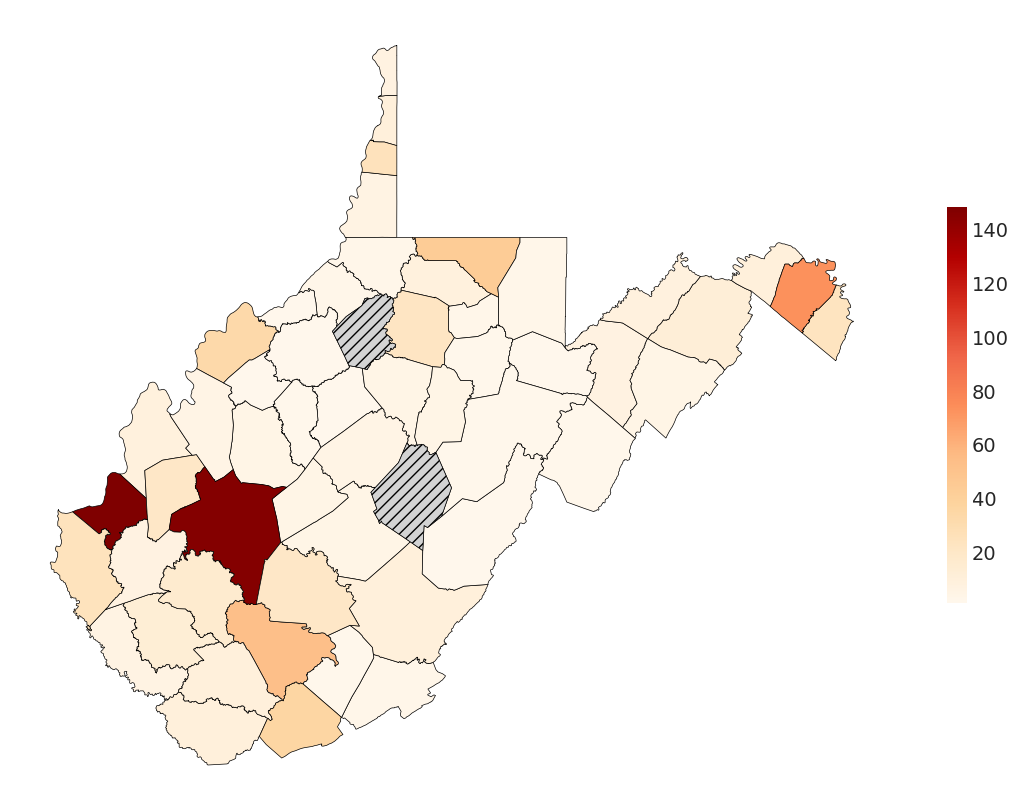

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd

# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf_map.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"observed_deaths.png"), bbox_inches='tight', dpi=300)

Cleaning the data: Removing the rows with missing observed deaths, islands, few states

In [12]:
# filter by column to have columns start with EP_ or SMR and geometry and FIPS and observed_death and expected_death
combined_data = combined_data.filter(regex='EP_|SMR|geometry|FIPS|observed_death|expected_death')

# drop the rows with observed_death = 0
combined_data = combined_data[combined_data['observed_deaths'] > 0]

# make it a geodataframe
gdf = gpd.GeoDataFrame(combined_data, geometry='geometry')

# Compute Queen adjacency
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# if we keep the islands it will cause error in the adjacency computation(empty adjacencies)
# Get the islands fips to a list
islands = w.islands

# drop the islands
combined_data = combined_data[~combined_data["FIPS"].isin(islands)]

# drop rows with FIPS starts with 72, 78, 02, 15, 60
combined_data = combined_data[~combined_data['FIPS'].str.startswith(('72', '78', '02', '15', '60'))]

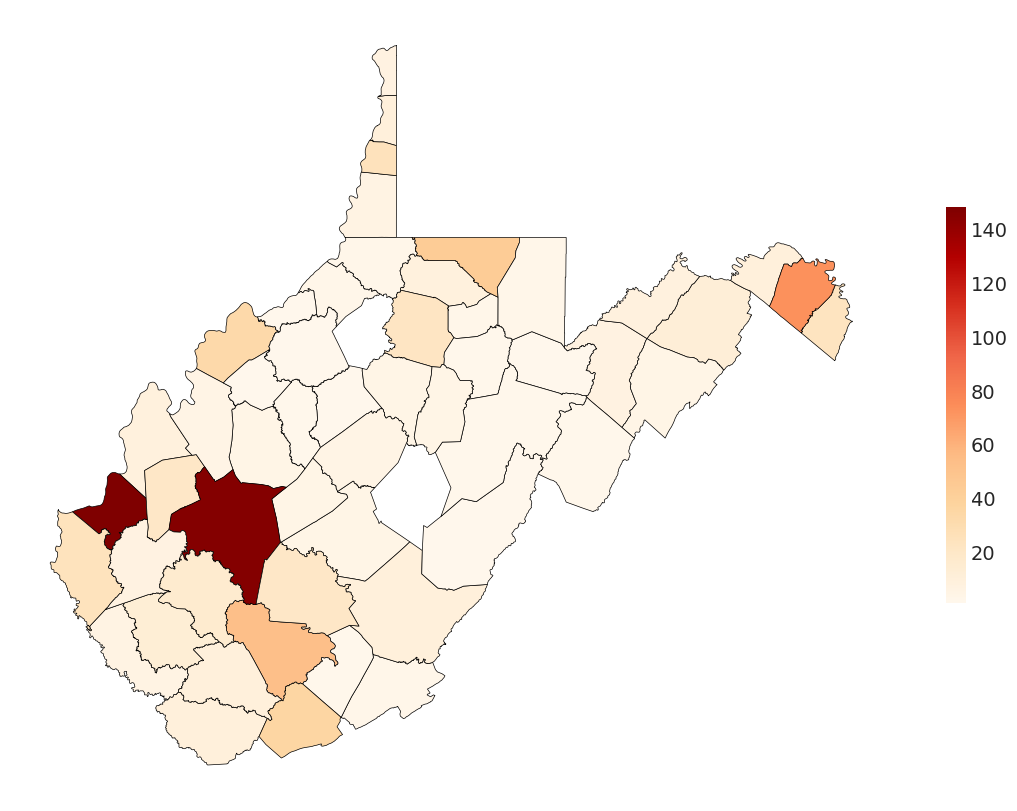

In [13]:
# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.show()

Combine TDA summaries for each state(all variables)

In [14]:
# get the column names with _AL
al_cols = combined_data.filter(regex='_AL').columns

print(f"Columns with _AL: {al_cols}")

# sum the columns with _AL
combined_data['AL'] = combined_data[al_cols].sum(axis=1)

# drop the columns with _AL
# combined_data.drop(columns=al_cols, inplace=True)

# get the column names with _TL

tl_cols = combined_data.filter(regex='_TL').columns

print(f"Columns with _TL: {tl_cols}")

# sum the columns with _TL
combined_data['TL'] = combined_data[tl_cols].sum(axis=1)

# drop the columns with _TL
# combined_data.drop(columns=tl_cols, inplace=True)

# get the column names with _AML
aml_cols = combined_data.filter(regex='_AML').columns

print(f"Columns with _AML: {aml_cols}")

# sum the columns with _AML
combined_data['AML'] = combined_data[aml_cols].sum(axis=1)

# drop the columns with _AML
# combined_data.drop(columns=aml_cols, inplace=True)

# get the column names with _TML
tml_cols = combined_data.filter(regex='_TML').columns

print(f"Columns with _TML: {tml_cols}")

# sum the columns with _TML
combined_data['TML'] = combined_data[tml_cols].sum(axis=1)

# drop the columns with _TML
# combined_data.drop(columns=tml_cols, inplace=True)

Columns with _AL: Index(['EP_POV_AL', 'EP_UNEMP_AL', 'EP_PCI_AL', 'EP_NOHSDP_AL',
       'EP_UNINSUR_AL', 'EP_AGE65_AL', 'EP_AGE17_AL', 'EP_DISABL_AL',
       'EP_SNGPNT_AL', 'EP_LIMENG_AL', 'EP_MINRTY_AL', 'EP_MUNIT_AL',
       'EP_MOBILE_AL', 'EP_CROWD_AL', 'EP_NOVEH_AL', 'EP_GROUPQ_AL'],
      dtype='object')
Columns with _TL: Index(['EP_POV_TL', 'EP_UNEMP_TL', 'EP_PCI_TL', 'EP_NOHSDP_TL',
       'EP_UNINSUR_TL', 'EP_AGE65_TL', 'EP_AGE17_TL', 'EP_DISABL_TL',
       'EP_SNGPNT_TL', 'EP_LIMENG_TL', 'EP_MINRTY_TL', 'EP_MUNIT_TL',
       'EP_MOBILE_TL', 'EP_CROWD_TL', 'EP_NOVEH_TL', 'EP_GROUPQ_TL'],
      dtype='object')
Columns with _AML: Index(['EP_POV_AML', 'EP_UNEMP_AML', 'EP_PCI_AML', 'EP_NOHSDP_AML',
       'EP_UNINSUR_AML', 'EP_AGE65_AML', 'EP_AGE17_AML', 'EP_DISABL_AML',
       'EP_SNGPNT_AML', 'EP_LIMENG_AML', 'EP_MINRTY_AML', 'EP_MUNIT_AML',
       'EP_MOBILE_AML', 'EP_CROWD_AML', 'EP_NOVEH_AML', 'EP_GROUPQ_AML'],
      dtype='object')
Columns with _TML: Index(['EP_POV_TML', '

Get the adjacency matrix

In [15]:
# create the queen adjacency matrix
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# Spatial adjacency matrix (N x N) with binary entries for neighbor relationships.
# make it into a matrix
W = w.full()[0]

In [16]:
# print the shape of W
print(f"Shape of W: {W.shape}")

Shape of W: (53, 53)


Prepare data and adjacency structures

In [17]:
y = combined_data["observed_deaths"].values
E = combined_data["expected_deaths"].values

EP_POV_AV_ORI = combined_data["EP_POV_AV_ORI"].values
EP_UNEMP_AV_ORI = combined_data["EP_UNEMP_AV_ORI"].values
EP_PCI_AV_ORI = combined_data["EP_PCI_AV_ORI"].values
EP_NOHSDP_AV_ORI = combined_data["EP_NOHSDP_AV_ORI"].values
EP_AGE65_AV_ORI = combined_data["EP_AGE65_AV_ORI"].values
EP_AGE17_AV_ORI = combined_data["EP_AGE17_AV_ORI"].values
EP_DISABL_AV_ORI = combined_data["EP_DISABL_AV_ORI"].values
EP_SNGPNT_AV_ORI = combined_data["EP_SNGPNT_AV_ORI"].values
EP_MINRTY_AV_ORI = combined_data["EP_MINRTY_AV_ORI"].values
EP_LIMENG_AV_ORI = combined_data["EP_LIMENG_AV_ORI"].values
EP_MUNIT_AV_ORI = combined_data["EP_MUNIT_AV_ORI"].values
EP_MOBILE_AV_ORI = combined_data["EP_MOBILE_AV_ORI"].values
EP_CROWD_AV_ORI = combined_data["EP_CROWD_AV_ORI"].values
EP_NOVEH_AV_ORI = combined_data["EP_NOVEH_AV_ORI"].values
EP_GROUPQ_AV_ORI = combined_data["EP_GROUPQ_AV_ORI"].values

EP_POV_AL = combined_data["EP_POV_AL"].values


# mean standerdize only EP_POV_AL 
mean_value = combined_data["EP_POV_AL"].mean()
std_value = combined_data["EP_POV_AL"].std()
combined_data["EP_POV_AL"] = (combined_data["EP_POV_AL"] - mean_value) / std_value

AL = combined_data["EP_POV_AL"].values

E[E < 10] = 10
log_E = np.log(E)

area_idx = combined_data["FIPS"].values
coords = {"area_idx": area_idx}

N = len(y)

# # THETA = df_clean["AL"].values
# theta_values = combined_data.set_index("FIPS")["AL"].to_dict()
# theta = np.array([theta_values[fips] for fips in area_idx])

Scaling Factors

In [18]:
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)


scaling_factor = scaling_factor_sp(W)
scaling_factor

0.5991931651817699

In [19]:
import pymc as pm
import arviz as az

####  I. PyMC model for the baseline BYM2 

In [20]:
# PyMC model for BYM
with pm.Model(coords=coords) as bym_model:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)


   # # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # the mixing rate is phi (should be between 0 and 1)
   # this creates a Uniform prior between 0 and 1 and it is mathematically equivalent to Uniform(0,1)
   phi = pm.Beta("phi", alpha=1, beta=1) 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", sigma=0.39)

   # the bym component - it mixes a spatial and a random effect
   mixture = pm.Deterministic(
   "mixture", pt.sqrt(1 - phi) * v + pt.sqrt(phi / scaling_factor) * u, dims="area_idx"
   )

   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                  sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")


Sampling the data

In [21]:
with bym_model:

    # # Sample from the model:
    trace_bym = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, phi, sigma]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 106 seconds.


R hat statistics

In [22]:
# Calculate r_hat for sigma and phi
rhat_data = az.rhat(trace_bym, var_names=["sigma","phi","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data["sigma"].values}')  
print(f'R-hat for phi: {rhat_data["phi"].values}')

R-hat for sigma: 1.0002716001697765
R-hat for phi: 1.0012744475360797


In [23]:
# Print rhat for all coefficients
for var in ["beta_pov"]:
    print(f'R-hat for {var}: {rhat_data[var].values}')

R-hat for beta_pov: 1.0006246954143814


Rank plots

array([<Axes: title={'center': 'phi'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

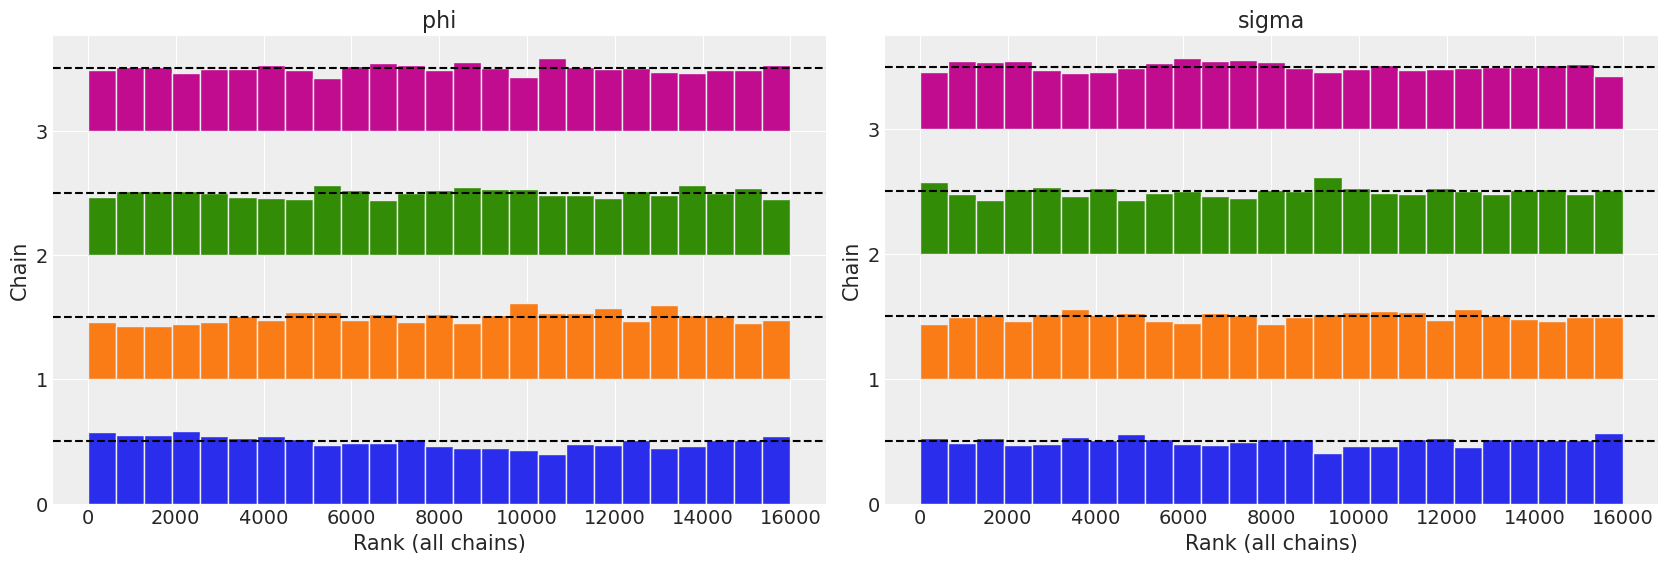

In [24]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_bym, var_names=["phi", "sigma"])

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/2538432722.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


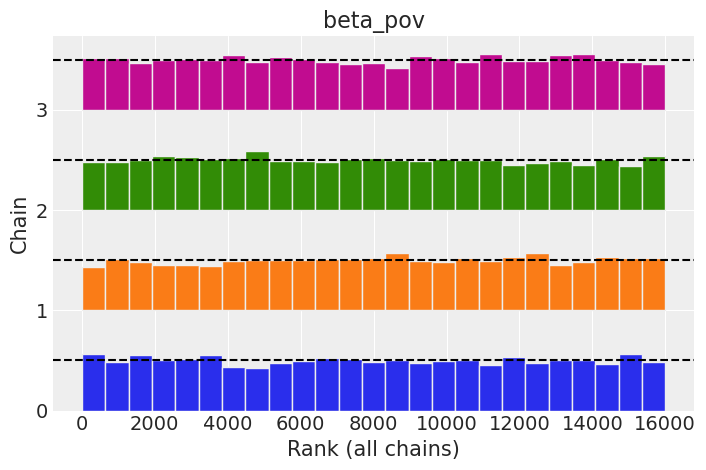

In [25]:
# plot rank plots for all coefficients
# Define coefficients to plot
coefficients = [
    "beta_pov"
]

# Plot all of them at once in a single grid
az.plot_rank(trace_bym, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Editing for the figures

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/249222461.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


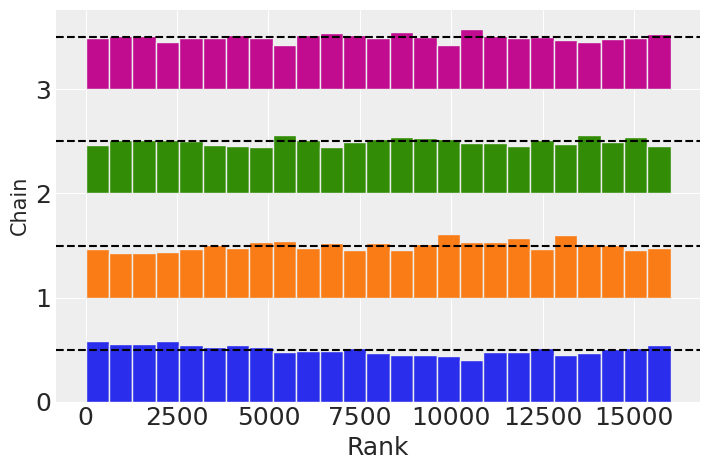

In [181]:
# Generate the plot
axes = az.plot_rank(trace_bym, var_names=["phi"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"phi_bym{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/858212070.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


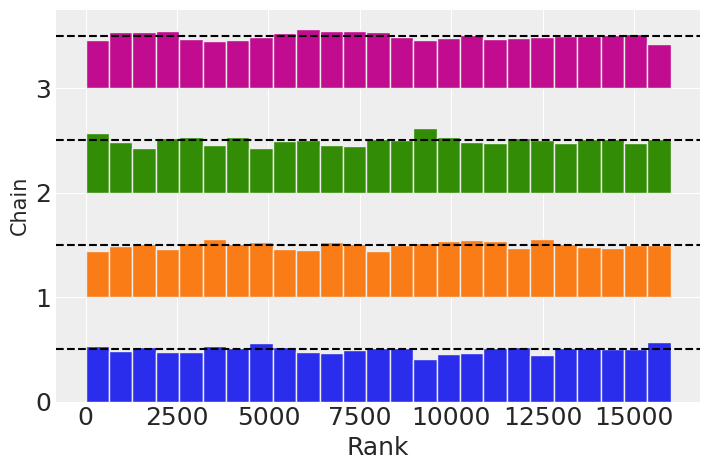

In [182]:
# Generate the plot
axes = az.plot_rank(trace_bym, var_names=["sigma"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"sigma_bym{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Checking Autocorrlation

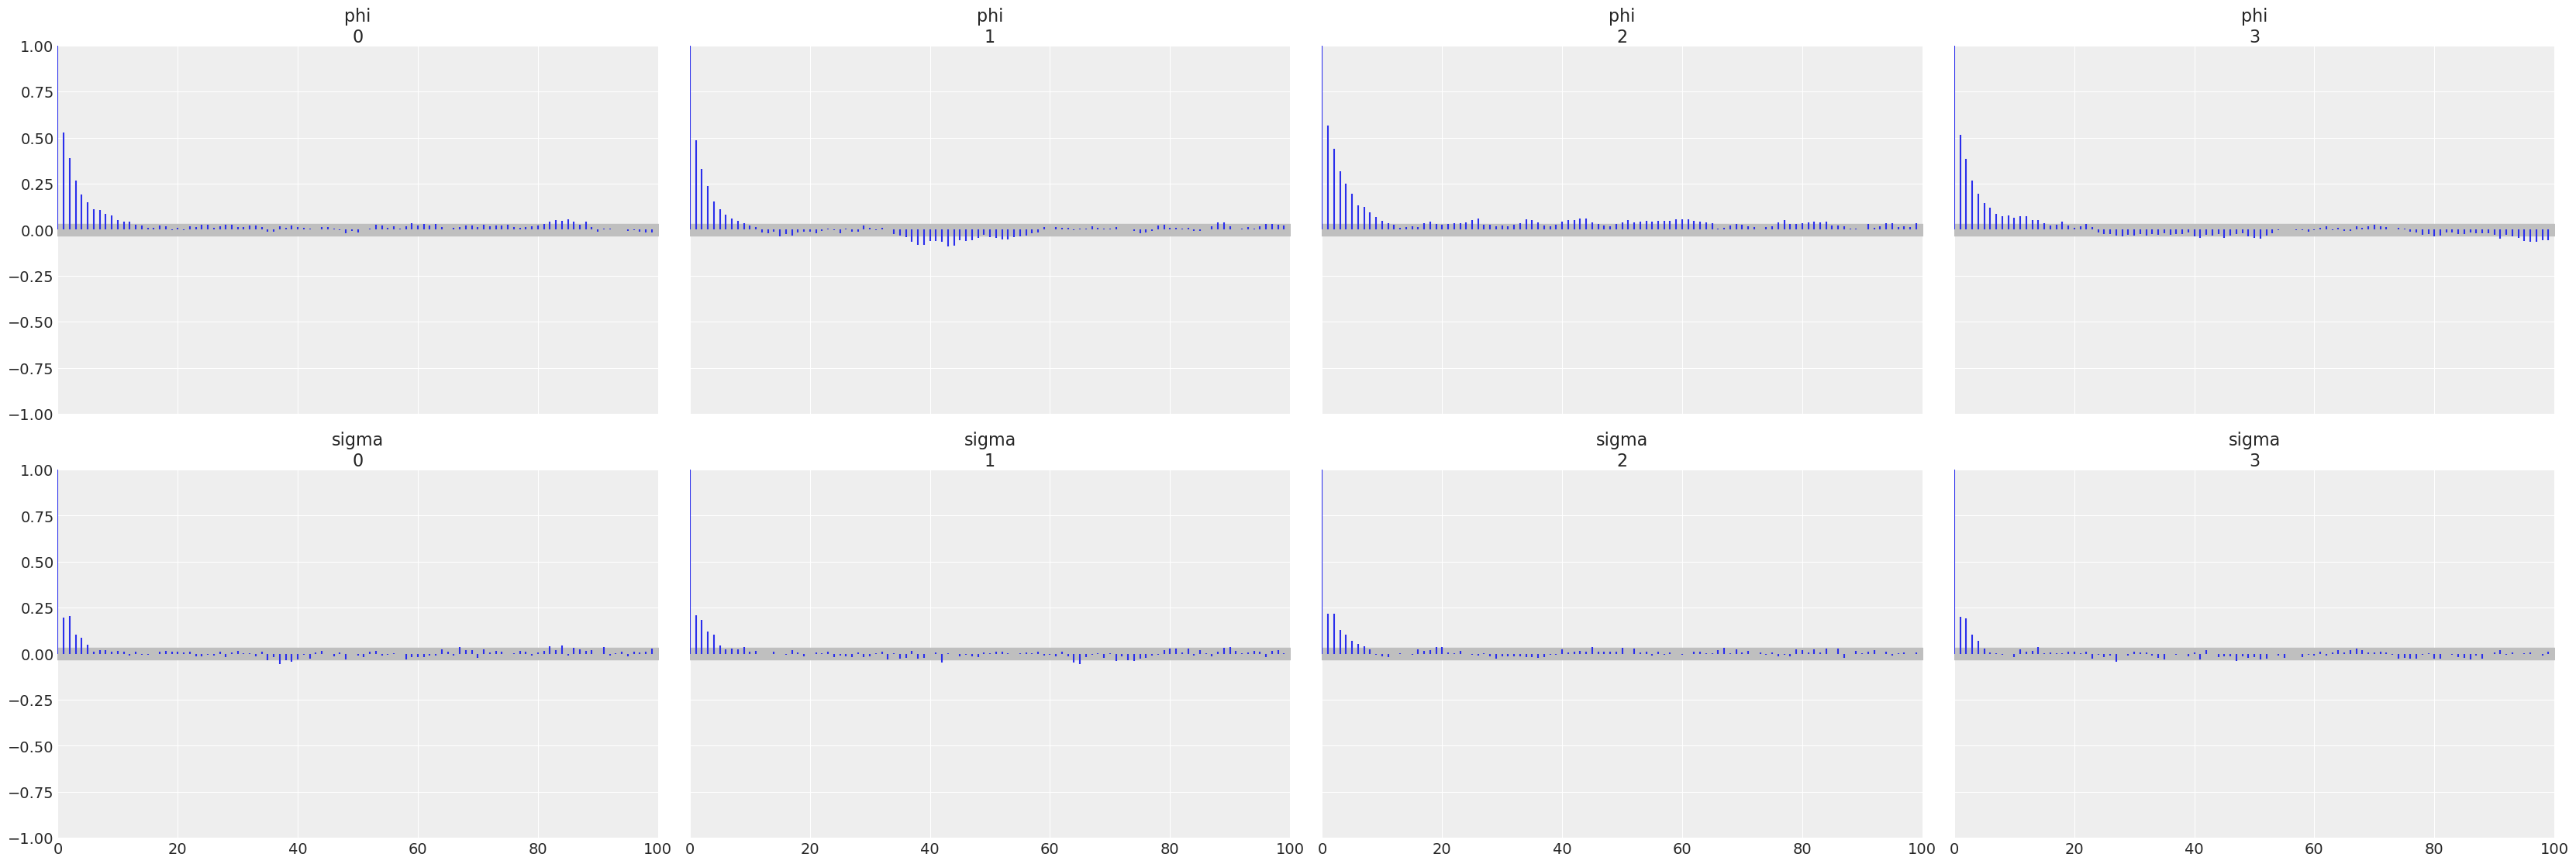

In [26]:
az.plot_autocorr(trace_bym, var_names=["phi","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [27]:
summary = az.summary(trace_bym, var_names=["phi", "sigma"])
print(summary[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

# save summary to csv
result_dir = os.path.join(current_path, "results", state_abb_lower)
summary.to_csv(os.path.join(result_dir, "bym_summary.csv"))

        mean     sd  ess_bulk  ess_tail  mcse_mean
phi    0.502  0.207    2893.0    5016.0      0.004
sigma  0.544  0.080    6388.0   10163.0      0.001


In [28]:
# summry all the coefficients in a single dataframe
coefficients = [
    "beta_pov"
]
coeff_summary = az.summary(trace_bym, var_names=coefficients)
print(coeff_summary)

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov  0.277  0.809  -1.295    1.742      0.008    0.006   11004.0   

          ess_tail  r_hat  
beta_pov   11745.0    1.0  


In [29]:
comparison_coeff_df = pd.DataFrame(index=coeff_summary.index)

# 2. Add the current model's means as a column
comparison_coeff_df['Model_BYM'] = coeff_summary['mean']

# Check the result
print(comparison_coeff_df.head())

          Model_BYM
beta_pov      0.277


Model metrics WAIC and LOO

In [30]:
loo_result_base = az.loo(trace_bym)
print(loo_result_base)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -146.14     6.55
p_loo       26.98        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       31   58.5%
   (0.70, 1]   (bad)        18   34.0%
   (1, Inf)   (very bad)    4    7.5%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [31]:
waic_result_base = az.waic(trace_bym)
print(waic_result_base)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -137.92     5.51
p_waic       18.76        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


####  II. Model with new topological component (BYM-T)

In [32]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_2:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

Sampling the data

In [33]:
with model_2:

    # # Sample from the model:
    trace_model_2 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 121 seconds.


R hat statistics

In [34]:
# Calculate r_hat for sigma and phi
rhat_data_model_2 = az.rhat(trace_model_2, var_names=["sigma","alpha","beta_pov"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_2["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_2["alpha"].values}')

R-hat for sigma: 1.000597666343161
R-hat for alpha: [1.00108392 1.00063605 1.00052834]


In [35]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_2[var].values}')

R-hat for beta_pov: 1.0003942724769106


Rank plots

array([<Axes: title={'center': 'alpha\n0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n1'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n2'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

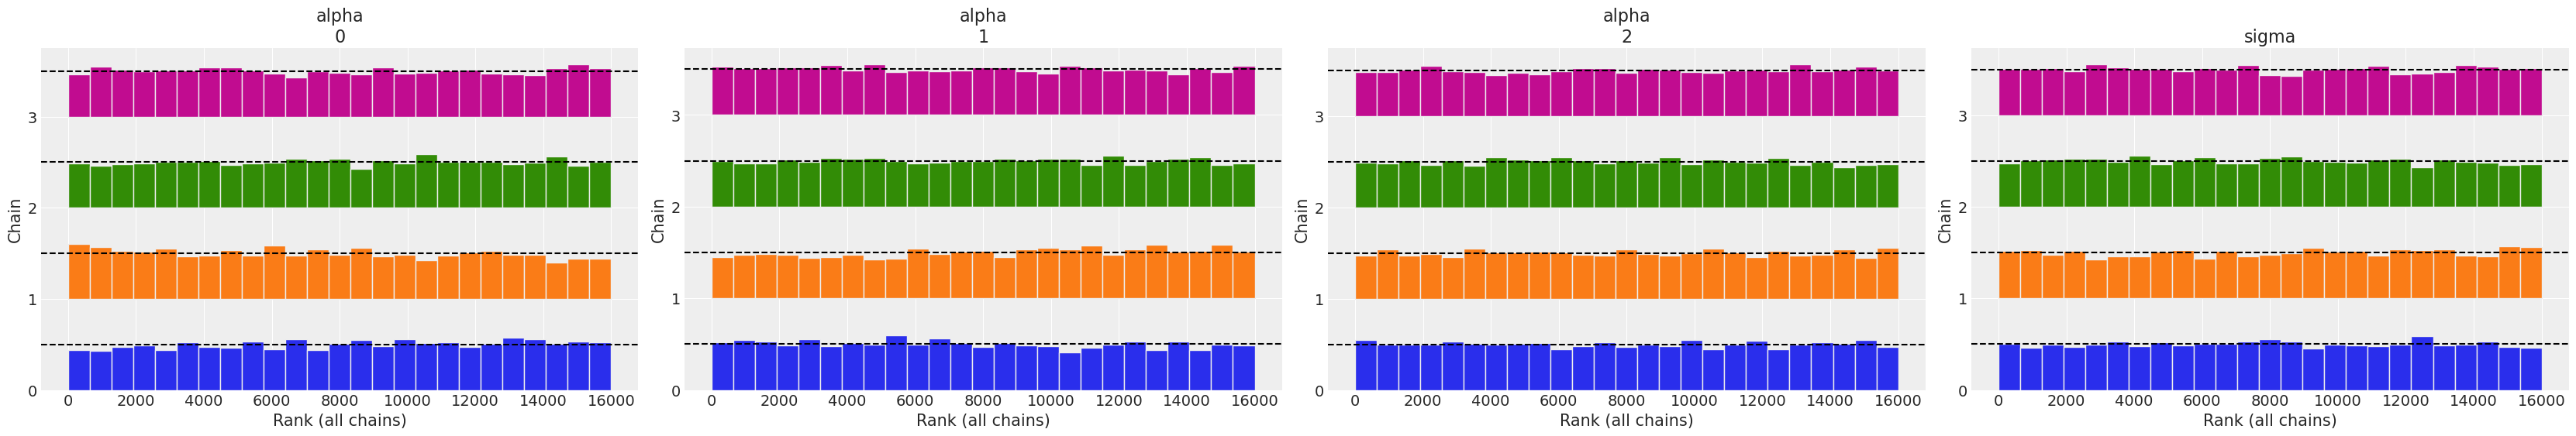

In [36]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_model_2, var_names=["alpha", "sigma"])

Editing for the figures

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/4183779130.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


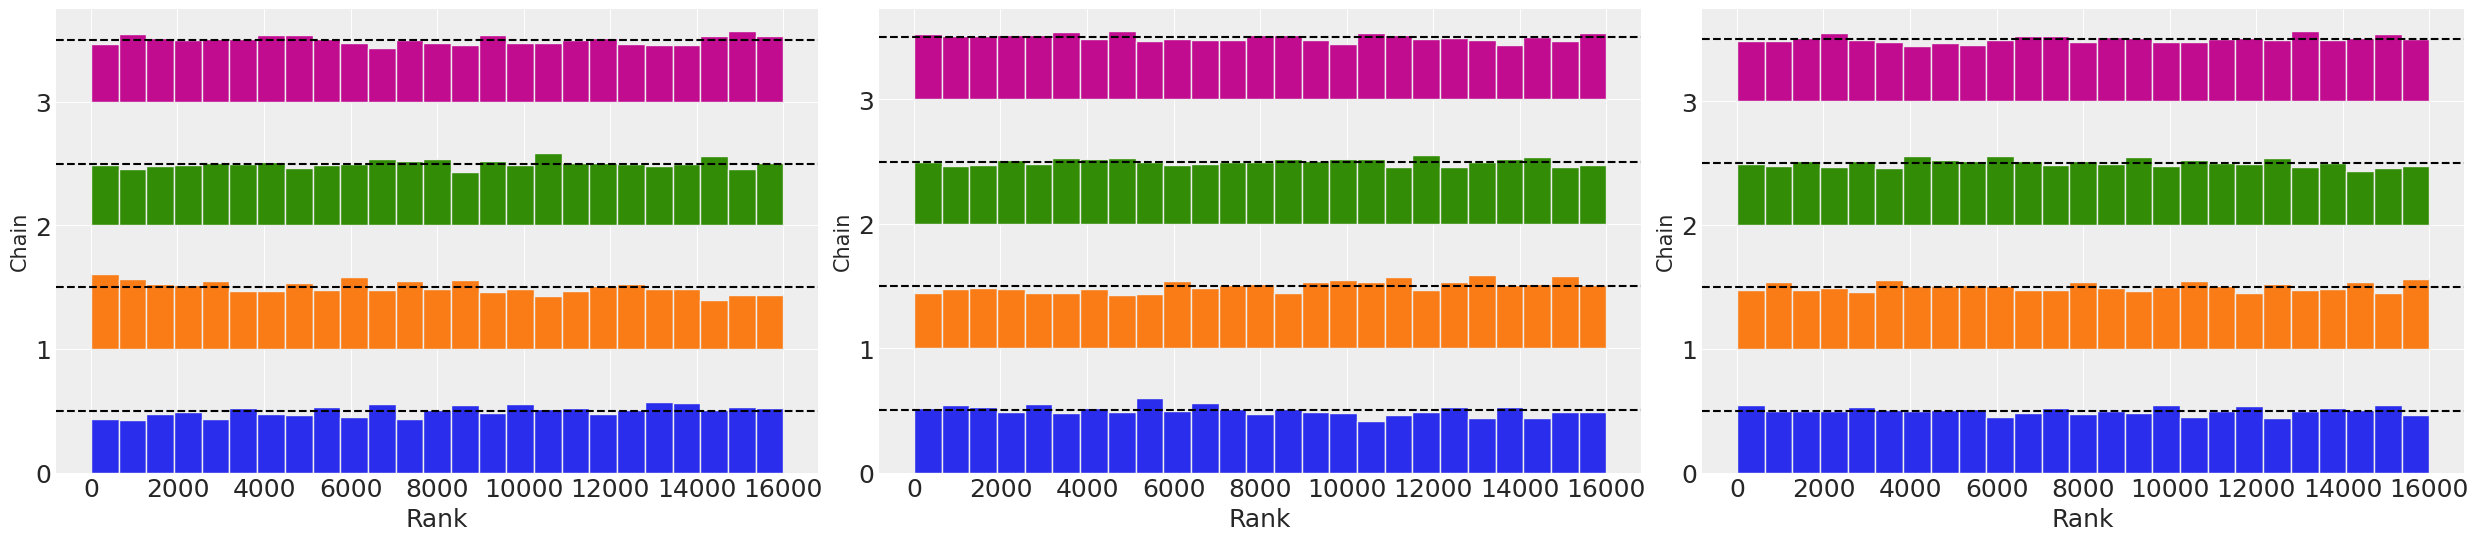

In [177]:
import arviz as az
import matplotlib.pyplot as plt

# Generate the plot
axes = az.plot_rank(trace_model_2, var_names=["alpha"])

# Iterate over each subplot to customize
for ax in axes.flatten():
    # 1. Remove the variable name (as requested previously)
    ax.set_title("")
    
    # 2. Increase the size of the numbers (tick labels) on both axes
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # 3. (Optional) Add and size X/Y labels if you want them named
    ax.set_xlabel("Rank", fontsize=18)
    # ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"alphas_bym_t_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/3544974445.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Adjusts spacing so the larger labels don't overlap


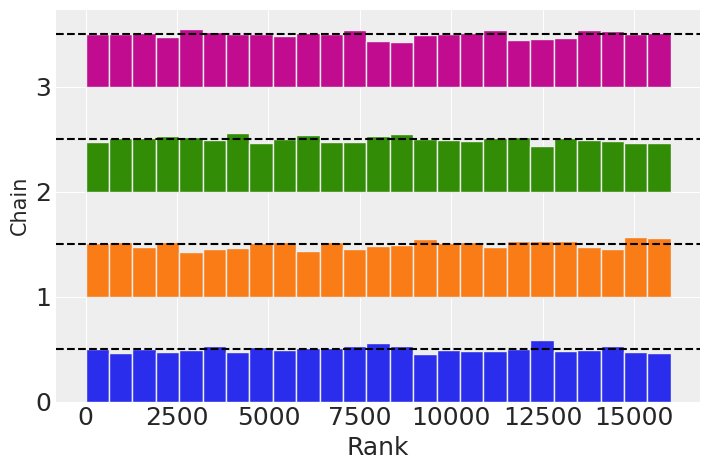

In [178]:
# Generate the plot
axes = az.plot_rank(trace_model_2, var_names=["sigma"])


# 1. Remove the variable name (as requested previously)
axes.set_title("")

# 2. Increase the size of the numbers (tick labels) on both axes
axes.tick_params(axis='both', which='major', labelsize=18)

# 3. (Optional) Add and size X/Y labels if you want them named
axes.set_xlabel("Rank", fontsize=18)
# ax.set_ylabel("Frequency", fontsize=16) # Rank plots usually don't label Y by default

plt.tight_layout() # Adjusts spacing so the larger labels don't overlap
# plt.show()
plt.savefig(os.path.join( save_path,"mcmc", f"sigma_bym_t_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/581698039.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


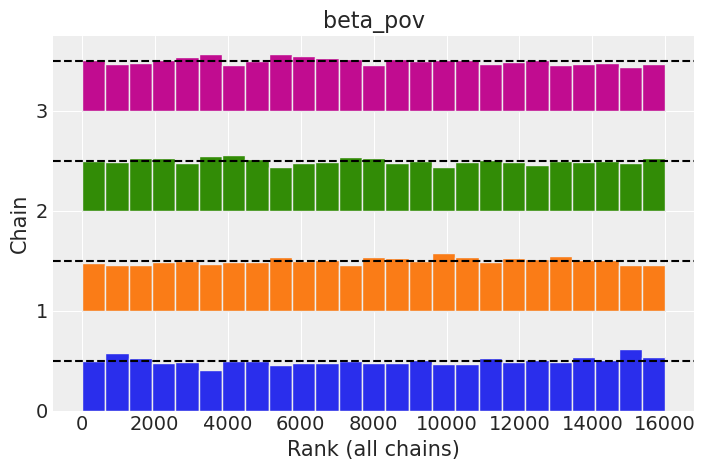

In [37]:
# plot rank plots for all coefficients

az.plot_rank(trace_model_2, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Checking Autocorrlation

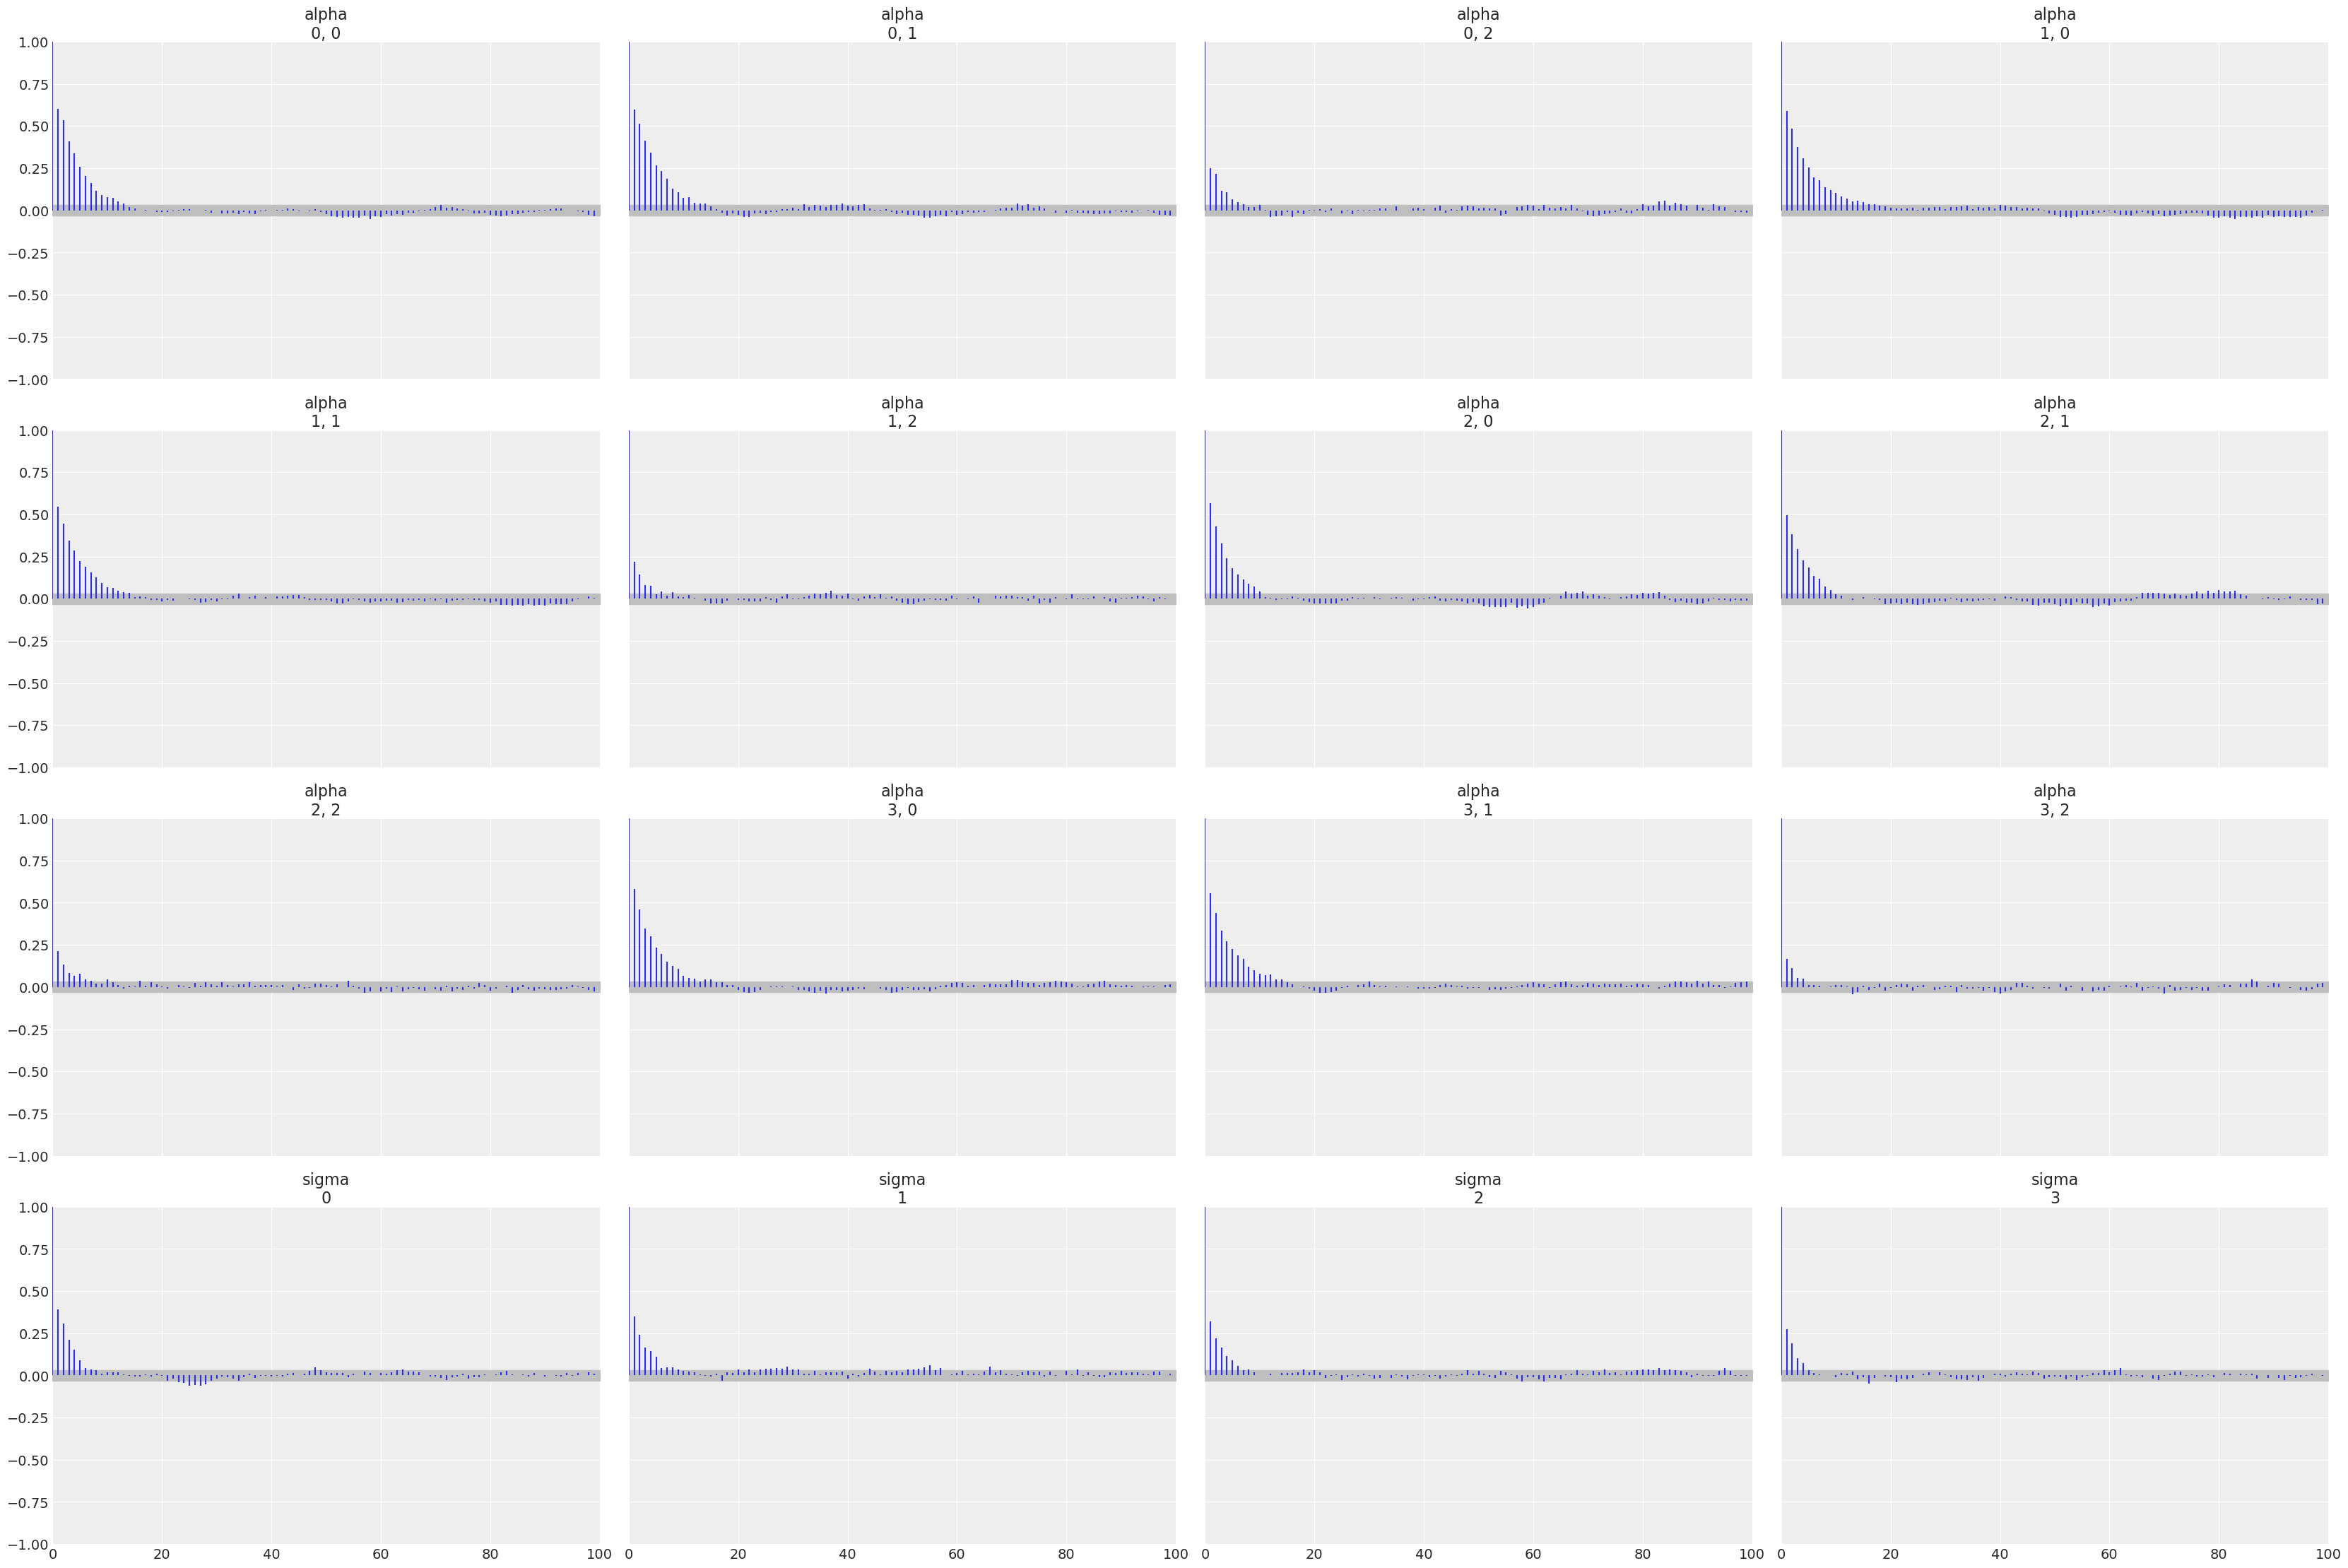

In [38]:
az.plot_autocorr(trace_model_2, var_names=["alpha","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [39]:
summary_model_2 = az.summary(trace_model_2, var_names=["alpha", "sigma"])
print(summary_model_2[["mean", "sd", "ess_bulk", "mcse_mean"]])

           mean     sd  ess_bulk  mcse_mean
alpha[0]  0.201  0.144    2286.0      0.003
alpha[1]  0.516  0.153    2572.0      0.003
alpha[2]  0.284  0.101    6768.0      0.001
sigma     0.522  0.071    4987.0      0.001


In [40]:
# summry all the coefficients in a single dataframe
coeff_summary_model_2 = az.summary(trace_model_2, var_names=coefficients)
print(coeff_summary_model_2)

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov -0.35  0.777  -1.838    1.074       0.01    0.006    6530.0   

          ess_tail  r_hat  
beta_pov    8352.0    1.0  


In [41]:
# add the means to the comparison dataframe
comparison_coeff_df['model_2'] = coeff_summary_model_2['mean']

# Check the result
print(comparison_coeff_df)

          Model_BYM  model_2
beta_pov      0.277    -0.35


In [42]:
az.summary(trace_model_2, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.522,0.071,0.395,0.657,0.001,0.001,4987.0,9293.0,1.0
alpha[0],0.201,0.144,0.000,0.457,0.003,0.002,2286.0,4003.0,1.0
alpha[1],0.516,0.153,0.241,0.804,0.003,0.001,2572.0,5413.0,1.0
alpha[2],0.284,0.101,0.094,0.471,0.001,0.001,6768.0,10667.0,1.0


Model metrics WAIC and LOO

In [43]:
loo_result_model_2 = az.loo(trace_model_2)
print(loo_result_model_2)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -143.23     6.90
p_loo       23.26        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       40   75.5%
   (0.70, 1]   (bad)        11   20.8%
   (1, Inf)   (very bad)    2    3.8%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [44]:
waic_result_model_2 = az.waic(trace_model_2)
print(waic_result_model_2)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -137.26     6.00
p_waic       17.29        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


### Compare model results

LOO

In [123]:
df_comp_loo = az.compare({"bym2": loo_result_base,"bym-t": loo_result_model_2}, ic="loo")
print(df_comp_loo)

       rank    elpd_loo      p_loo  elpd_diff    weight        se       dse  \
bym-t     0 -143.229264  23.259636   0.000000  0.939878  6.904253  0.000000   
bym2      1 -146.139568  26.979140   2.910303  0.060122  6.553160  2.437503   

       warning scale  
bym-t     True   log  
bym2      True   log  


WAIC

In [124]:
df_comp_waic = az.compare({"bym2": waic_result_base, "bym-t": waic_result_model_2}, ic="waic")
print(df_comp_waic)

       rank   elpd_waic     p_waic  elpd_diff    weight        se       dse  \
bym-t     0 -137.258662  17.289033   0.000000  0.721225  5.999593  0.000000   
bym2      1 -137.917266  18.756838   0.658604  0.278775  5.511154  1.842885   

       warning scale  
bym-t     True   log  
bym2      True   log  


Get sample values to plot the map

In [47]:
rr_bym = trace_bym.posterior["rr"].mean(dim=["chain", "draw"]).values
rr_model_2 = trace_model_2.posterior["rr"].mean(dim=["chain", "draw"]).values

In [48]:
combined_data["rr_bym"] = rr_bym
combined_data["rr_model_2"] = rr_model_2


In [49]:
# lets get the differences to base rr_bym
combined_data["rr_diff_bym_model_2"] = combined_data["rr_model_2"] - combined_data["rr_bym"]

In [50]:
# let's add missing islands and overdose missing areas back with NaN values
geo_data_for_the_area = geo_data[geo_data['ST_ABBR']==state_abb]

# merge combined_data with geo_data_for_the_area to get all FIPS codes (with NULL values for missing areas)
combined_data_full = geo_data_for_the_area.merge(combined_data, on="FIPS", how="left")

# make combined data into a geodataframe
combined_data_full = gpd.GeoDataFrame(combined_data_full, geometry='geometry_x')

Relative risk of the BYM2 model

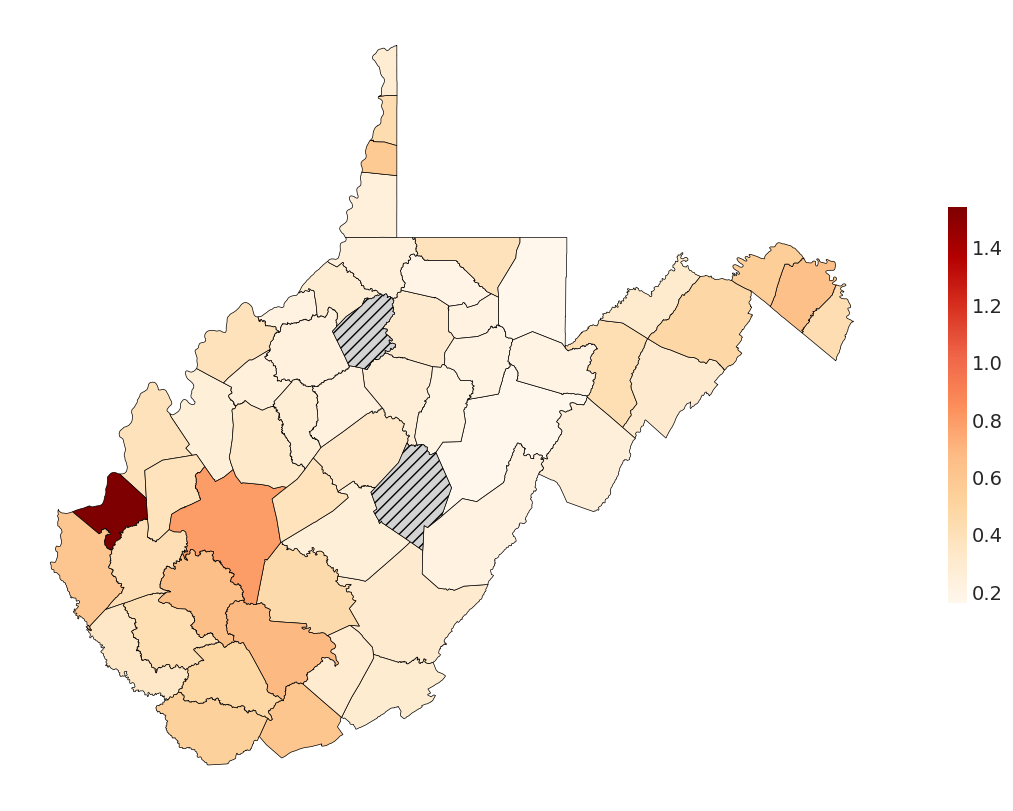

In [139]:
# plot a map with the relative risk for the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_bym", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( save_path, f"bym_relative_risk_map_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Relative risk of the BYM-T model

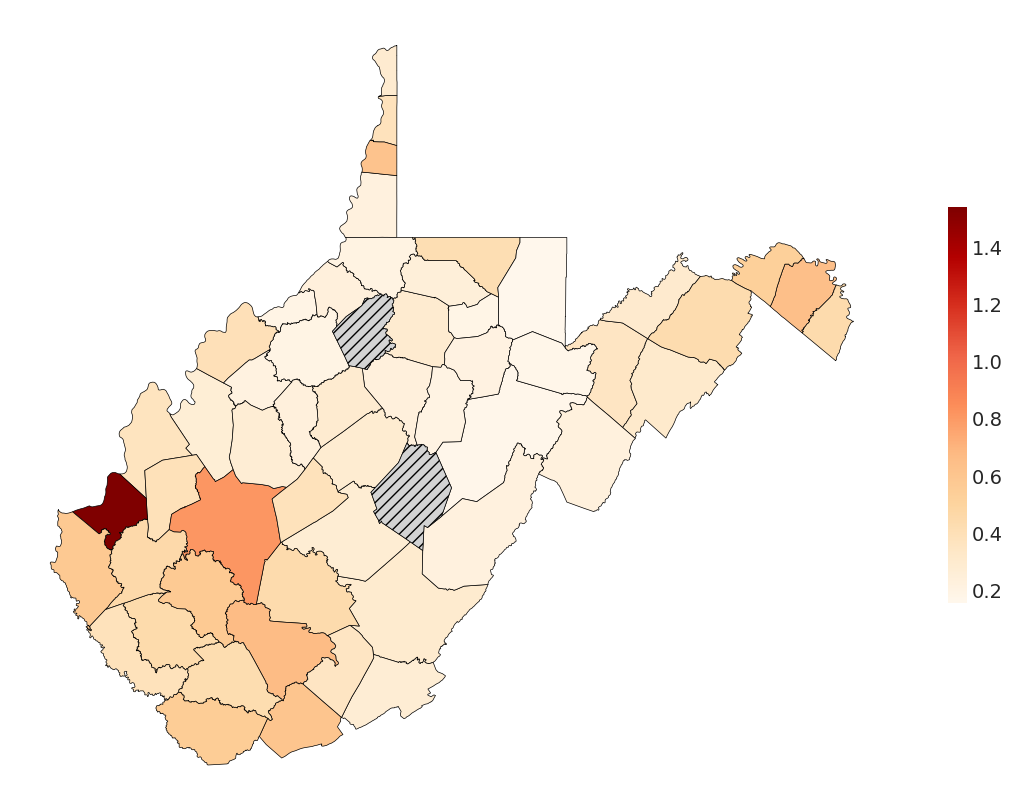

In [140]:
# plot a map with the relative risk for the model 2
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_model_2", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( save_path, f"bymt_relative_risk_map_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Relative risk differences: BYM-T model - BYM2 model

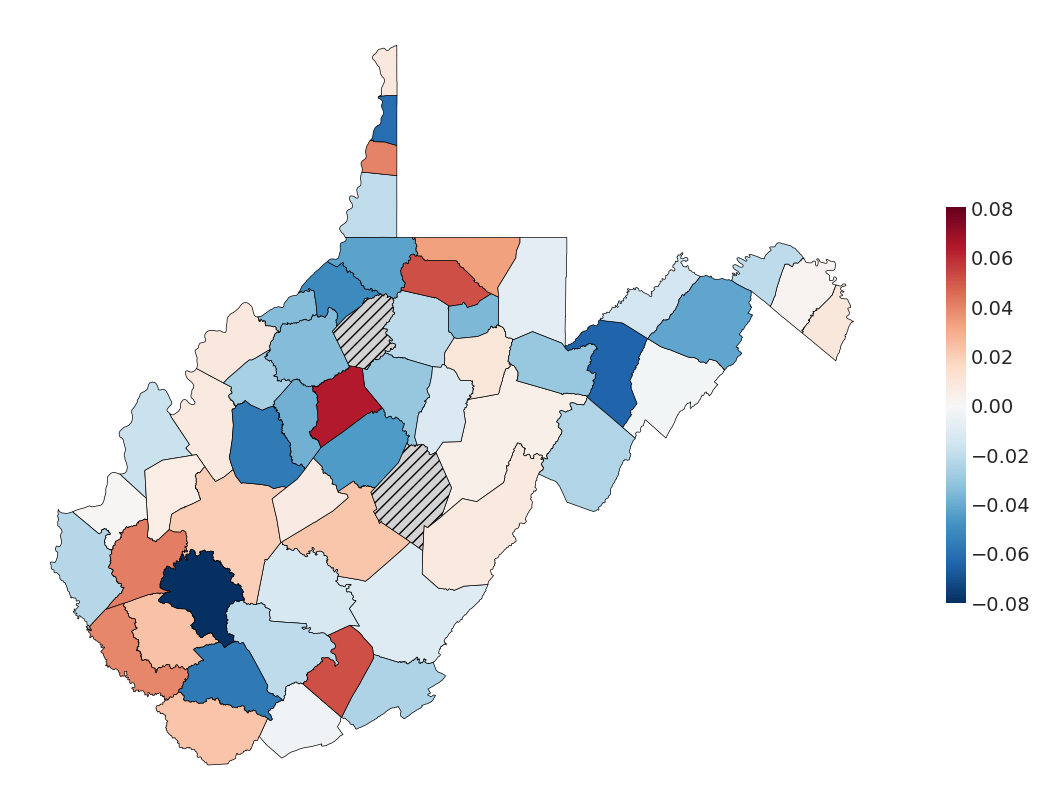

In [141]:
# plot a map with the relative risk for the BYM-T and the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

# Find min/max of your column
vmin = combined_data_full["rr_diff_bym_model_2"].min()
vmax = combined_data_full["rr_diff_bym_model_2"].max()

# Create symmetric range around 0
abs_max = max(abs(vmin), abs(vmax))

combined_data_full.plot(
    column="rr_diff_bym_model_2", 
    ax=ax, 
    legend=True, 
    cmap="RdBu_r", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    vmin=-abs_max,  # ensure 0 is at center
    vmax=abs_max,
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( save_path, f"relative_risk_difference_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

Topological summaries

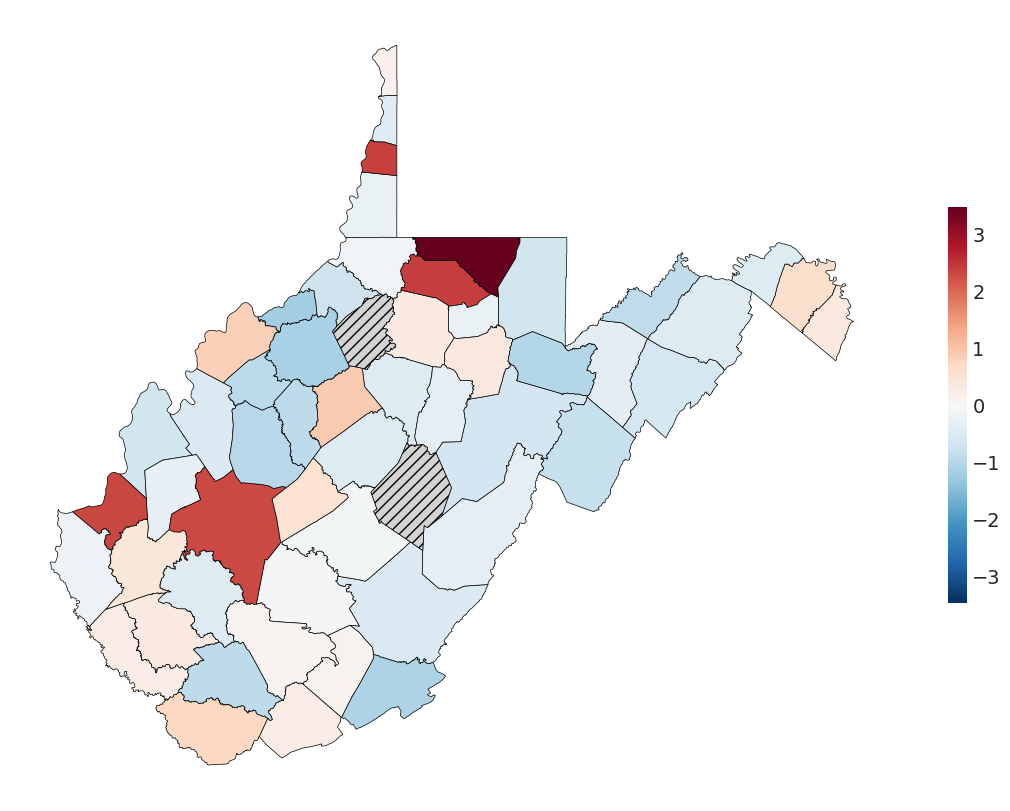

In [142]:
# plot a map with AL values for each area
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white


# Find min/max of your column
almin = combined_data_full["EP_POV_AL"].min()
almax = combined_data_full["EP_POV_AL"].max()

# Create symmetric range around 0
abs_max_al = max(abs(almin), abs(almax))

combined_data_full.plot(
    column="EP_POV_AL", 
    ax=ax, 
    legend=True, 
    cmap="RdBu_r", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    vmin=-abs_max_al,  # ensure 0 is at center
    vmax=abs_max_al,
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

plt.savefig(os.path.join( save_path, f"AL_POV_SCALED_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)


Coefficients comparisons

In [57]:
comparison_coeff_df = comparison_coeff_df.rename(columns={
    "Model_BYM": "BYM",
    "model_2": "BYM-T"
})


In [58]:
comparison_coeff_df = comparison_coeff_df.rename(index={
    "beta_pov": "Poverty rate",
})


In [59]:
comparison_coeff_df

,BYM,BYM-T
Poverty rate,0.277,-0.35


/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_93600/3660989948.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


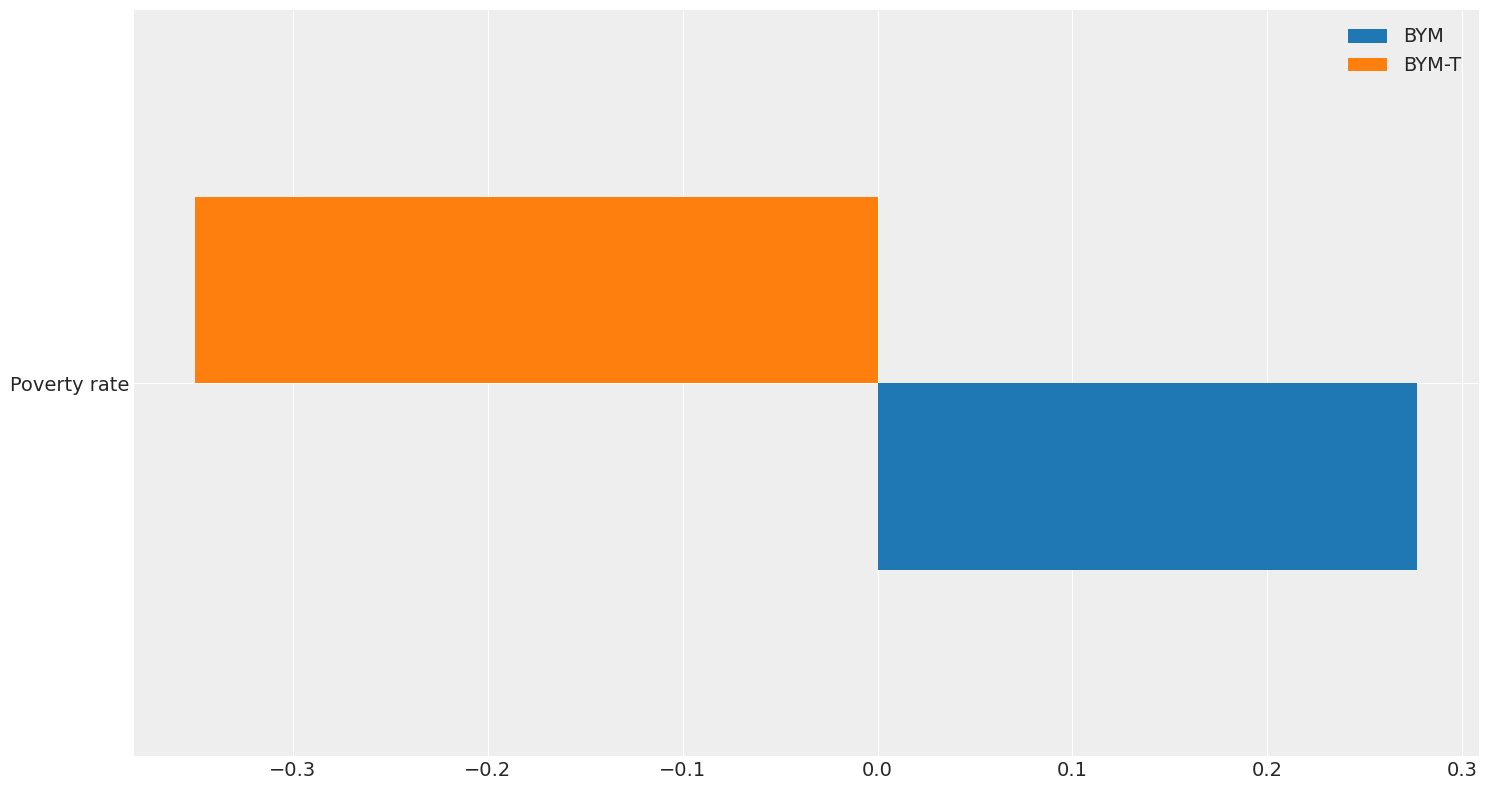

In [60]:
comparison_coeff_df.plot(
    kind='barh',
    figsize=(15, 8),
    color=["#1f77b4", "#ff7f0e"]  # blue, orange
)
# plt.xlabel('Coefficient Mean Estimates')
# plt.title('Comparison of Coefficient Estimates Across Models')
plt.tight_layout()
plt.show()

Comparison of sigma, phi, alpha

In [61]:
# bym model sigma and phi model diagnostics
print(summary[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

        mean     sd  ess_bulk  ess_tail  mcse_mean
phi    0.502  0.207    2893.0    5016.0      0.004
sigma  0.544  0.080    6388.0   10163.0      0.001


In [62]:
# model 2 sigma and alpha model diagnostics
print(summary_model_2[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

           mean     sd  ess_bulk  ess_tail  mcse_mean
alpha[0]  0.201  0.144    2286.0    4003.0      0.003
alpha[1]  0.516  0.153    2572.0    5413.0      0.003
alpha[2]  0.284  0.101    6768.0   10667.0      0.001
sigma     0.522  0.071    4987.0    9293.0      0.001


In [127]:
# Generate the correlation between rr_diff_bym_model_2 and AL values
correlation = combined_data_full[["rr_diff_bym_model_2", "EP_POV_AL"]].corr().iloc[0, 1]
print(f"Correlation between rr_diff_bym_model_2 and AL: {correlation})")

Correlation between rr_diff_bym_model_2 and AL: 0.6340873657277621)


#### Analyzing relative risk increased areas and decreased areas

In [115]:
# generate a dataframe with FIPS, rr_bym, rr_model_2, rr_diff_bym_model_2 and the percentage change between rr_bym and rr_model_2
results_df = combined_data_full[["FIPS", "rr_bym", "rr_model_2", "rr_diff_bym_model_2", "EP_POV_AL"]].copy()
results_df["Relative Difference Percentage"] = (results_df["rr_model_2"] - results_df["rr_bym"]) / results_df["rr_bym"] * 100


In [116]:
# sort by percentage change descending
results_df = results_df.sort_values(by="Relative Difference Percentage", ascending=False)

In [117]:
results_df

,FIPS,rr_bym,rr_model_2,rr_diff_bym_model_2,EP_POV_AL,Relative Difference Percentage
44,54021,0.227278,0.290631,0.063354,0.902223,27.875070
10,54049,0.193490,0.244969,0.051479,2.409034,26.605721
41,54089,0.300008,0.351725,0.051717,0.132851,17.238514
53,54059,0.341280,0.380218,0.038937,0.249078,11.409177
52,54043,0.410151,0.451376,0.041225,0.422913,10.051073
15,54067,0.251999,0.274382,0.022384,-0.098340,8.882459
32,54061,0.383575,0.416400,0.032825,3.471220,8.557743
34,54069,0.573868,0.613511,0.039644,2.384960,6.908157
45,54045,0.417823,0.441158,0.023335,0.311683,5.584974
25,54001,0.199193,0.208635,0.009442,0.367200,4.739992


Checking relative risk difference and EP_POV_AL (topological summaries) positive/negative relation

In [134]:
# 1. Filter for Positive EP_POV_AL AND Positive Relative Difference
pos_pos_condition = (results_df["EP_POV_AL"] > 0) & (results_df["Relative Difference Percentage"] > 0)
count_pos_pos = pos_pos_condition.sum()

# 2. Filter for Negative EP_POV_AL AND Negative Relative Difference
neg_neg_condition = (results_df["EP_POV_AL"] < 0) & (results_df["Relative Difference Percentage"] < 0)
count_neg_neg = neg_neg_condition.sum()

# 3. Print the results
print("--- Correlation Counts ---")
print(f"Positive EP_POV_AL with Positive Difference: {count_pos_pos}")
print(f"Negative EP_POV_AL with Negative Difference: {count_neg_neg}")

# Optional: View the specific rows that match these conditions
# print("\n--- Positive/Positive Rows ---")
# print(results_df[pos_pos_condition][["FIPS", "EP_POV_AL", "Relative Difference Percentage"]])

--- Correlation Counts ---
Positive EP_POV_AL with Positive Difference: 17
Negative EP_POV_AL with Negative Difference: 28


In [135]:
# 1. Mismatch A: Positive EP_POV_AL but Negative Difference
pos_neg_condition = (results_df["EP_POV_AL"] > 0) & (results_df["Relative Difference Percentage"] < 0)
count_pos_neg = pos_neg_condition.sum()

# 2. Mismatch B: Negative EP_POV_AL but Positive Difference
neg_pos_condition = (results_df["EP_POV_AL"] < 0) & (results_df["Relative Difference Percentage"] > 0)
count_neg_pos = neg_pos_condition.sum()

print("--- Mismatch Counts ---")
print(f"Positive EP_POV_AL / Negative Diff: {count_pos_neg}")
print(f"Negative EP_POV_AL / Positive Diff: {count_neg_pos}")

# Optional: View the mismatch rows
# mismatch_df = results_df[pos_neg_condition | neg_pos_condition]
# print(mismatch_df)

--- Mismatch Counts ---
Positive EP_POV_AL / Negative Diff: 3
Negative EP_POV_AL / Positive Diff: 5


In [136]:
# 1. Drop NaNs to ensure accurate counts
df_clean = results_df.dropna(subset=["EP_POV_AL", "Relative Difference Percentage"]).copy()

# 2. Assign categories based on the sign (> 0 or < 0)
# We use np.select to handle Pos, Neg, and Zero cleanly
conditions_pov = [df_clean["EP_POV_AL"] > 0, df_clean["EP_POV_AL"] < 0]
choices_pov = ["Positive", "Negative"]
df_clean["POV_Sign"] = np.select(conditions_pov, choices_pov, default="Zero")

conditions_diff = [df_clean["Relative Difference Percentage"] > 0, df_clean["Relative Difference Percentage"] < 0]
choices_diff = ["Positive", "Negative"]
df_clean["Diff_Sign"] = np.select(conditions_diff, choices_diff, default="Zero")

# 3. Create a Crosstab (Contingency Table)
# This counts the overlaps between POV signs and Difference signs
summary = pd.crosstab(df_clean["POV_Sign"], df_clean["Diff_Sign"])

# 4. Calculate Conditional Percentages (Row Percentages)
# "Out of all Positive POV, how many were Positive Diff?"
# axis=0 divides by column totals, axis=1 divides by row totals. We want row totals.
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

# 5. formatting for display
# Combine Count and Percentage into one string for easier reading
summary_combined = summary.astype(str) + " (" + summary_pct.round(1).astype(str) + "%)"

print("--- Summary of Signs (EP_POV_AL vs Relative Diff) ---")
print("Format: Count (Percentage of that POV Group)\n")
print(summary_combined)

# If you prefer a flat table with explicit labels:
print("\n--- Detailed Flat Summary ---")
flat_summary = []
for pov_type in ["Positive", "Negative"]:
    total_in_group = summary.loc[pov_type].sum()
    for diff_type in ["Positive", "Negative"]:
        count = summary.loc[pov_type, diff_type]
        pct = (count / total_in_group) * 100 if total_in_group > 0 else 0
        
        status = "MATCH" if pov_type == diff_type else "MISMATCH"
        
        flat_summary.append({
            "EP_POV_AL Sign": pov_type,
            "Diff Percentage Sign": diff_type,
            "Type": status,
            "Count": count,
            "Percentage (of POV group)": f"{pct:.1f}%"
        })

print(pd.DataFrame(flat_summary))

--- Summary of Signs (EP_POV_AL vs Relative Diff) ---
Format: Count (Percentage of that POV Group)

Diff_Sign    Negative    Positive
POV_Sign                         
Negative   28 (84.8%)   5 (15.2%)
Positive    3 (15.0%)  17 (85.0%)

--- Detailed Flat Summary ---
  EP_POV_AL Sign Diff Percentage Sign      Type  Count  \
0       Positive             Positive     MATCH     17   
1       Positive             Negative  MISMATCH      3   
2       Negative             Positive  MISMATCH      5   
3       Negative             Negative     MATCH     28   

  Percentage (of POV group)  
0                     85.0%  
1                     15.0%  
2                     15.2%  
3                     84.8%  


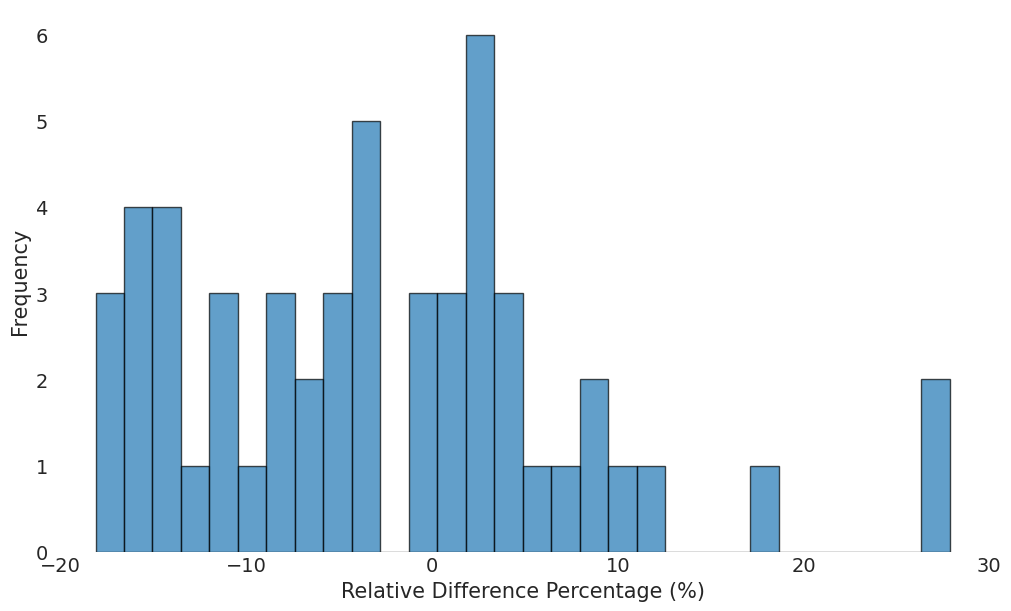

In [143]:
import matplotlib.pyplot as plt

# 1. Figure setup
plt.figure(figsize=(10, 6), facecolor='white')

# 2. Plot the histogram
plt.hist(results_df["Relative Difference Percentage"].dropna(), bins=30, color="#1f77b4", edgecolor="black", alpha=0.7)

# 3. Force background white (removes gray background from styles like seaborn)
plt.gca().set_facecolor('white')

# 4. REMOVE GRID LINES
plt.grid(False) # This overrides any default styles that might be adding grids automatically

# plt.title("Histogram of Relative Difference Percentage (BYM-T vs BYM)")
plt.xlabel("Relative Difference Percentage (%)")
plt.ylabel("Frequency")

plt.savefig(os.path.join( save_path, f"relative_difference_percentage_histogram_{state_abb_lower}.png"), bbox_inches='tight', dpi=300)

#### Analyzing counties that have Relative Difference Percentage of RR more than 10%

In [119]:
# get the FIPS codes and their relative difference percentages for areas where the relative difference percentage is greater than 10% and less than -10%
significant_changes = results_df[(results_df["Relative Difference Percentage"] > 10) | (results_df["Relative Difference Percentage"] < -10)]
significant_changes = significant_changes[["FIPS", "Relative Difference Percentage","EP_POV_AL"]]

# add a new column to significant_changes with the direction of change
def change_direction(x):
    if x > 0:
        return "Increase"
    else:
        return "Decrease"
significant_changes["Change Direction"] = significant_changes["Relative Difference Percentage"].apply(change_direction)

print(significant_changes)


     FIPS  Relative Difference Percentage  EP_POV_AL Change Direction
44  54021                       27.875070   0.902223         Increase
10  54049                       26.605721   2.409034         Increase
41  54089                       17.238514   0.132851         Increase
53  54059                       11.409177   0.249078         Increase
52  54043                       10.051073   0.422913         Increase
43  54105                      -11.097439  -0.937196         Decrease
9   54041                      -11.787466  -0.434893         Decrease
49  54109                      -11.887561  -0.916561         Decrease
50  54005                      -12.270596  -0.456338         Decrease
26  54007                      -13.742794  -0.468498         Decrease
1   54009                      -13.845356  -0.425755         Decrease
48  54013                      -14.451132  -0.901822         Decrease
38  54093                      -14.991313  -1.022682         Decrease
19  54085           

Check the SVI data geospatial pattern

In [77]:
# import svi geodata
svi_geo_data = gpd.read_file("/Users/h6x/CODE/Archive/git/spatial-risk-tda/data/processed_data/USA_SVI_2018_WV_cleaned_scaled.gdb", dtype={"FIPS": str})

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option DTYPE
  return ogr_read(


Decreasing areas with their own scale

Plotting SVI data for FIPS: 54105


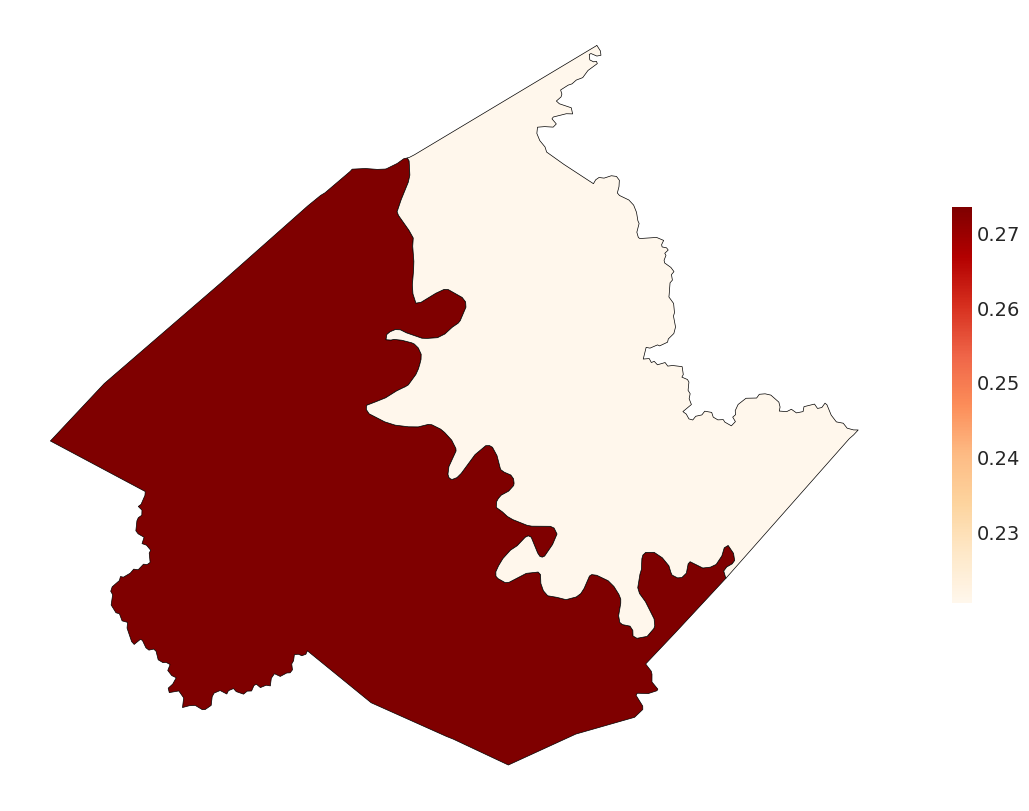

Plotting SVI data for FIPS: 54041


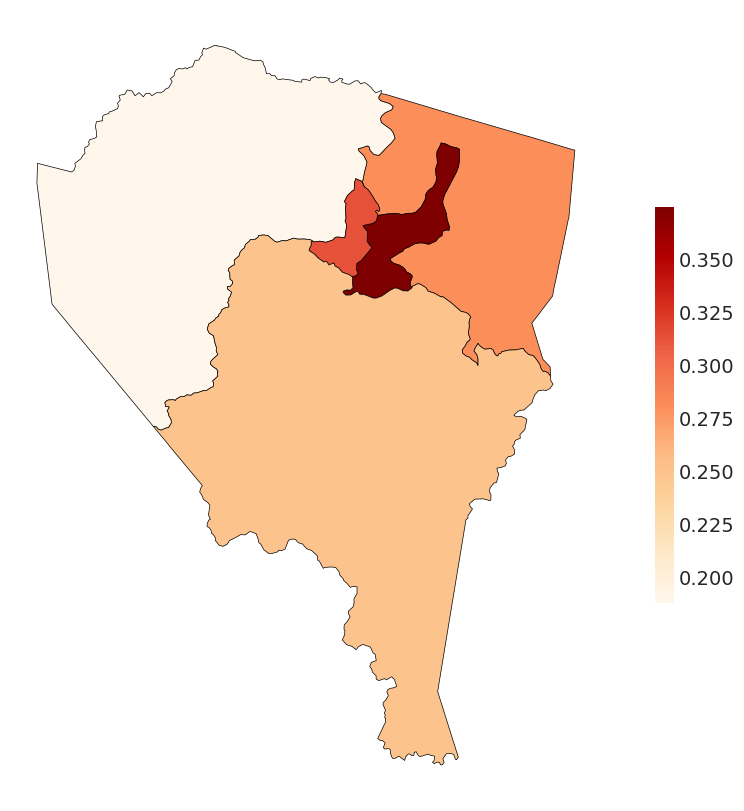

Plotting SVI data for FIPS: 54109


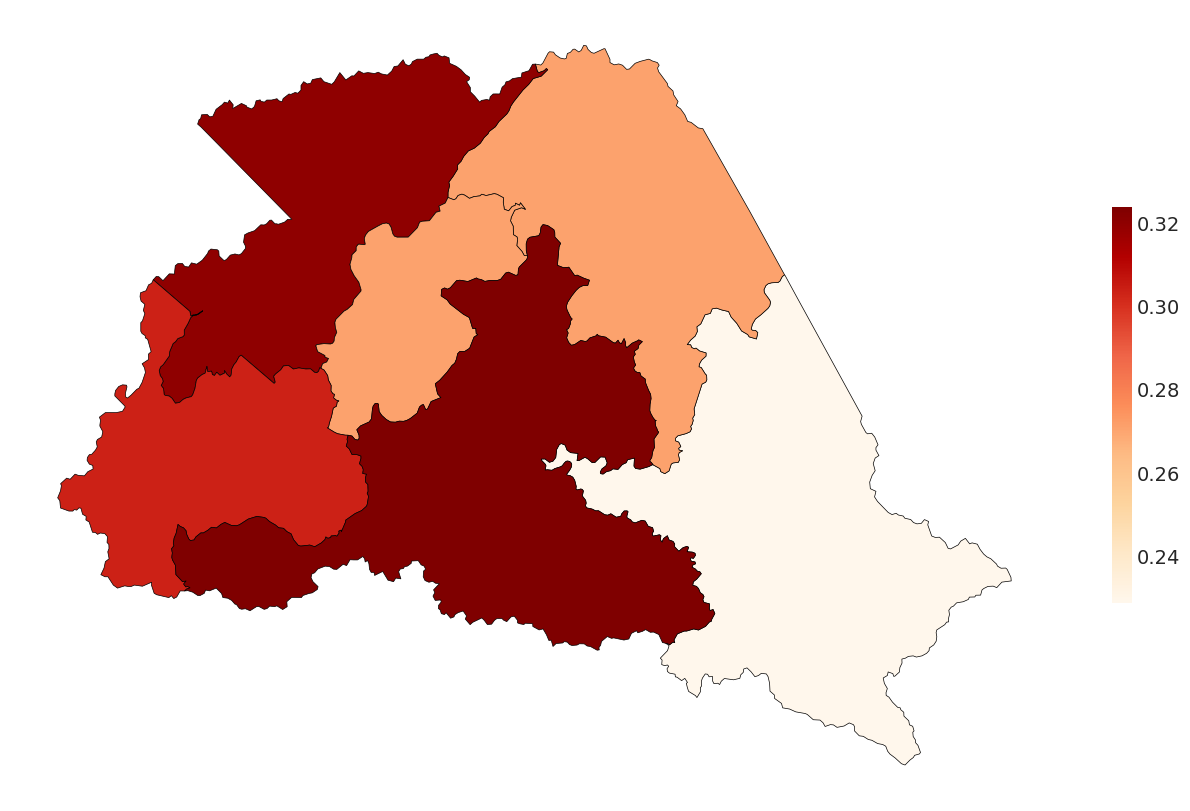

Plotting SVI data for FIPS: 54005


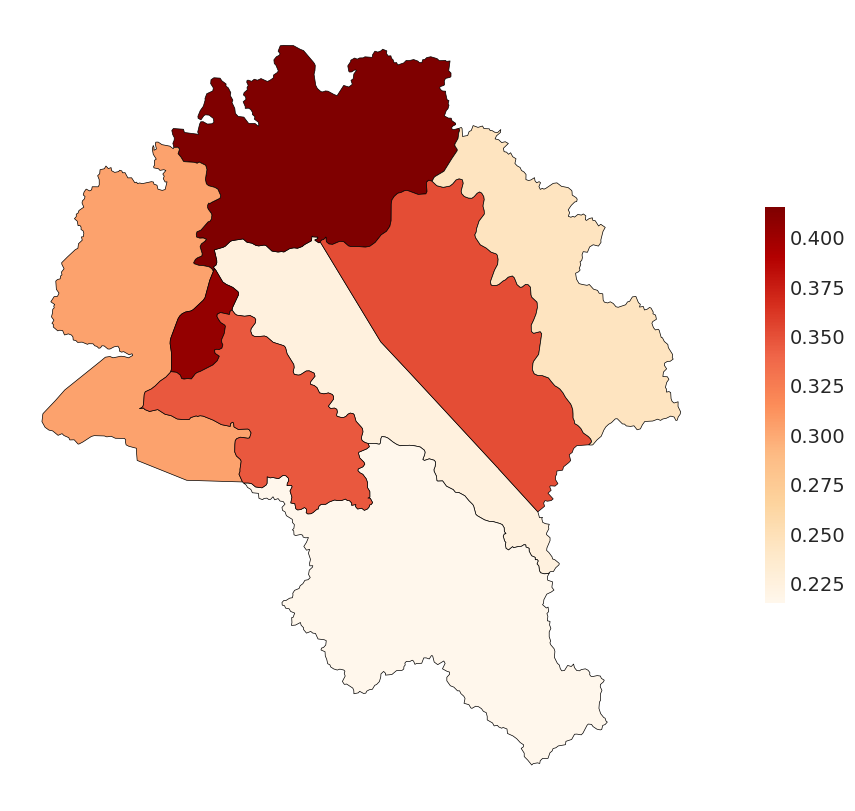

Plotting SVI data for FIPS: 54007


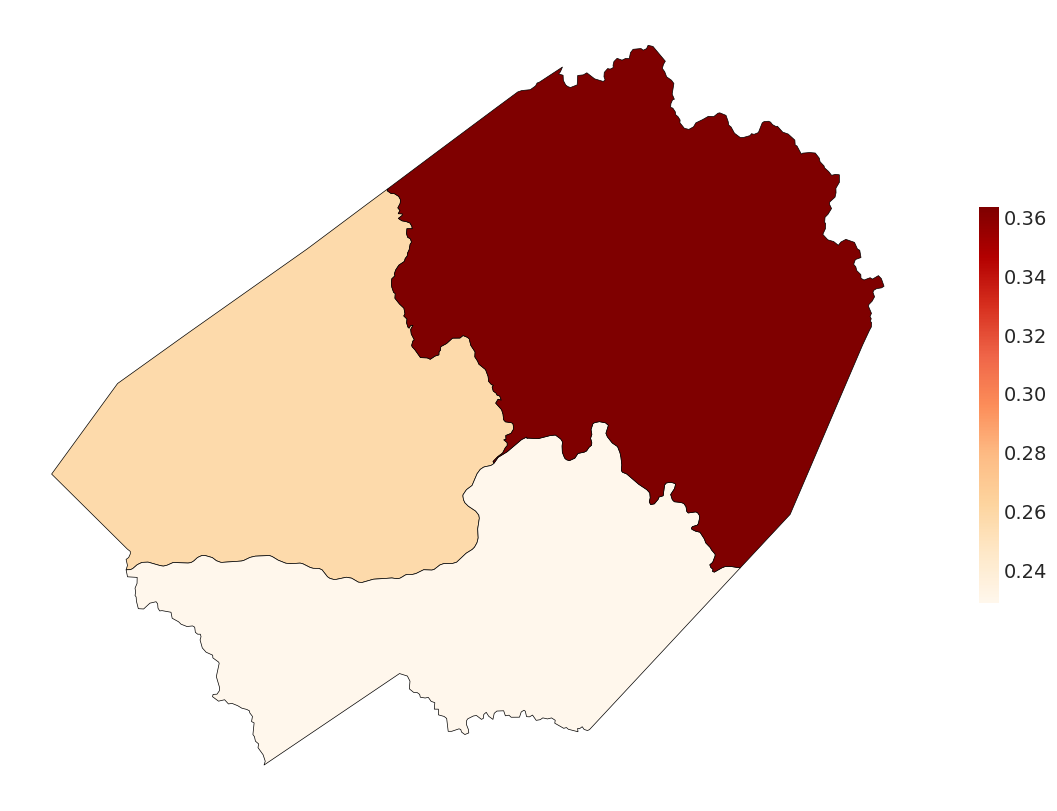

Plotting SVI data for FIPS: 54009


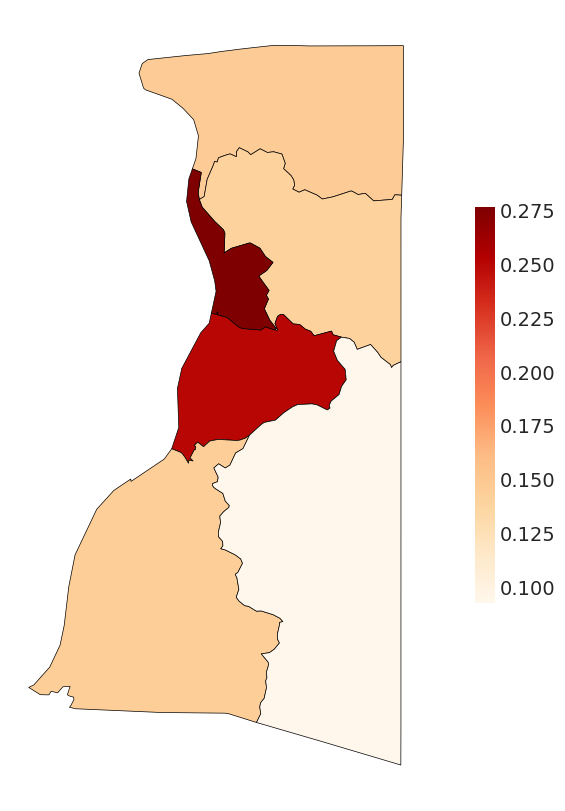

Plotting SVI data for FIPS: 54013


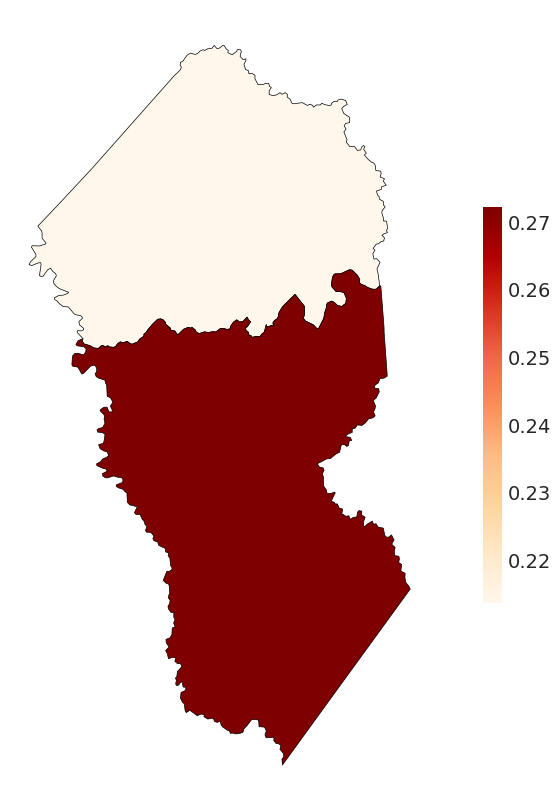

Plotting SVI data for FIPS: 54093


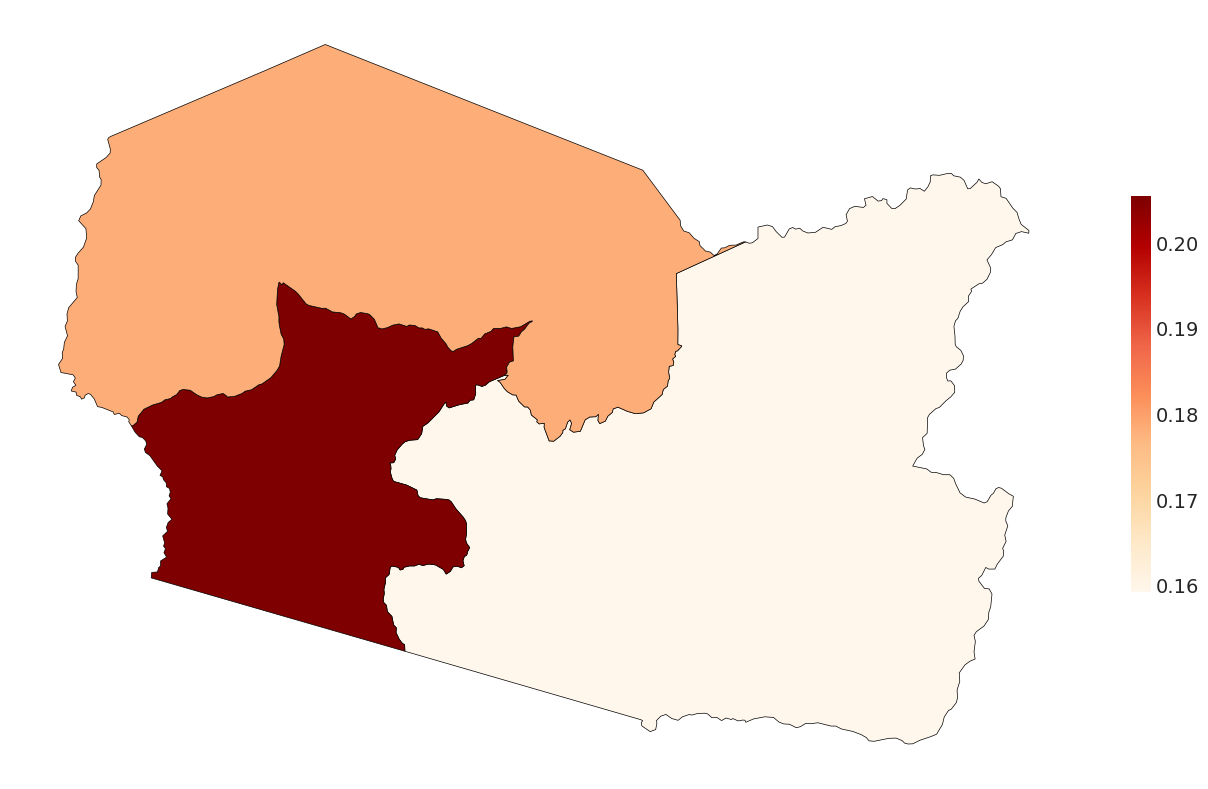

Plotting SVI data for FIPS: 54085


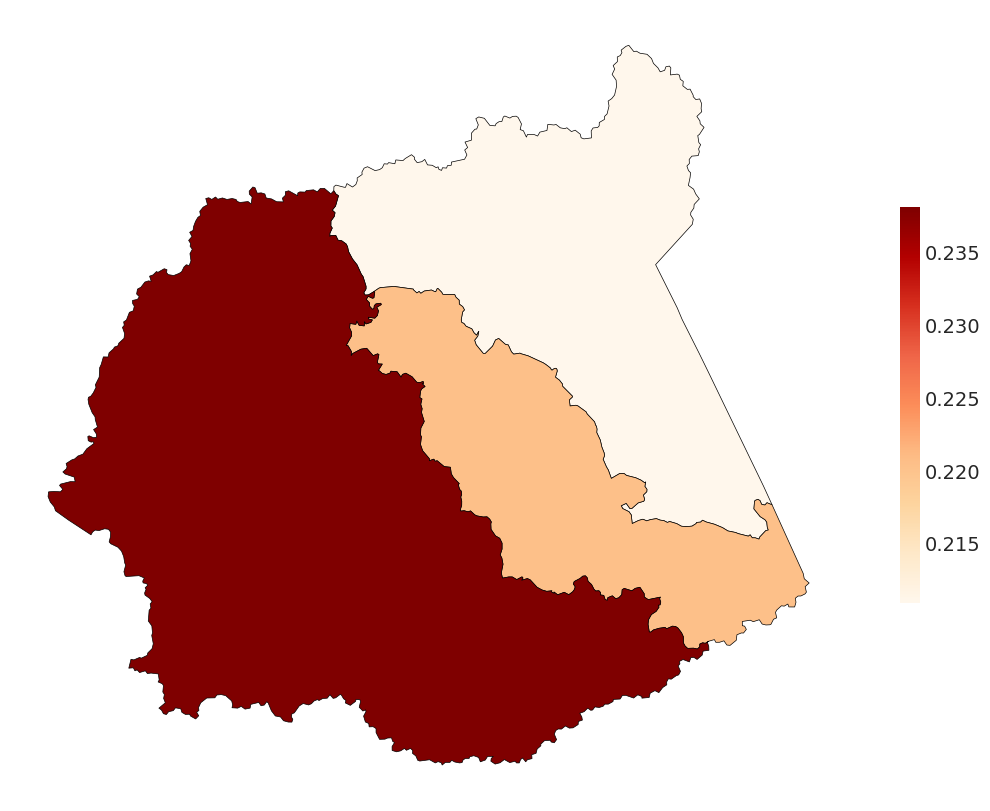

Plotting SVI data for FIPS: 54023


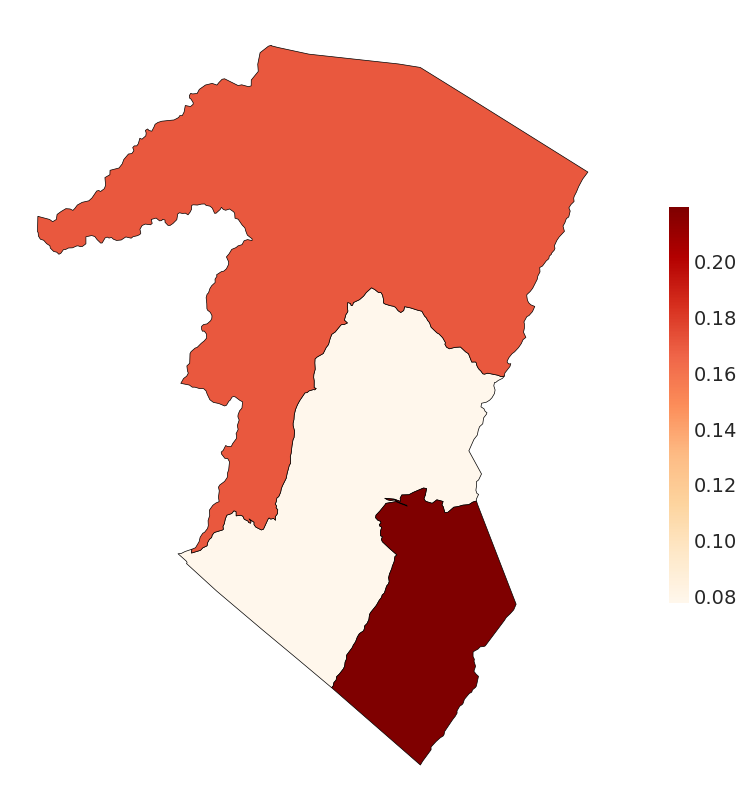

Plotting SVI data for FIPS: 54073


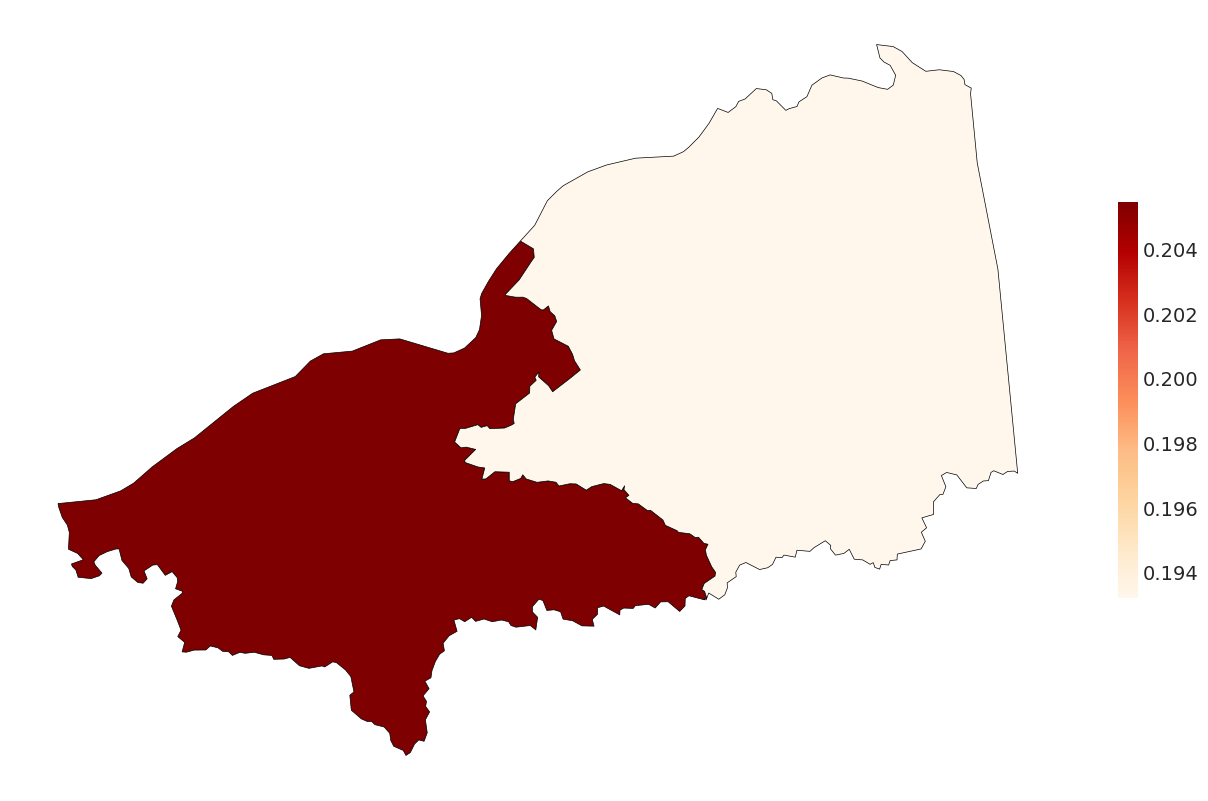

Plotting SVI data for FIPS: 54091


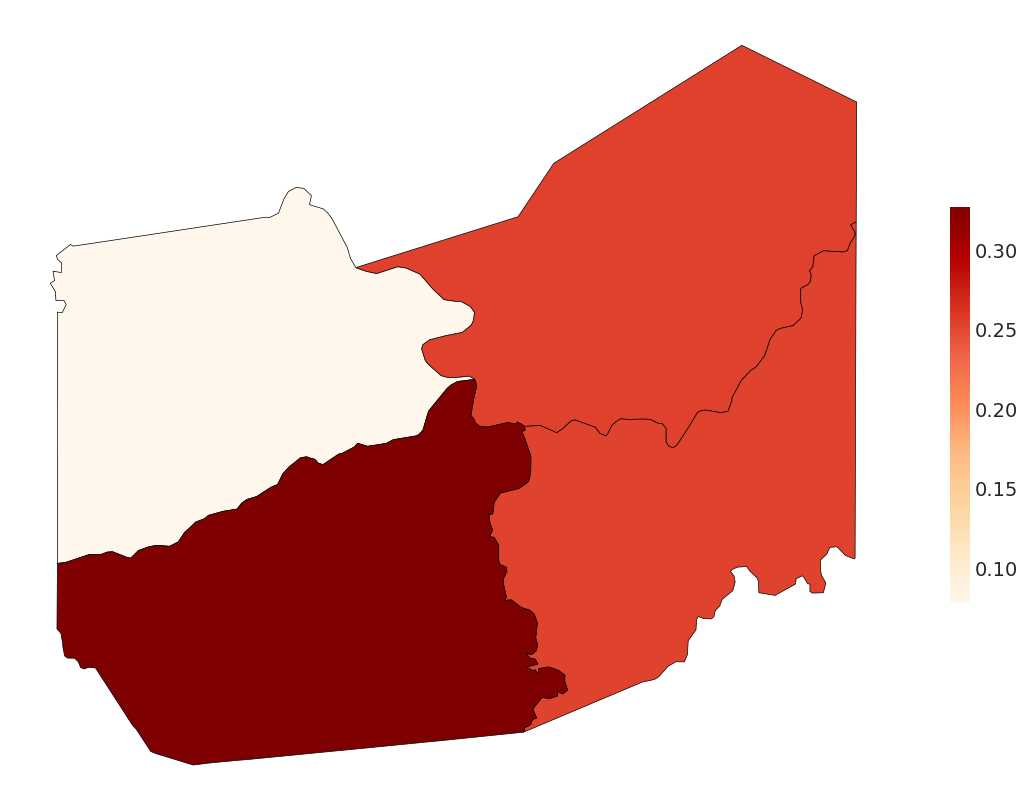

Plotting SVI data for FIPS: 54087


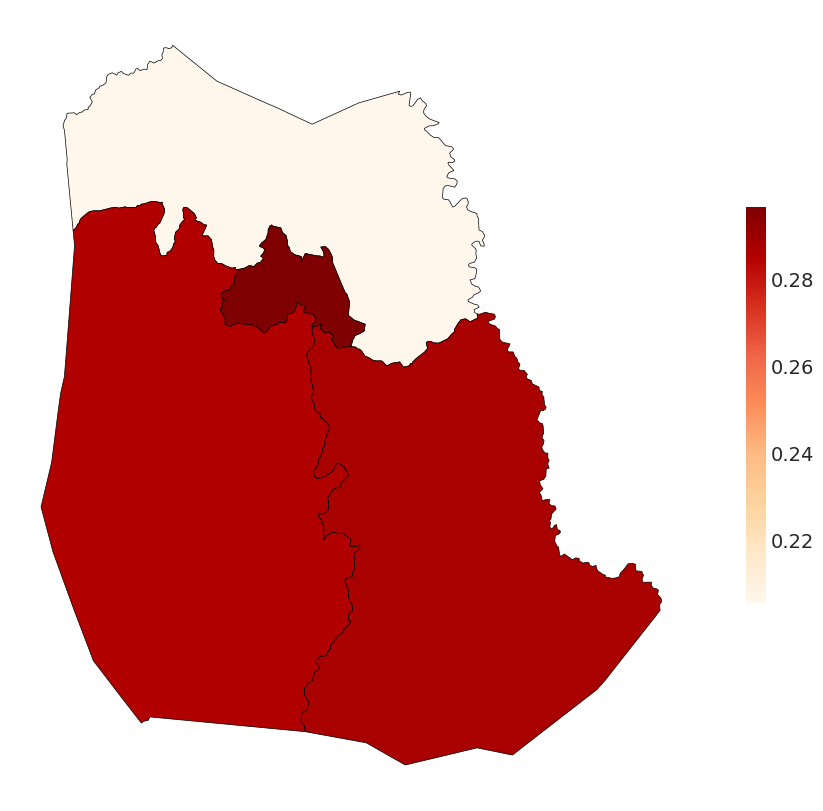

Plotting SVI data for FIPS: 54103


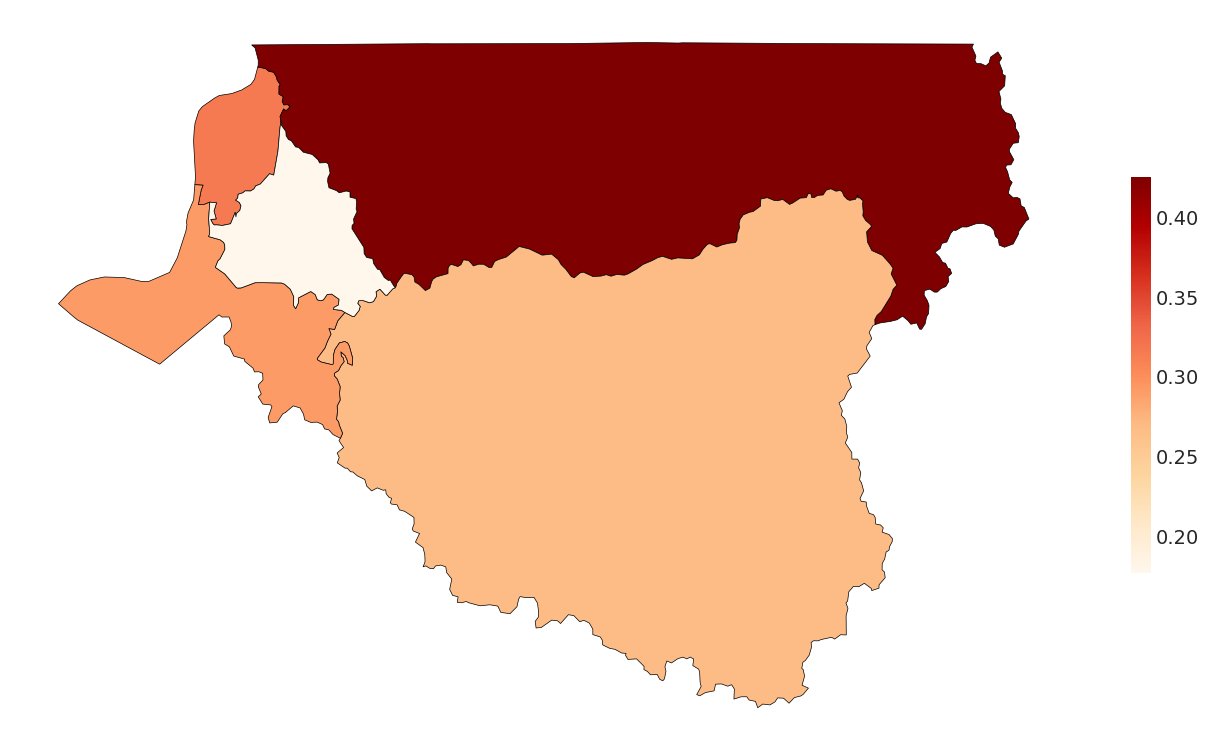

Plotting SVI data for FIPS: 54095


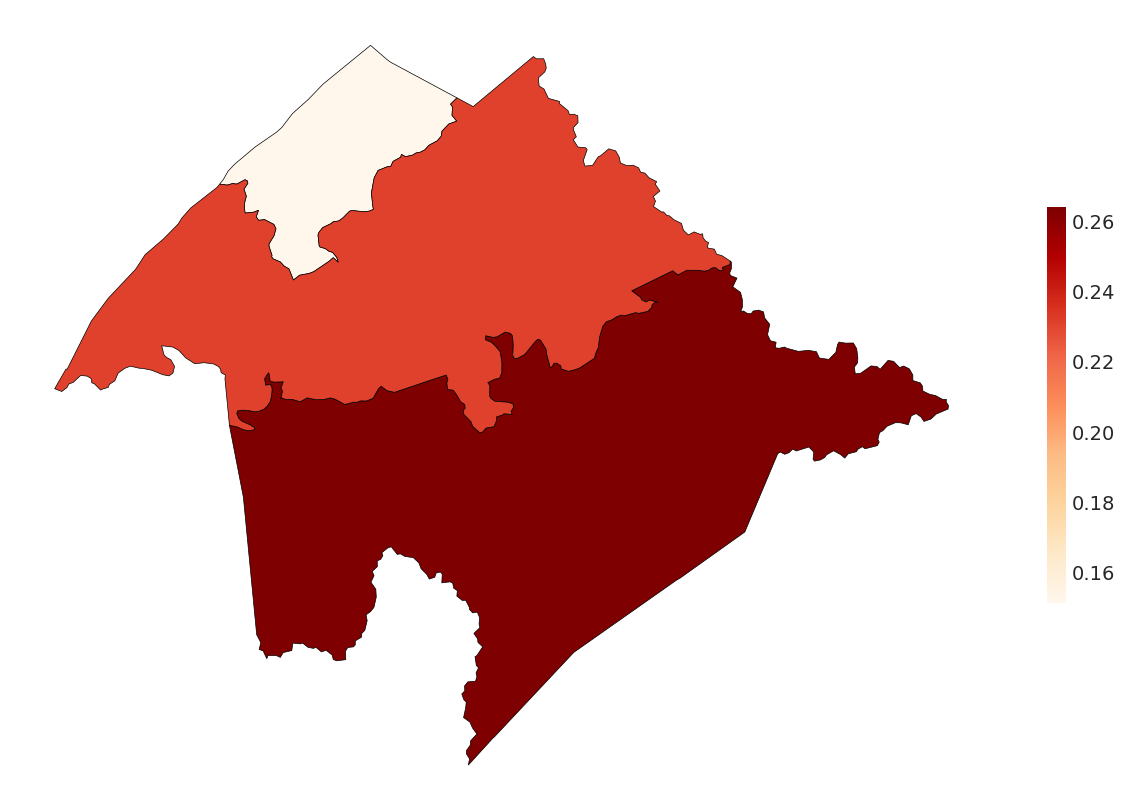

In [105]:
# for Increase in relative risk difference percentage less than -10% FIPS plot the geometry and EP_POV column
for fips in significant_changes[significant_changes["Change Direction"] == "Decrease" ]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
    ax.set_facecolor("white")  # set axes background to white

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},  # Makes the legend smaller
        # Style for NaN values:
        missing_kwds={
            "color": "lightgrey",       # fill color for NaN
            "edgecolor": "black",       # edge color for NaN polygons
            "hatch": "///",             # add hatching for NaN
            "label": "No Data"          # adds entry in legend
        }
    )   
    # Remove axis ticks for a cleaner map visualization
    ax.set_xticks([])
    ax.set_yticks([])   
    # Show the plot
    plt.show()

Increasing areas with their own scale

Plotting SVI data for FIPS: 54021


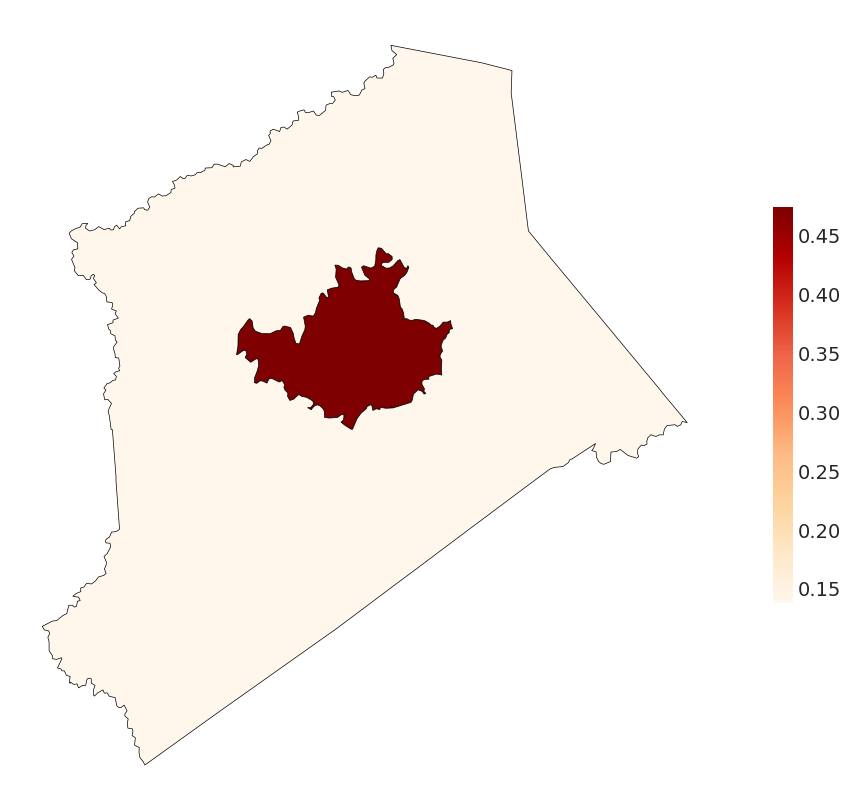

Plotting SVI data for FIPS: 54049


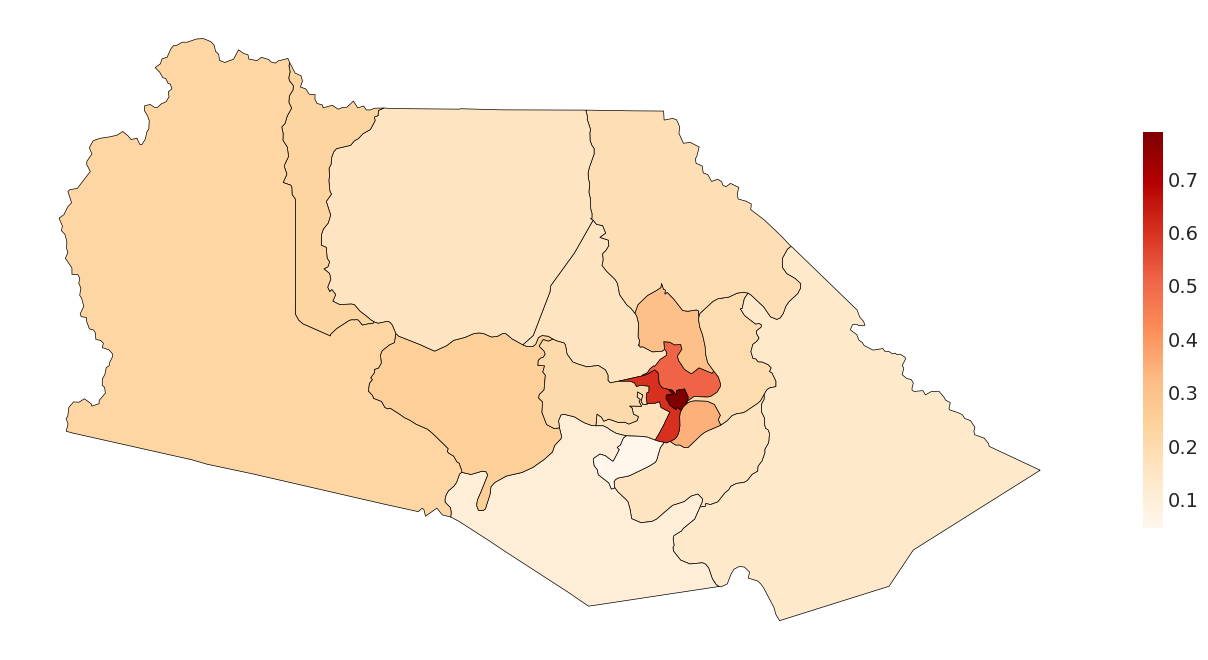

Plotting SVI data for FIPS: 54089


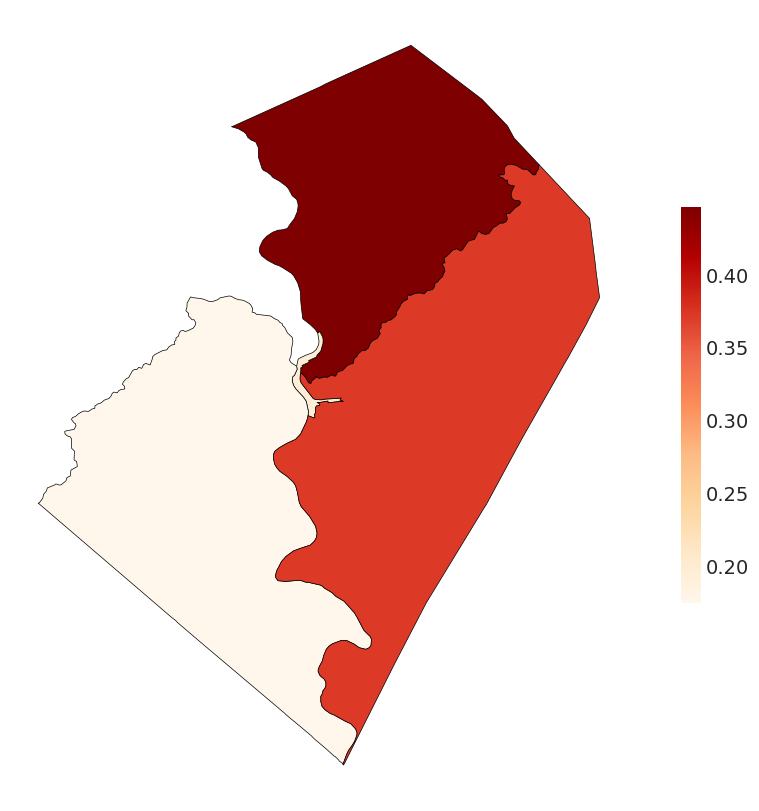

Plotting SVI data for FIPS: 54059


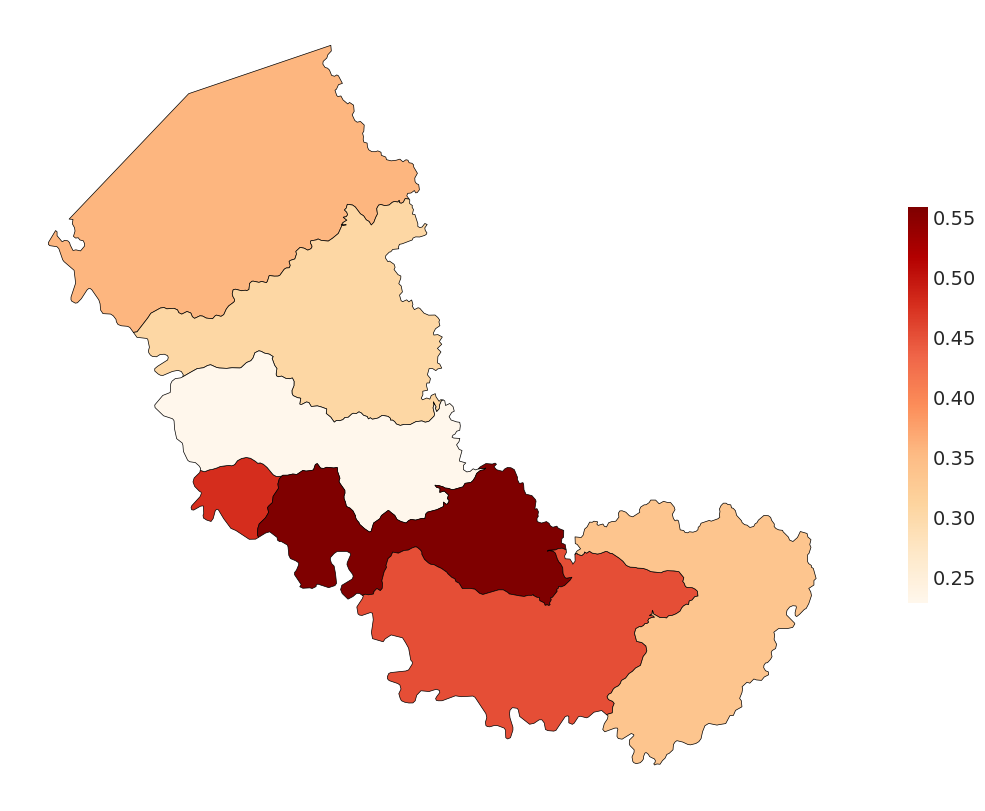

Plotting SVI data for FIPS: 54043


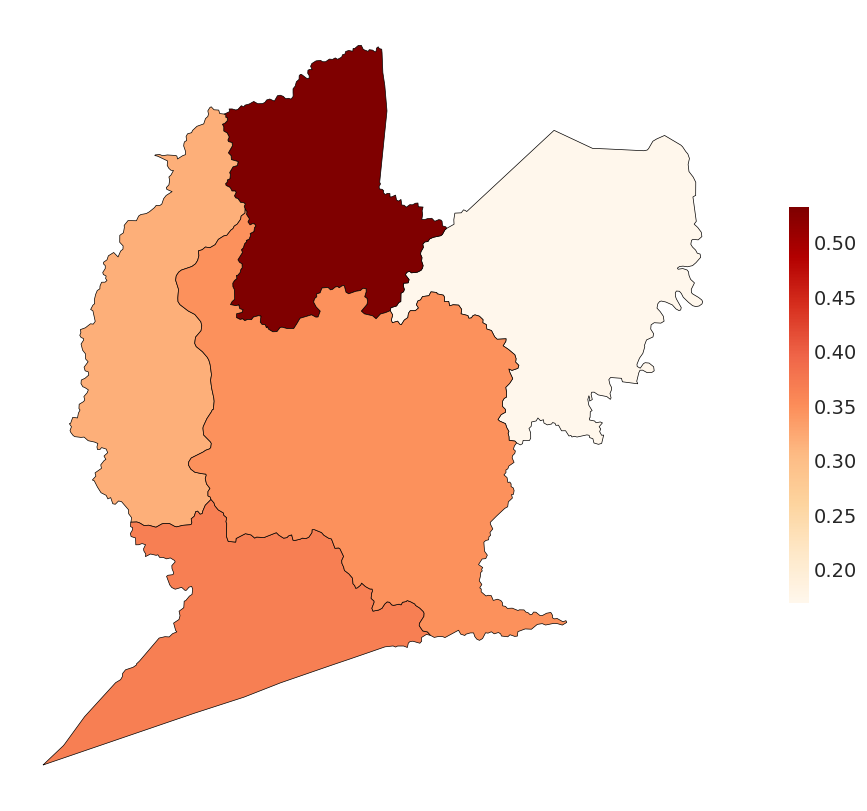

In [96]:
# for Increase in relative risk difference percentage less than -10% FIPS plot the geometry and EP_POV column
for fips in significant_changes[significant_changes["Change Direction"] == "Increase" ]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
    ax.set_facecolor("white")  # set axes background to white

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},  # Makes the legend smaller
        # Style for NaN values:
        missing_kwds={
            "color": "lightgrey",       # fill color for NaN
            "edgecolor": "black",       # edge color for NaN polygons
            "hatch": "///",             # add hatching for NaN
            "label": "No Data"          # adds entry in legend
        }
    )   
    # Remove axis ticks for a cleaner map visualization
    ax.set_xticks([])
    ax.set_yticks([])   
    # Show the plot
    plt.show()

Decreasing areas with 0-1 scale

Plotting SVI data for FIPS: 54105
EP_POV - Min: 0.220408163265306, Max: 0.273469387755102
Plotting SVI data for FIPS: 54041
EP_POV - Min: 0.187755102040816, Max: 0.374149659863946
Plotting SVI data for FIPS: 54109
EP_POV - Min: 0.228571428571429, Max: 0.323809523809524
Plotting SVI data for FIPS: 54005
EP_POV - Min: 0.214965986394558, Max: 0.414965986394558
Plotting SVI data for FIPS: 54007
EP_POV - Min: 0.228571428571429, Max: 0.363265306122449
Plotting SVI data for FIPS: 54009
EP_POV - Min: 0.092517006802721, Max: 0.276190476190476
Plotting SVI data for FIPS: 54013
EP_POV - Min: 0.213605442176871, Max: 0.272108843537415
Plotting SVI data for FIPS: 54093
EP_POV - Min: 0.159183673469388, Max: 0.205442176870748
Plotting SVI data for FIPS: 54085
EP_POV - Min: 0.210884353741497, Max: 0.238095238095238
Plotting SVI data for FIPS: 54023
EP_POV - Min: 0.077551020408163, Max: 0.219047619047619
Plotting SVI data for FIPS: 54073
EP_POV - Min: 0.193197278911565, Max: 0.205442176870748
Plotting S

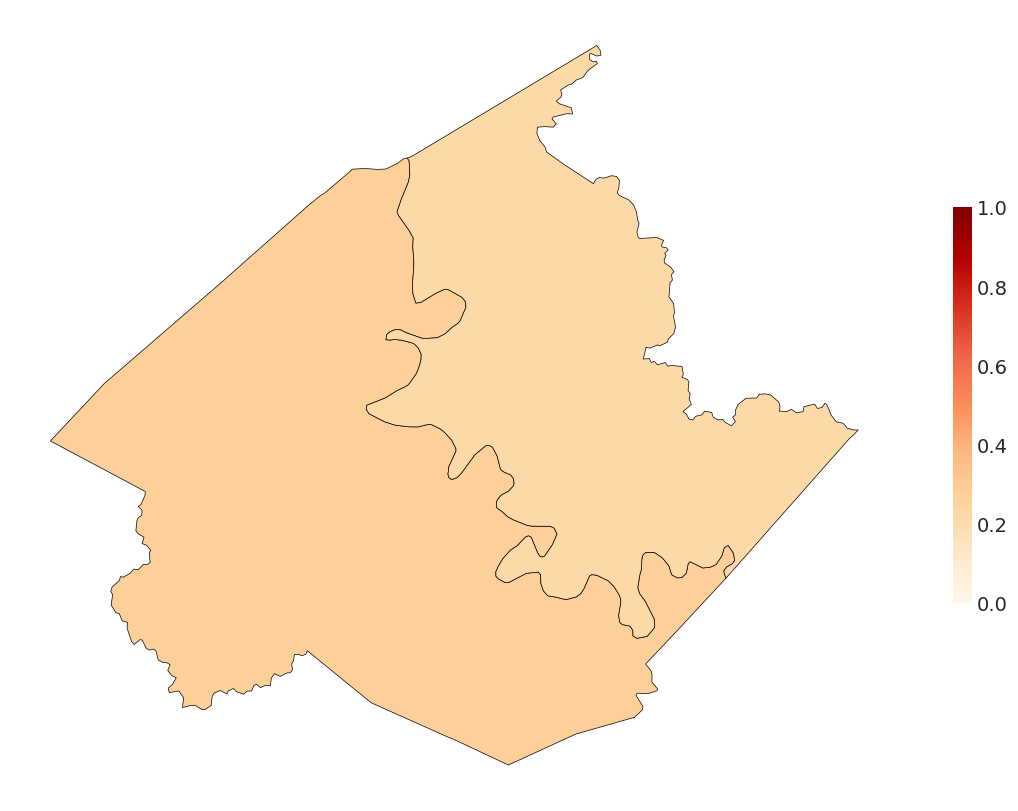

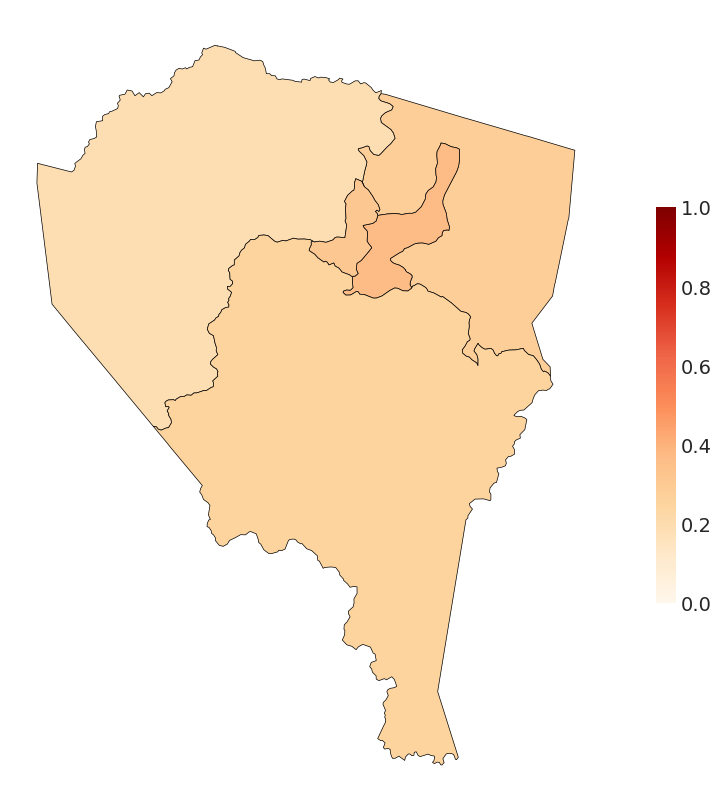

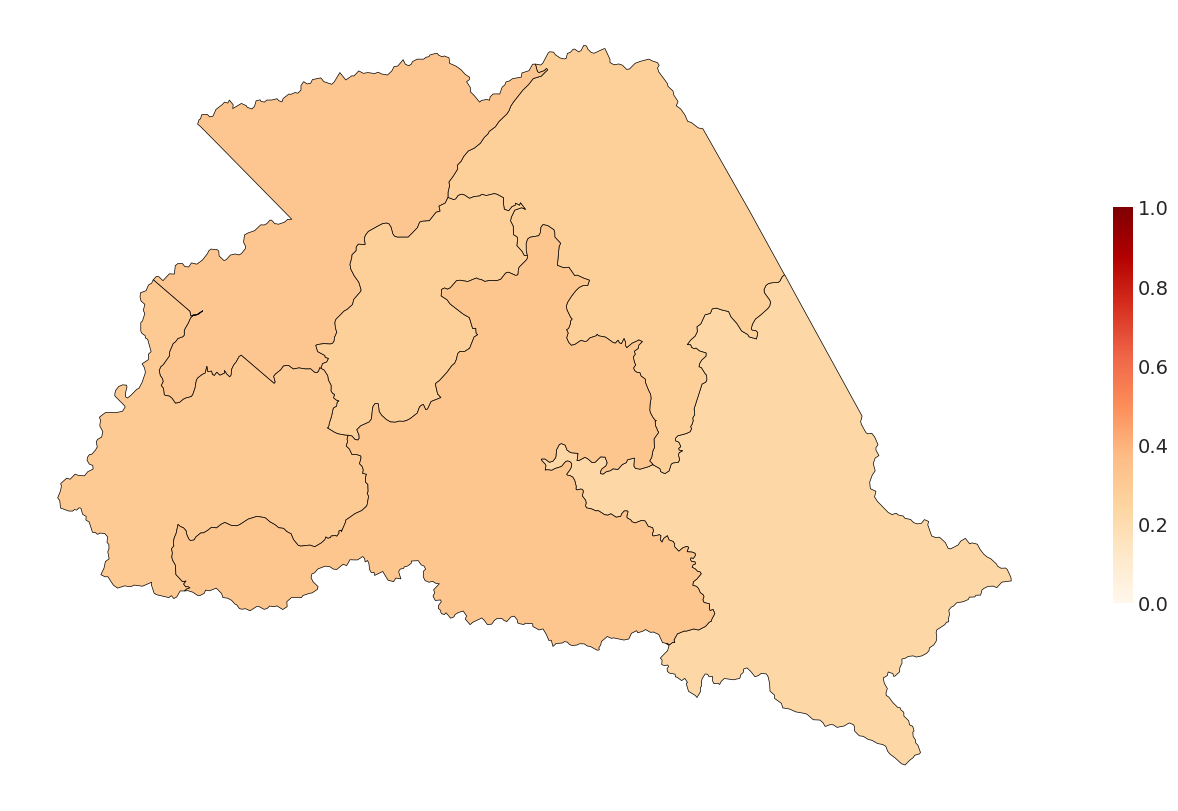

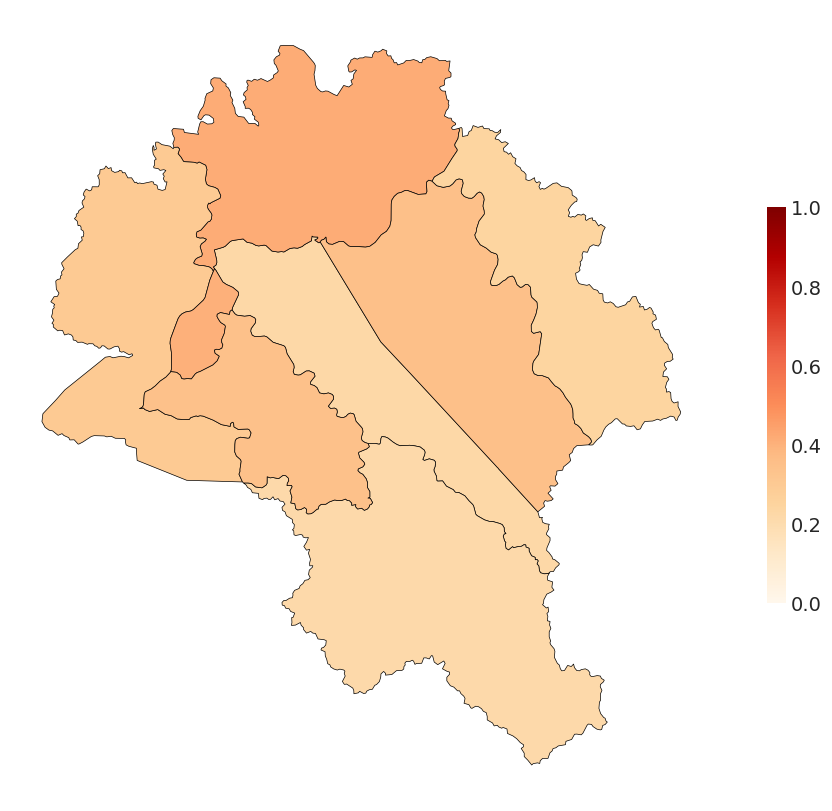

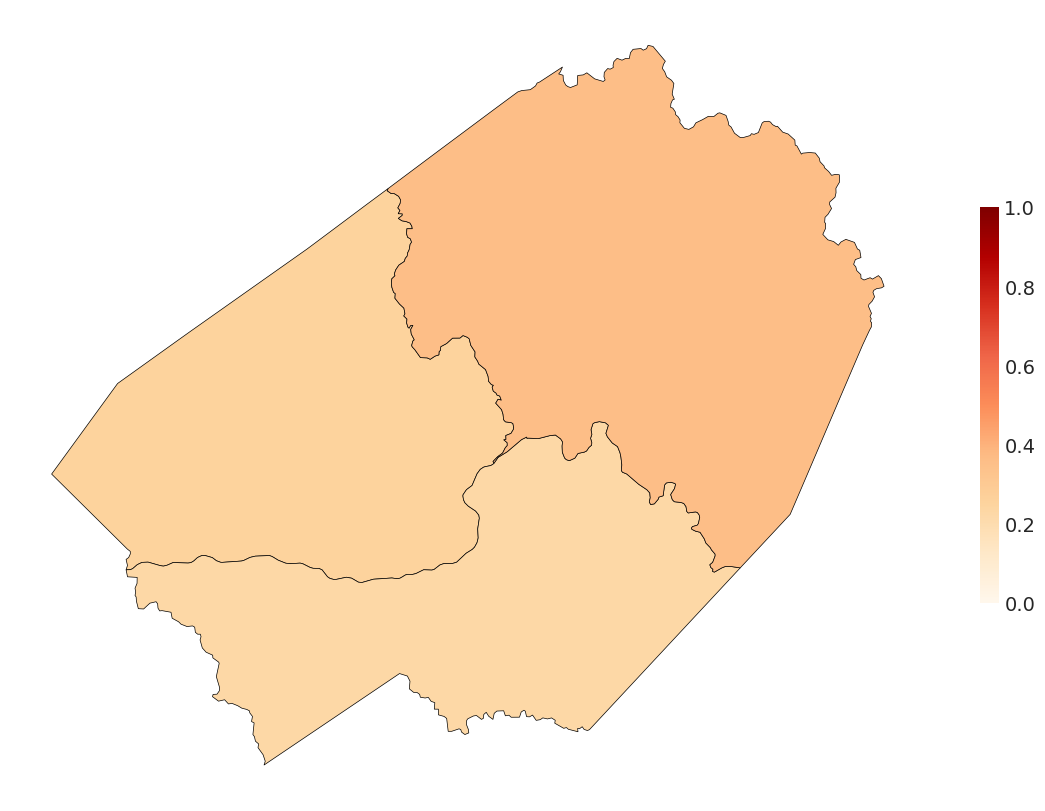

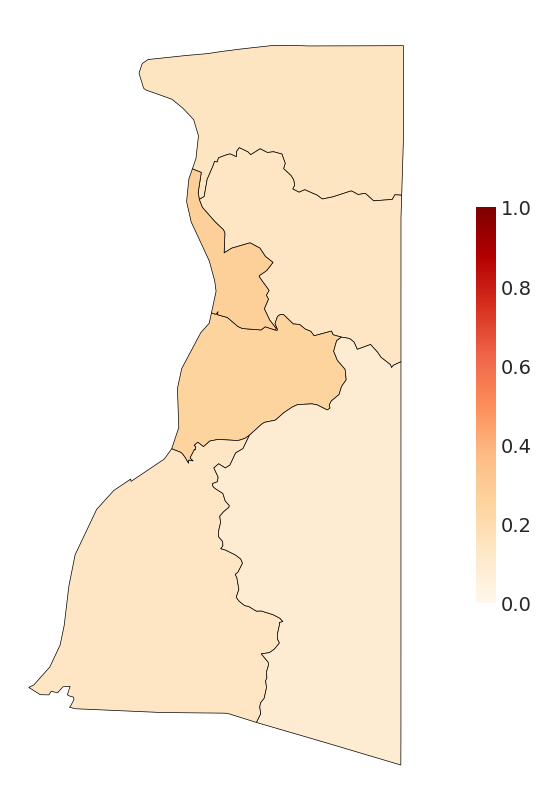

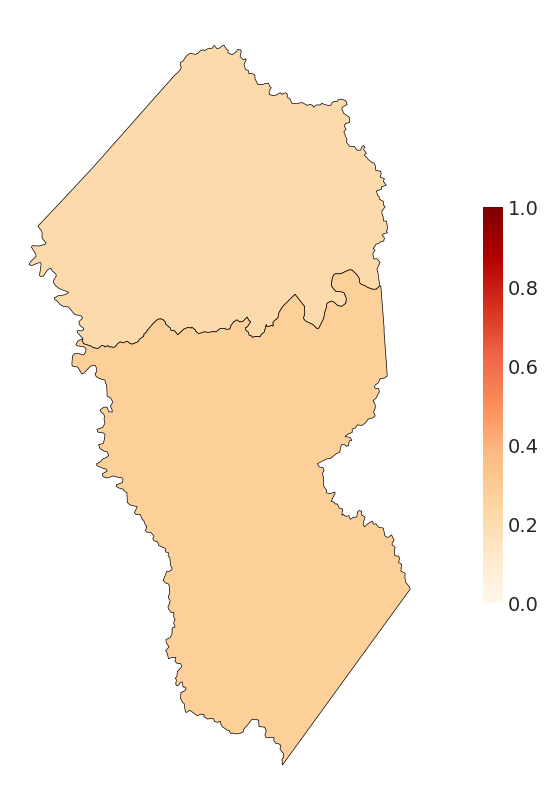

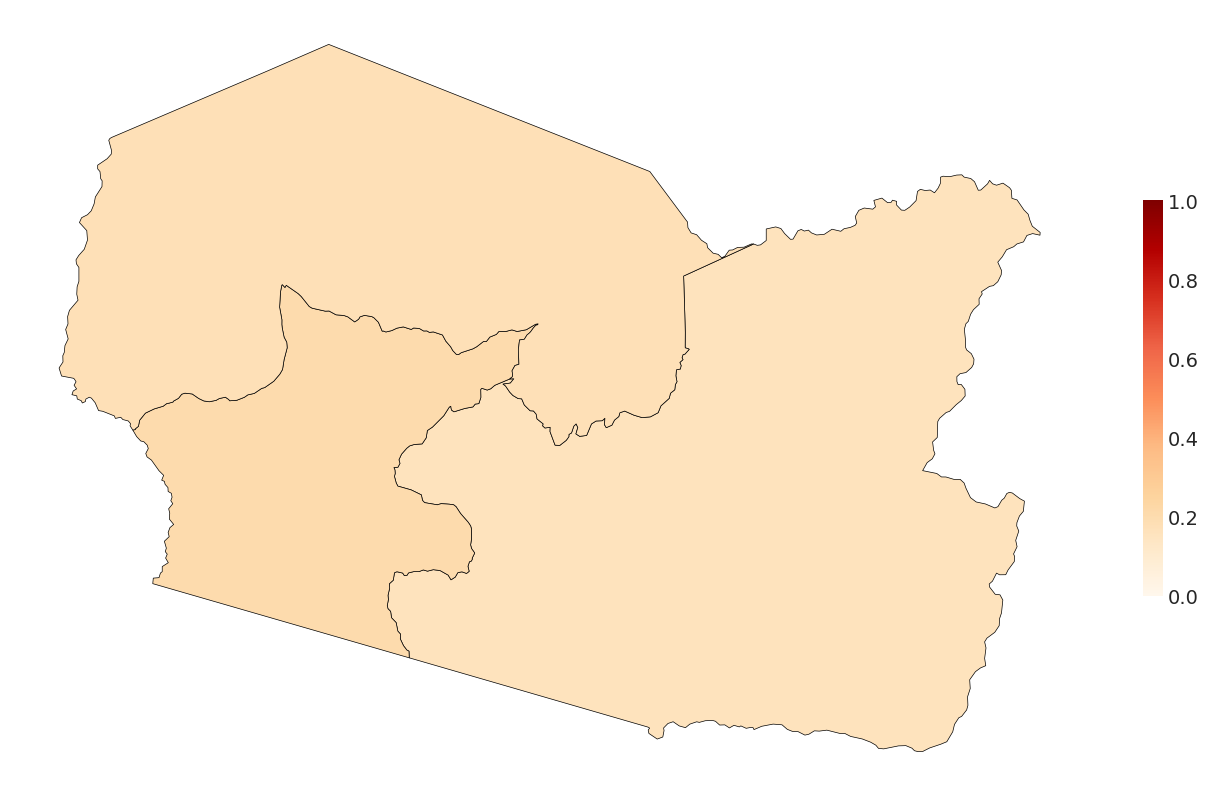

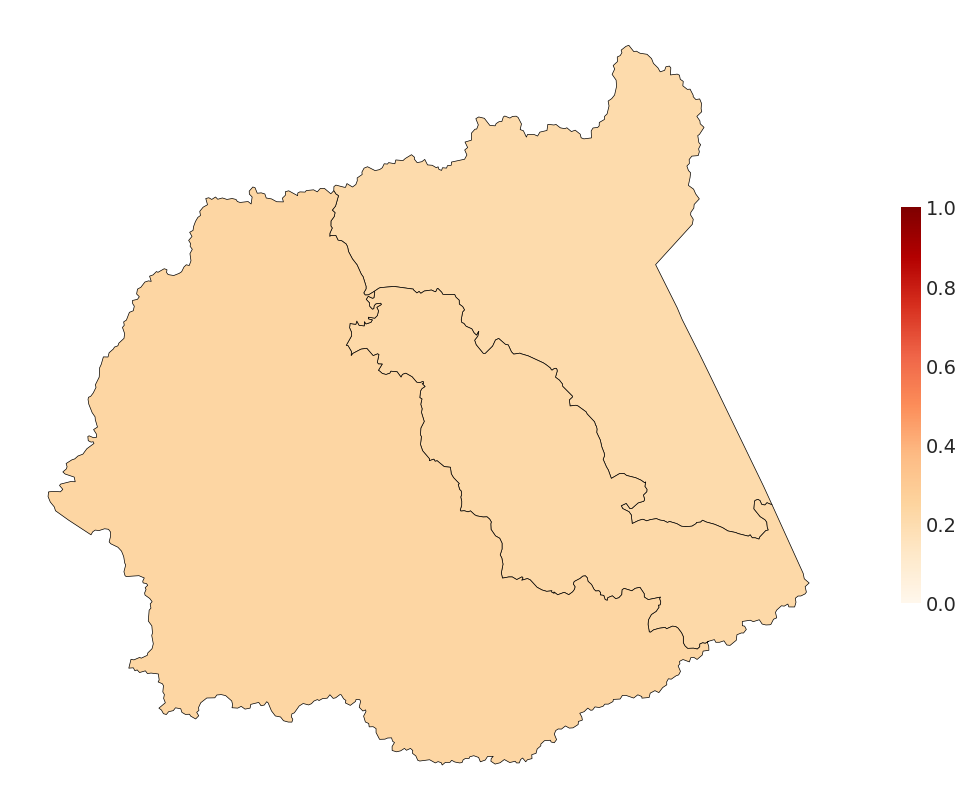

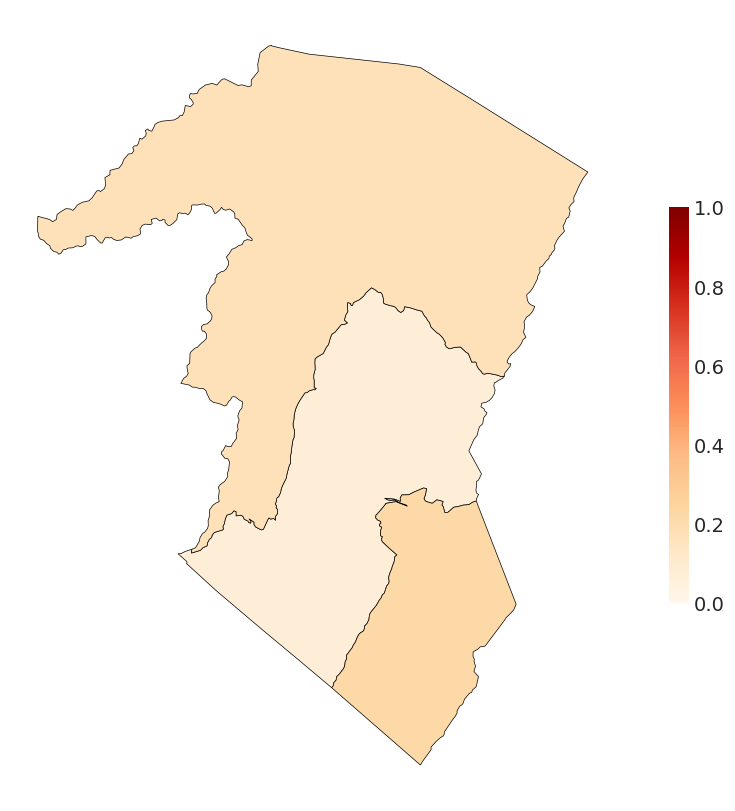

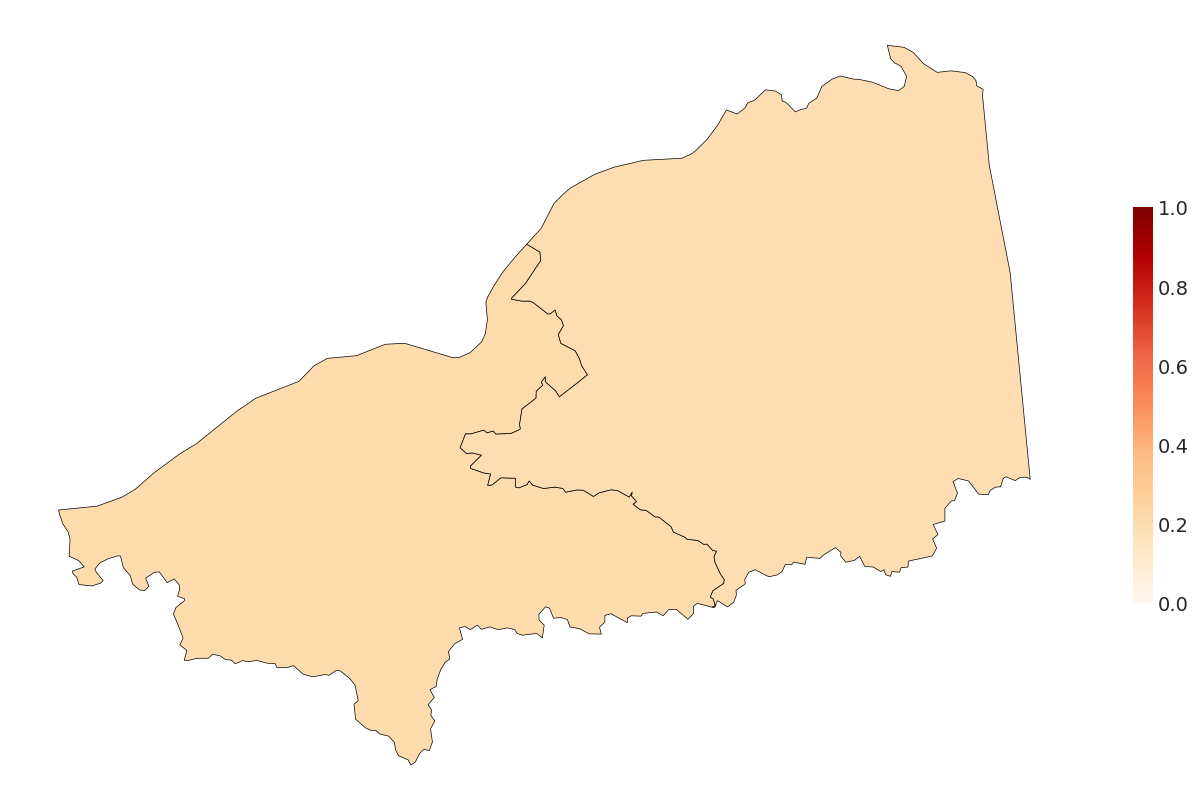

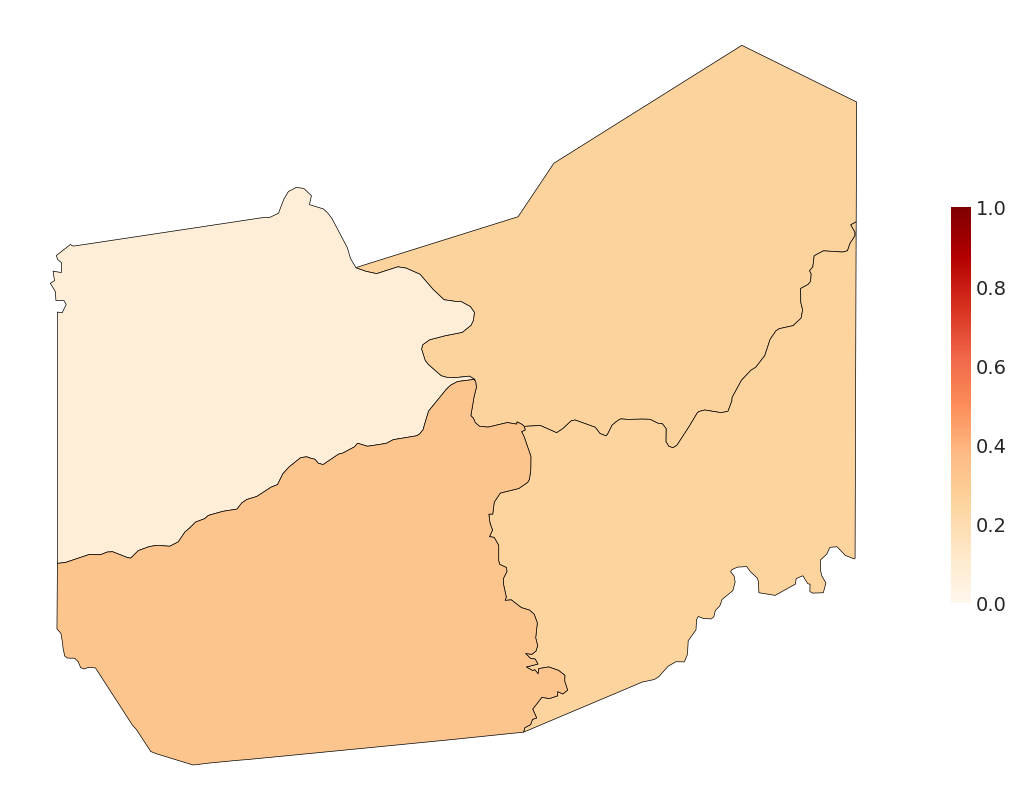

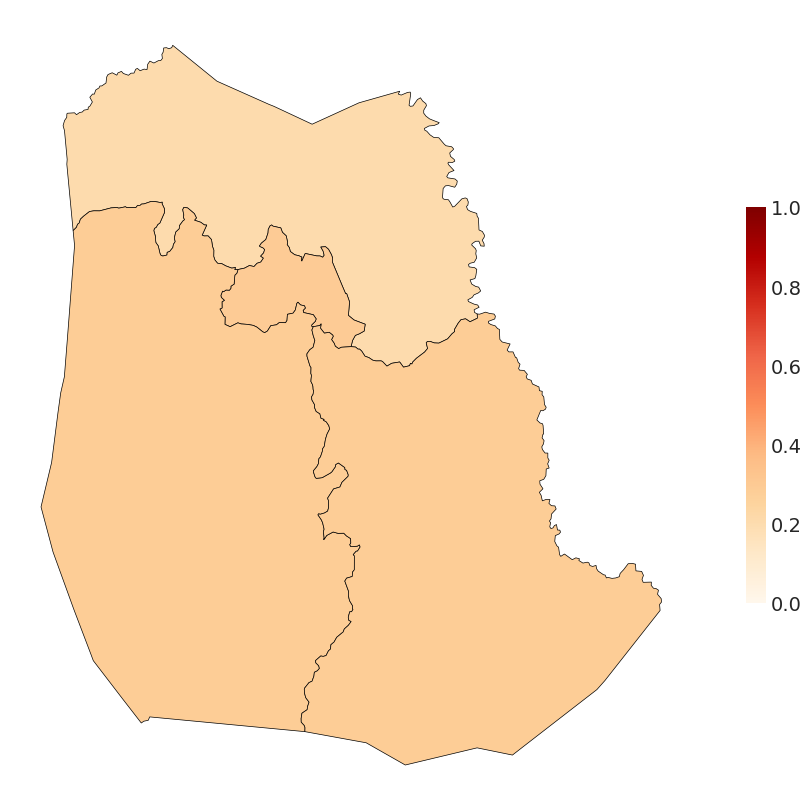

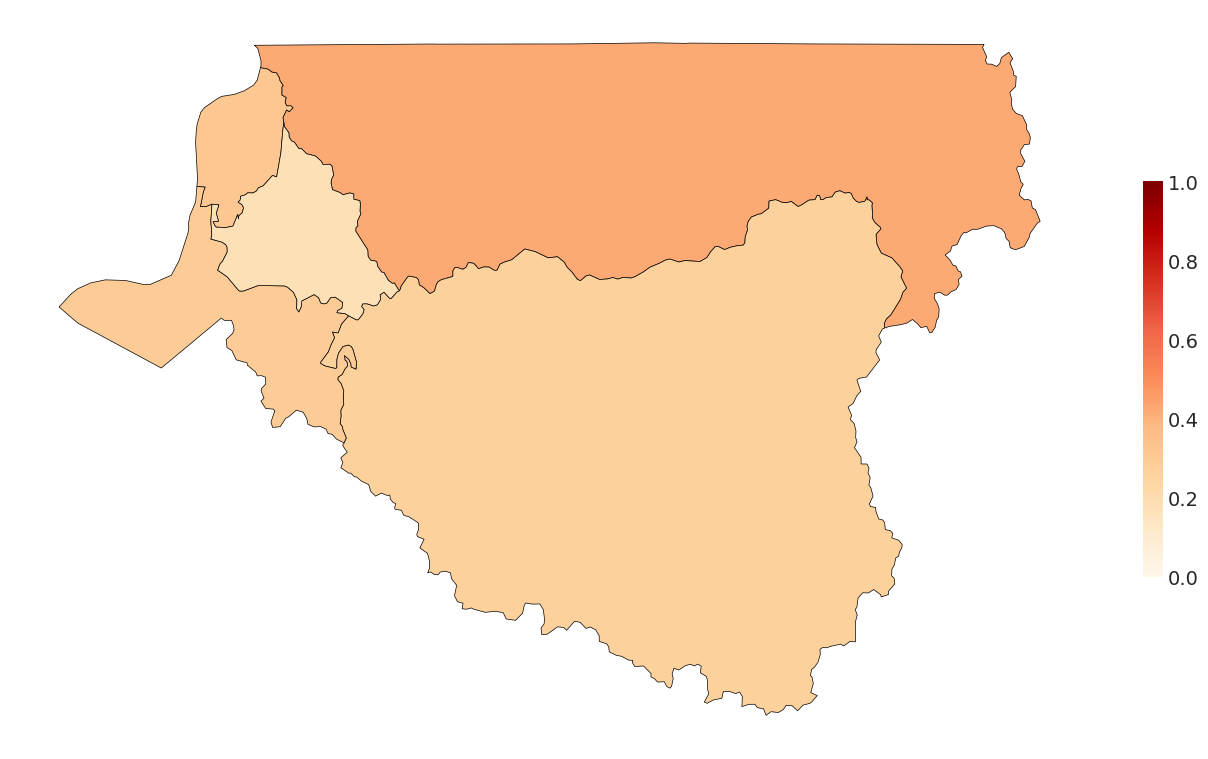

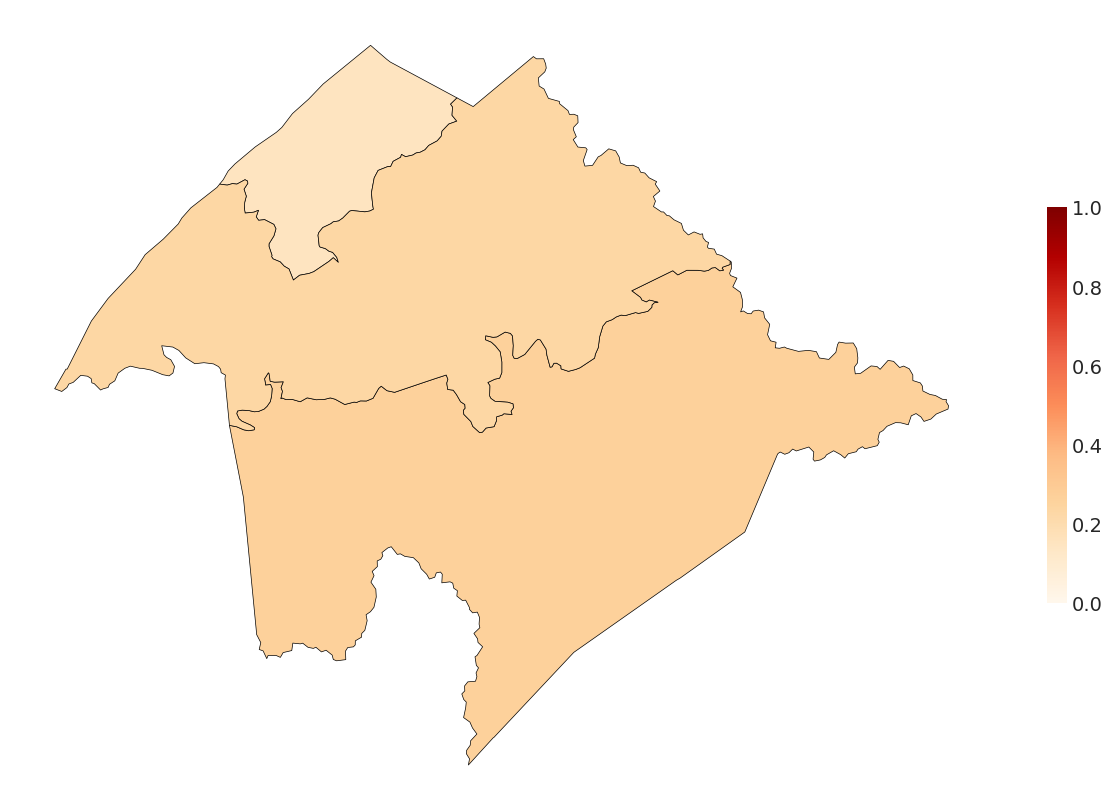

In [144]:

for fips in significant_changes[significant_changes["Change Direction"] == "Decrease"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    print(f"EP_POV - Min: {svi_temp_area['EP_POV'].min()}, Max: {svi_temp_area['EP_POV'].max()}")

    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=0,   # Anchor the bottom of the color scale at 0
        vmax=1,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    # plt.show()

    plt.savefig(os.path.join( save_path,"0_1_scale", f"EP_POV_{fips}_decreasing.png"), bbox_inches='tight', dpi=300)

Increasing ing areas with 0-1 scale

Plotting SVI data for FIPS: 54021
EP_POV - Min: 0.137414965986395, Max: 0.473469387755102
Plotting SVI data for FIPS: 54049
EP_POV - Min: 0.046258503401361, Max: 0.787755102040816
Plotting SVI data for FIPS: 54089
EP_POV - Min: 0.174149659863946, Max: 0.446258503401361
Plotting SVI data for FIPS: 54059
EP_POV - Min: 0.228571428571429, Max: 0.557823129251701
Plotting SVI data for FIPS: 54043
EP_POV - Min: 0.168707482993197, Max: 0.531972789115646


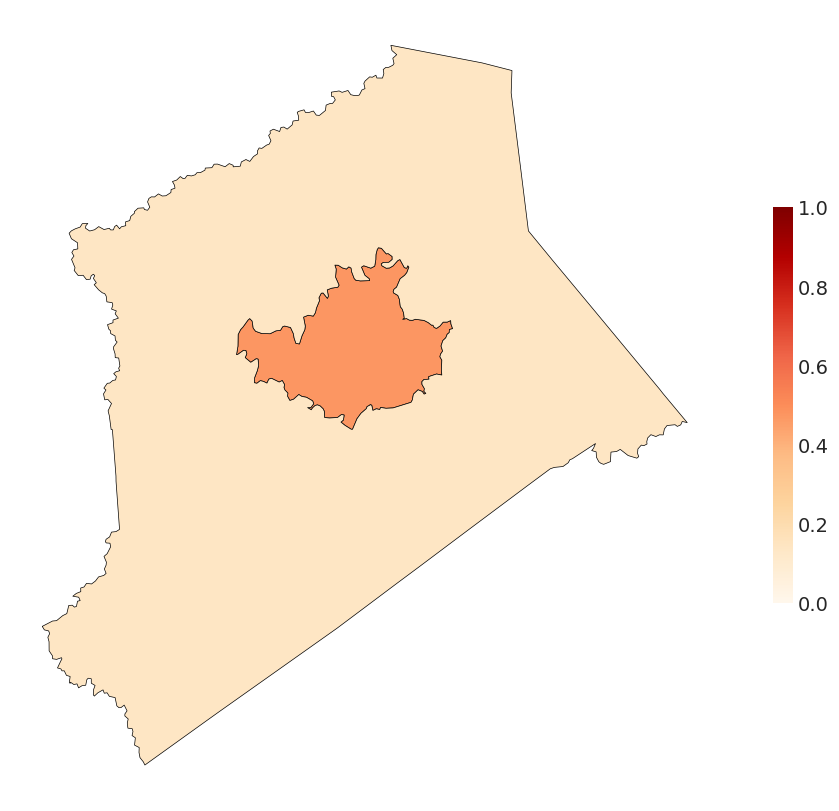

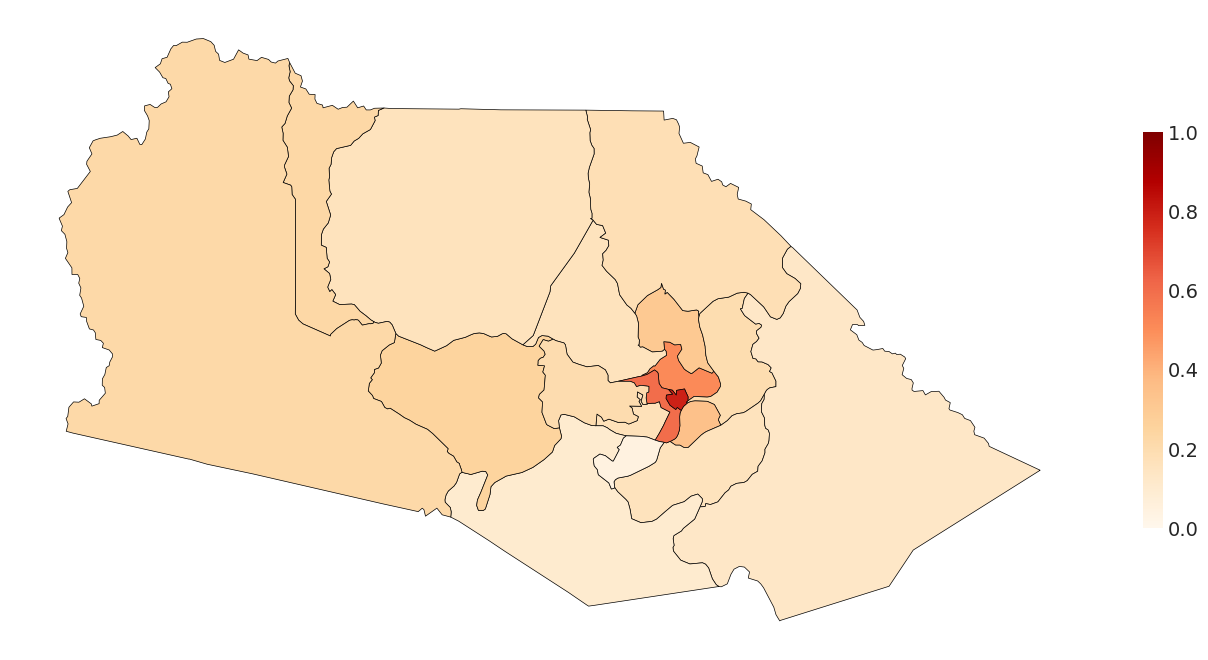

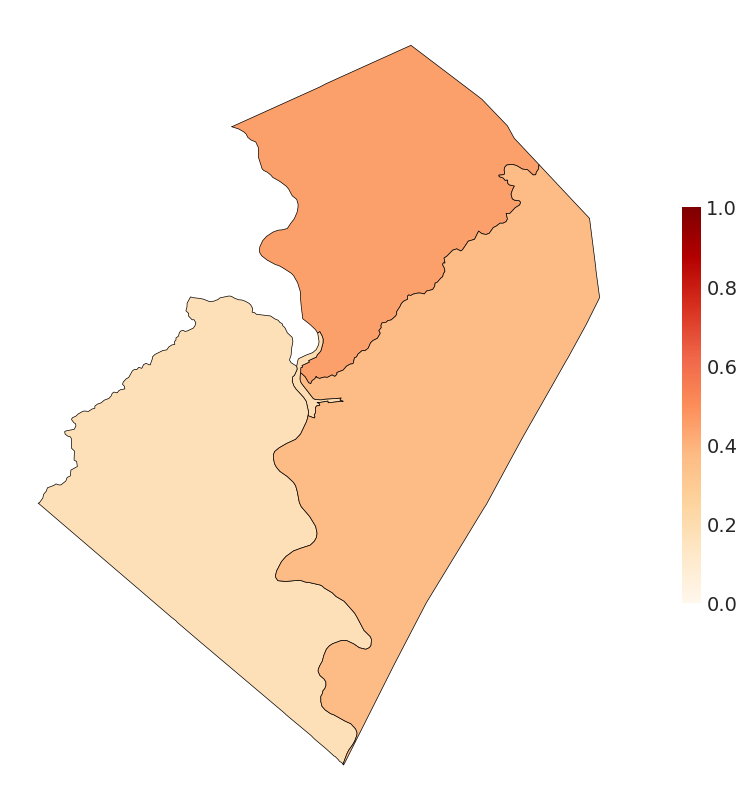

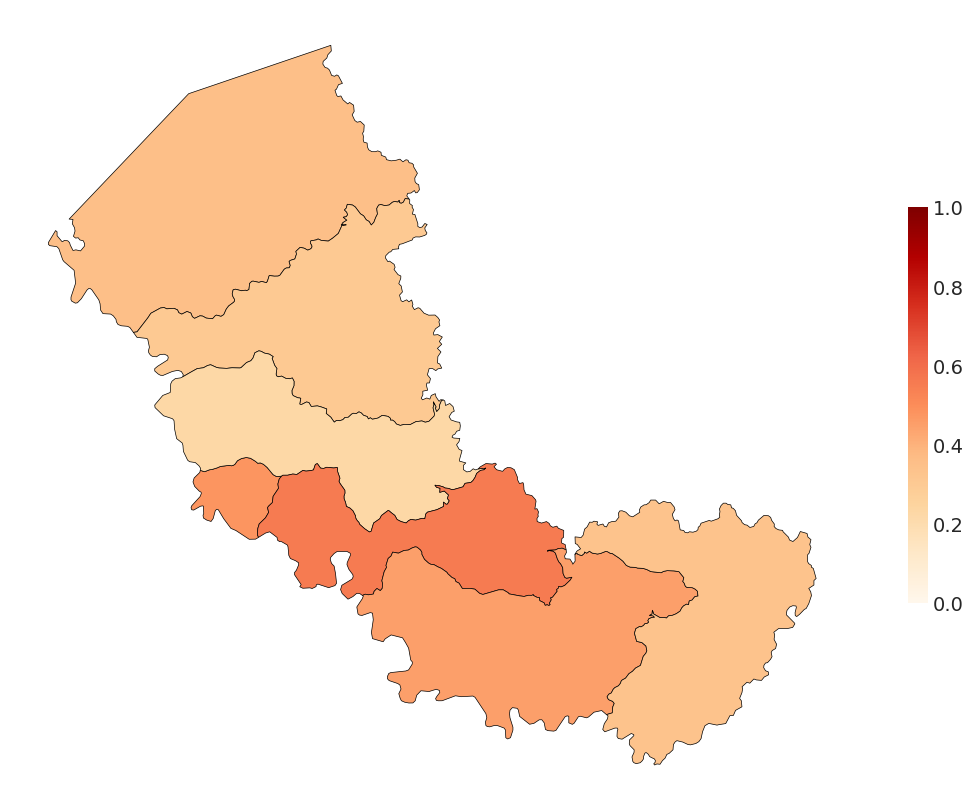

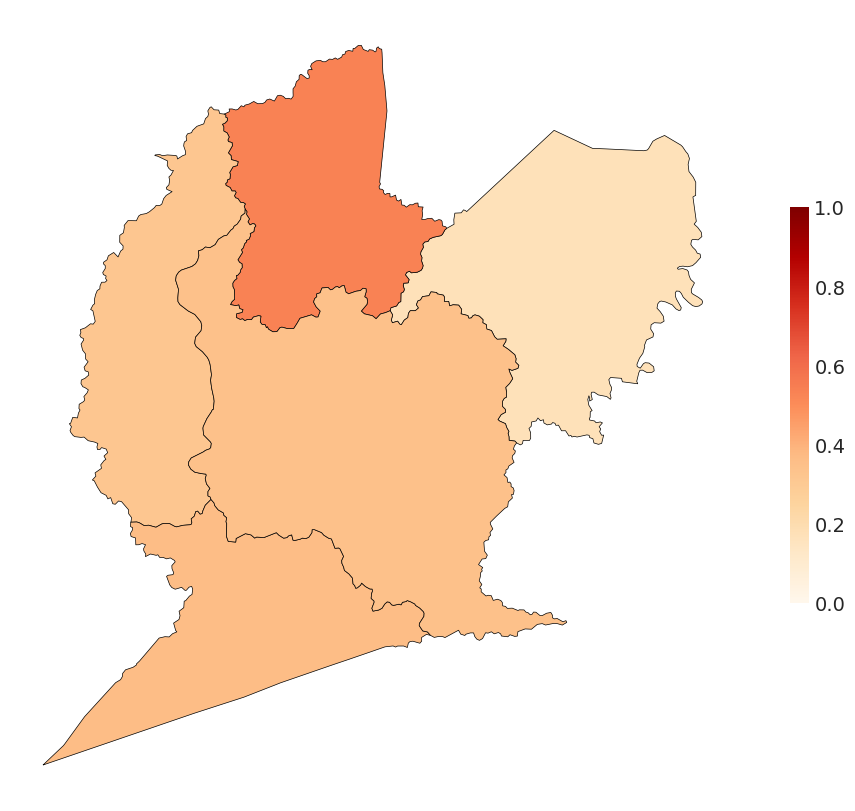

In [145]:

for fips in significant_changes[significant_changes["Change Direction"] == "Increase"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")
    print(f"EP_POV - Min: {svi_temp_area['EP_POV'].min()}, Max: {svi_temp_area['EP_POV'].max()}")

    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=0,   # Anchor the bottom of the color scale at 0
        vmax=1,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    plt.savefig(os.path.join( save_path,"0_1_scale", f"EP_POV_{fips}_increasing.png"), bbox_inches='tight', dpi=300)

Increasing and decreasing with unique scales

In [102]:
# get the max and min value for Increase and Decrease EP_POV values
increase_pov_values = []
decrease_pov_values = []

for fips in significant_changes[significant_changes["Change Direction"] == "Increase"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]
    increase_pov_values.extend(svi_temp_area["EP_POV"].tolist())

for fips in significant_changes[significant_changes["Change Direction"] == "Decrease"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]
    decrease_pov_values.extend(svi_temp_area["EP_POV"].tolist())
max_increase_pov = max(increase_pov_values)
min_increase_pov = min(increase_pov_values)
max_decrease_pov = max(decrease_pov_values)
min_decrease_pov = min(decrease_pov_values)

print(f"Increase EP_POV - Max: {max_increase_pov}, Min: {min_increase_pov}")
print(f"Decrease EP_POV - Max: {max_decrease_pov}, Min: {min_decrease_pov}")


Increase EP_POV - Max: 0.787755102040816, Min: 0.046258503401361
Decrease EP_POV - Max: 0.424489795918367, Min: 0.077551020408163


Plotting SVI data for FIPS: 54105
EP_POV - Min: 0.220408163265306, Max: 0.273469387755102


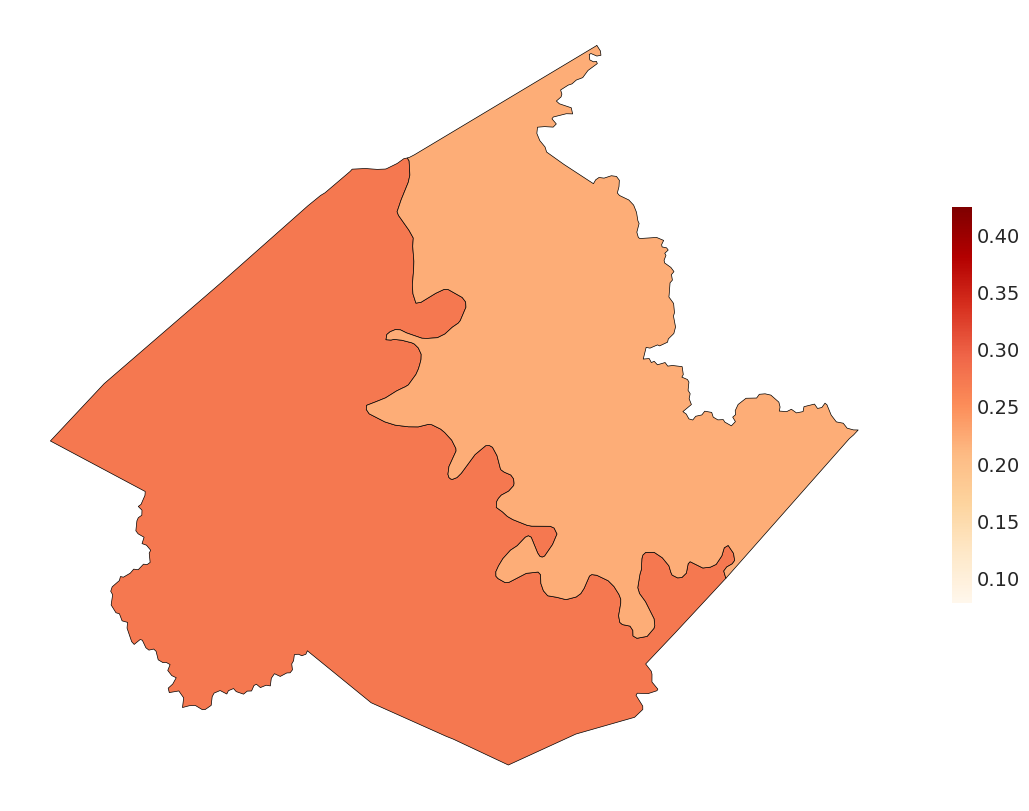

Plotting SVI data for FIPS: 54041
EP_POV - Min: 0.187755102040816, Max: 0.374149659863946


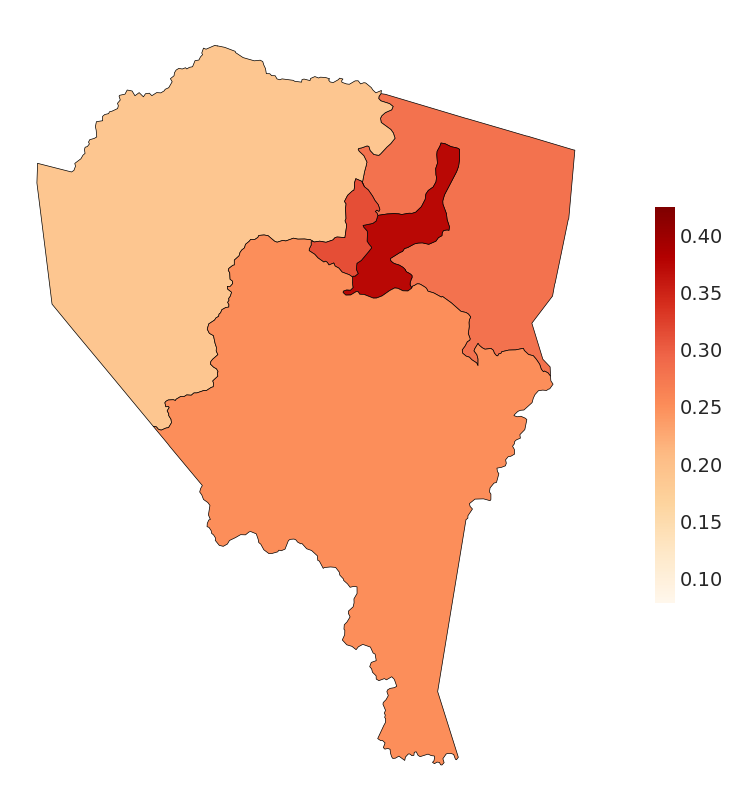

Plotting SVI data for FIPS: 54109
EP_POV - Min: 0.228571428571429, Max: 0.323809523809524


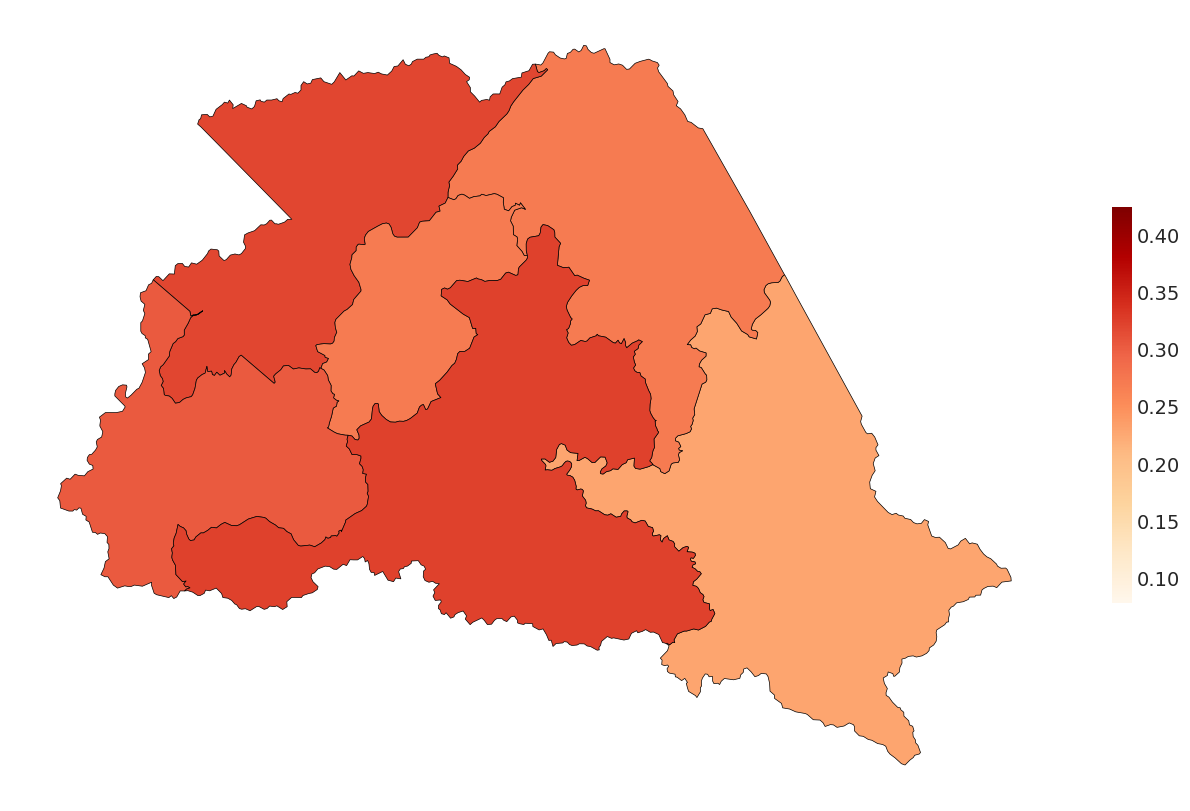

Plotting SVI data for FIPS: 54005
EP_POV - Min: 0.214965986394558, Max: 0.414965986394558


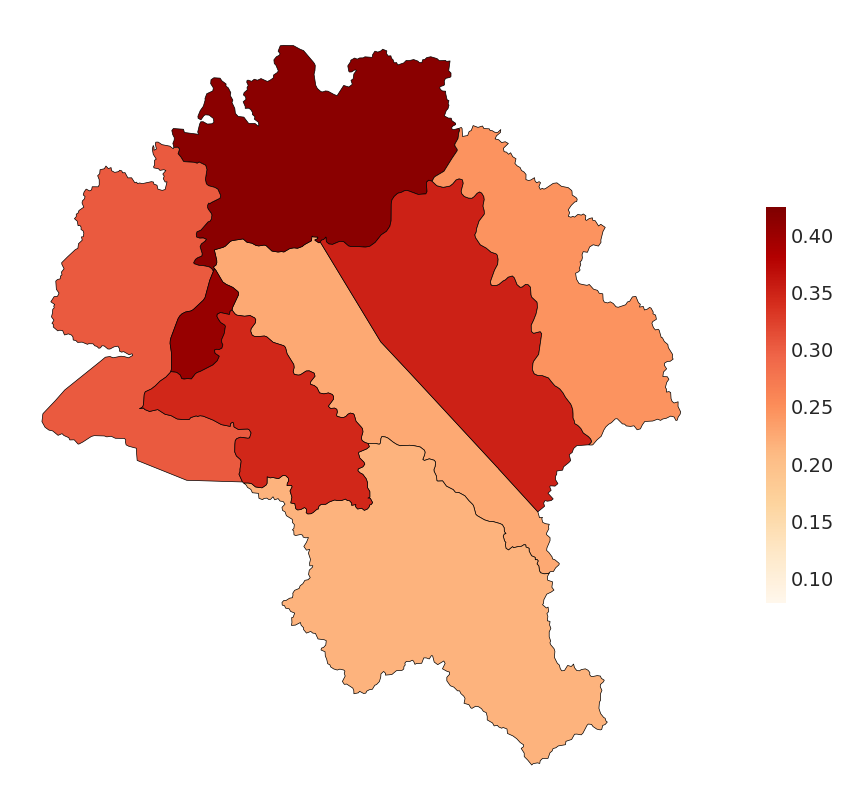

Plotting SVI data for FIPS: 54007
EP_POV - Min: 0.228571428571429, Max: 0.363265306122449


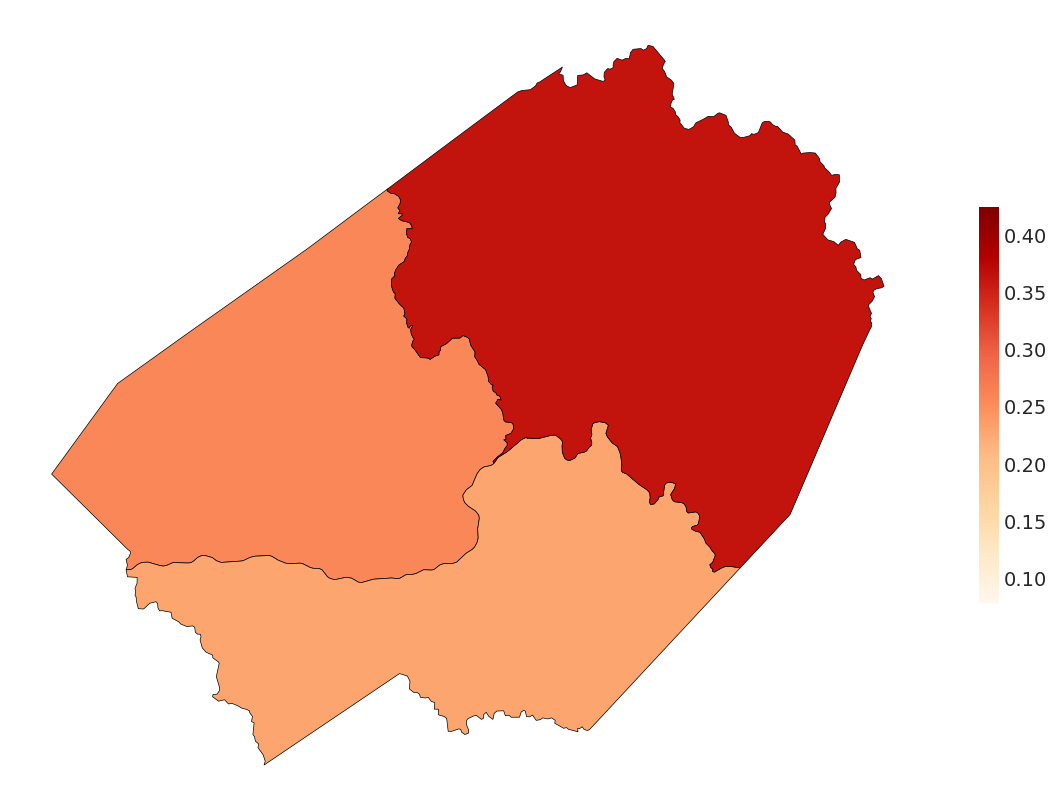

Plotting SVI data for FIPS: 54009
EP_POV - Min: 0.092517006802721, Max: 0.276190476190476


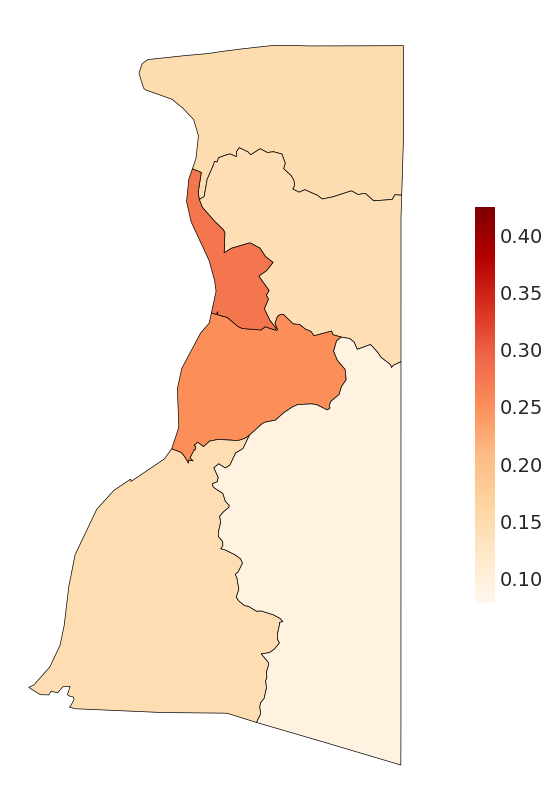

Plotting SVI data for FIPS: 54013
EP_POV - Min: 0.213605442176871, Max: 0.272108843537415


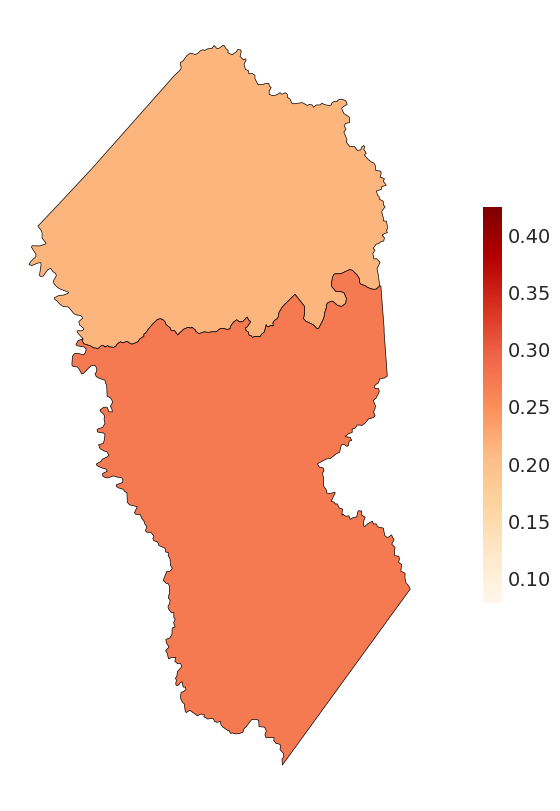

Plotting SVI data for FIPS: 54093
EP_POV - Min: 0.159183673469388, Max: 0.205442176870748


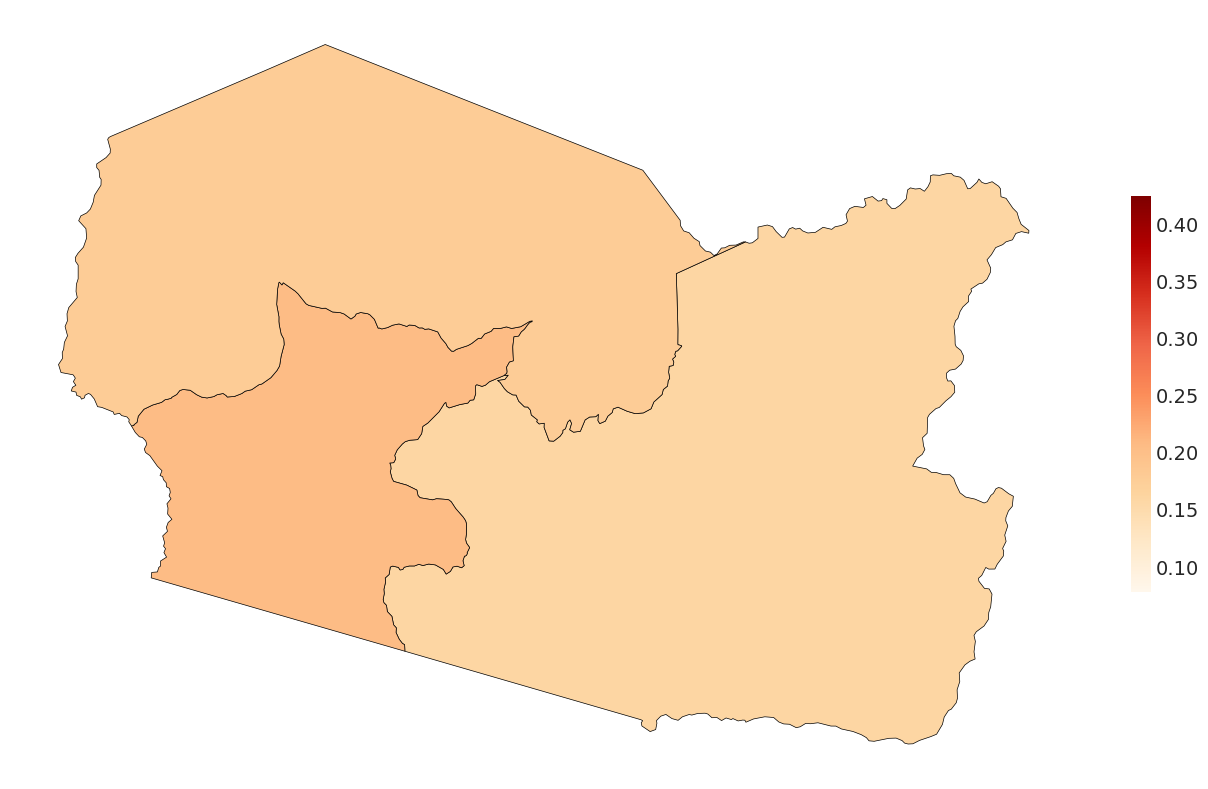

Plotting SVI data for FIPS: 54085
EP_POV - Min: 0.210884353741497, Max: 0.238095238095238


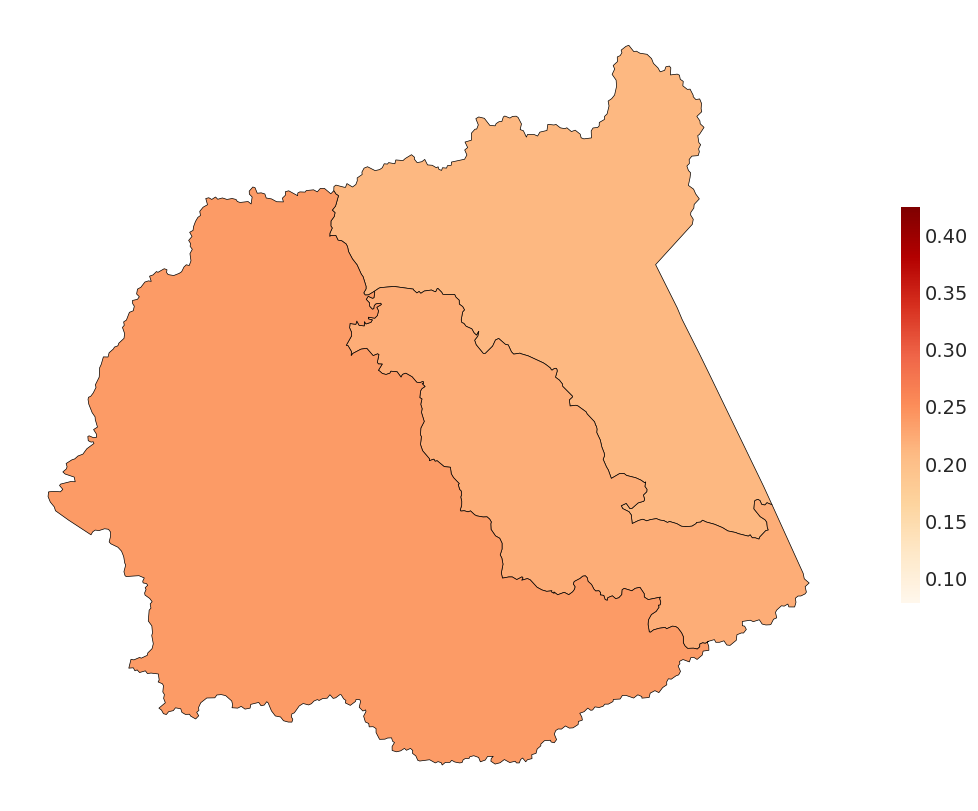

Plotting SVI data for FIPS: 54023
EP_POV - Min: 0.077551020408163, Max: 0.219047619047619


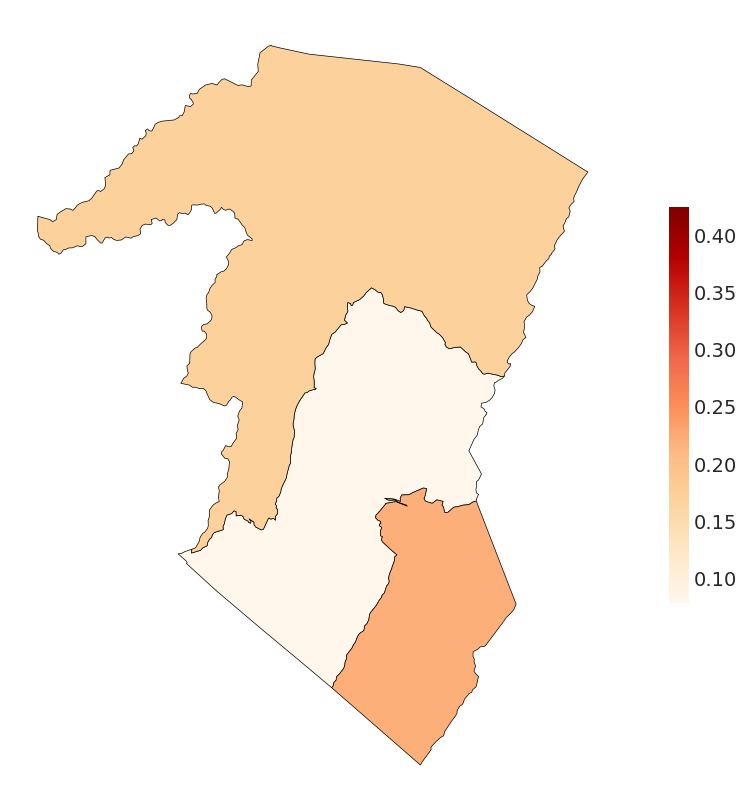

Plotting SVI data for FIPS: 54073
EP_POV - Min: 0.193197278911565, Max: 0.205442176870748


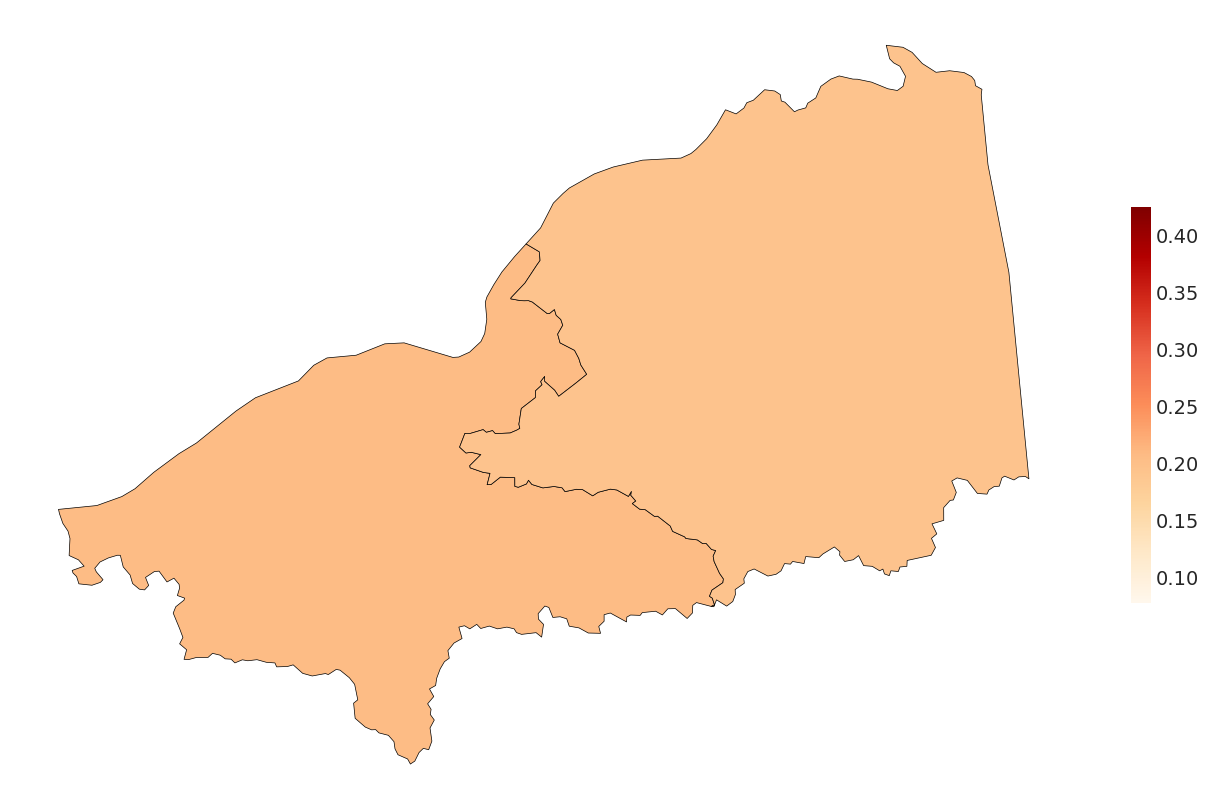

Plotting SVI data for FIPS: 54091
EP_POV - Min: 0.077551020408163, Max: 0.326530612244898


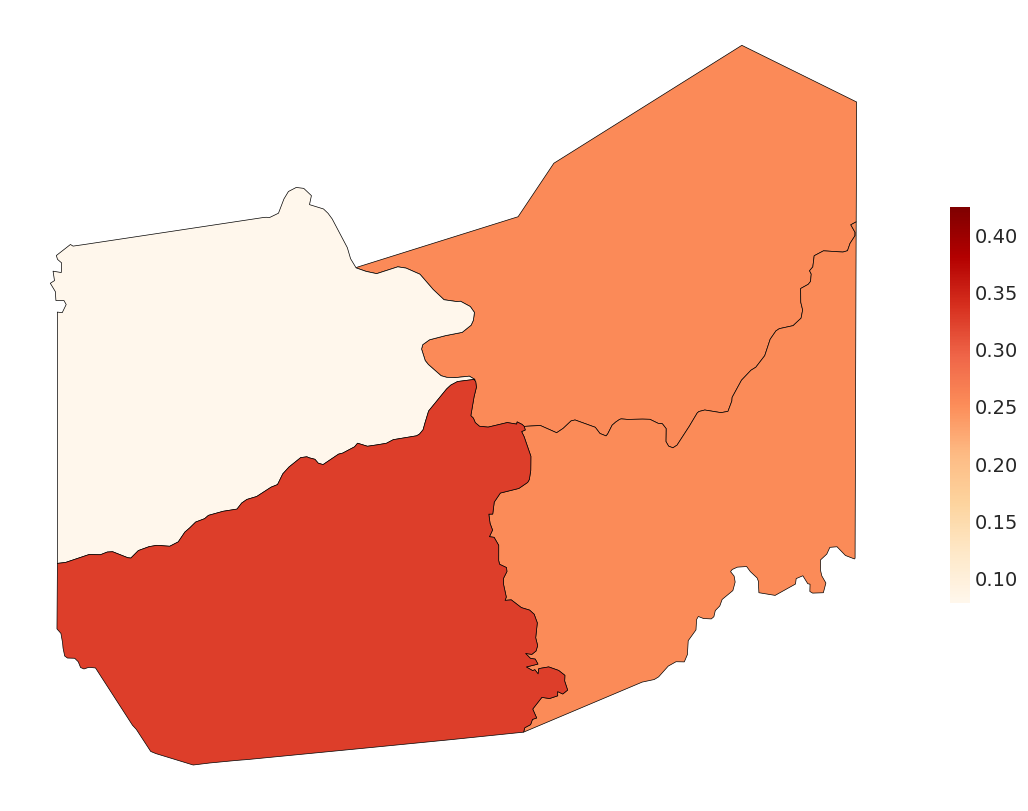

Plotting SVI data for FIPS: 54087
EP_POV - Min: 0.205442176870748, Max: 0.296598639455782


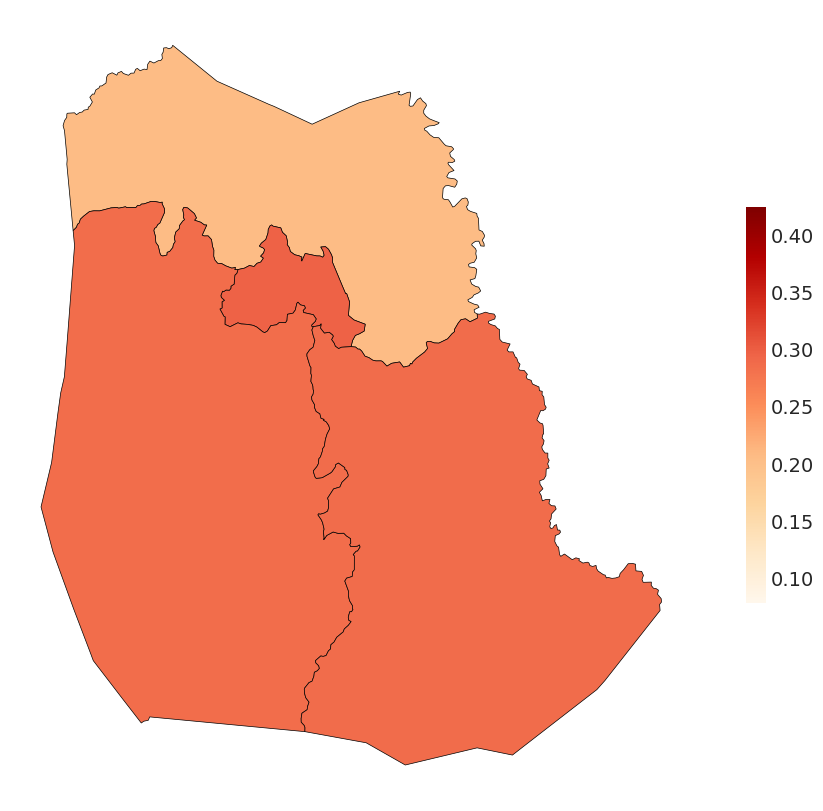

Plotting SVI data for FIPS: 54103
EP_POV - Min: 0.17687074829932, Max: 0.424489795918367


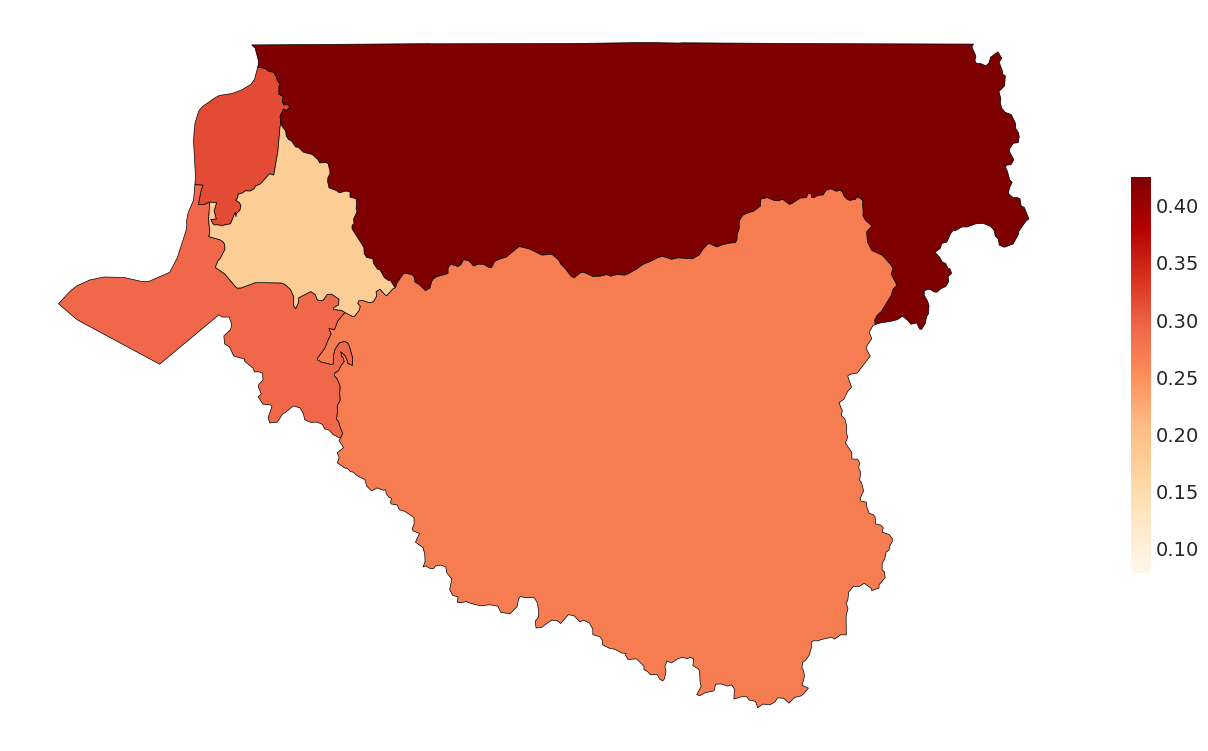

Plotting SVI data for FIPS: 54095
EP_POV - Min: 0.151020408163265, Max: 0.263945578231293


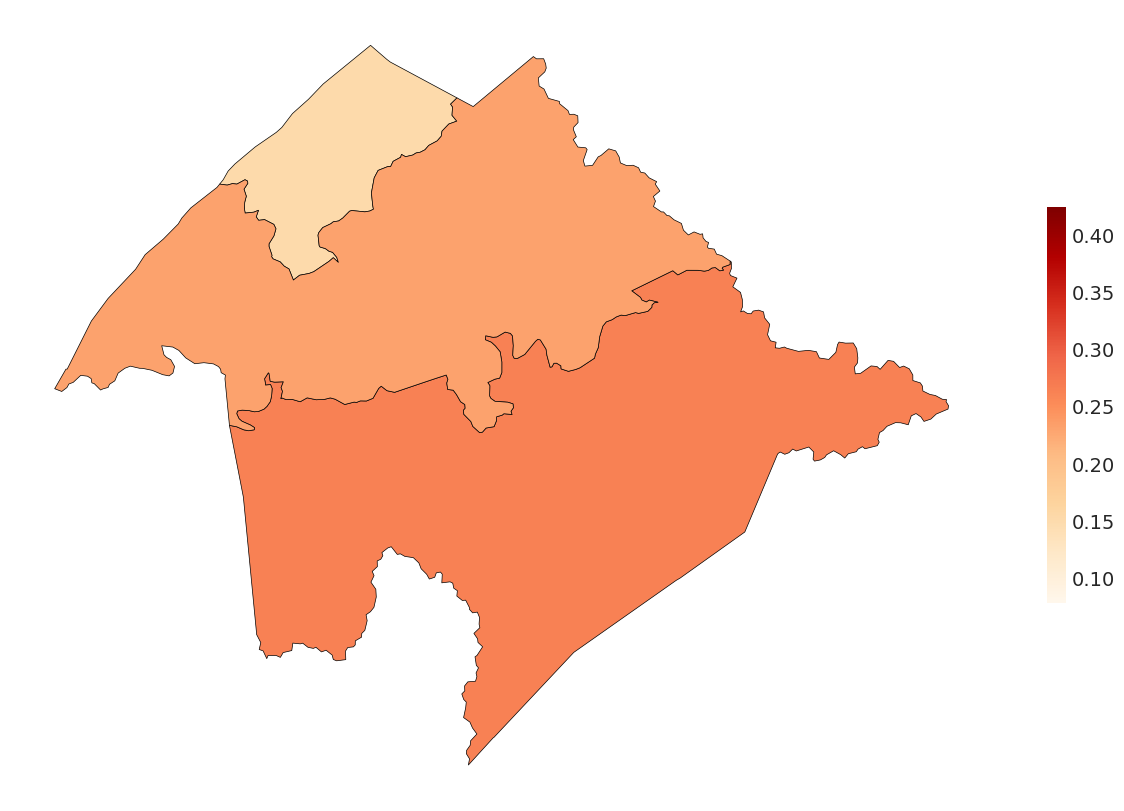

In [120]:

for fips in significant_changes[significant_changes["Change Direction"] == "Decrease"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")

    # print min and max EP_POV for the area
    print(f"EP_POV - Min: {svi_temp_area['EP_POV'].min()}, Max: {svi_temp_area['EP_POV'].max()}")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=min_decrease_pov,   # Anchor the bottom of the color scale at 0
        vmax=max_decrease_pov,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    plt.show()

Plotting SVI data for FIPS: 54021
EP_POV - Min: 0.137414965986395, Max: 0.473469387755102


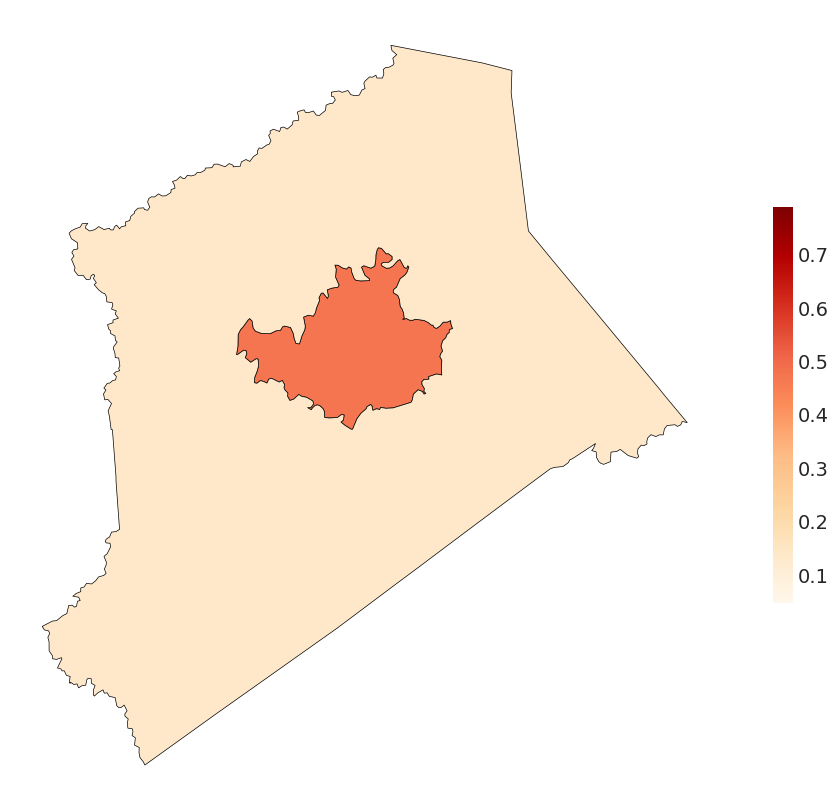

Plotting SVI data for FIPS: 54049
EP_POV - Min: 0.046258503401361, Max: 0.787755102040816


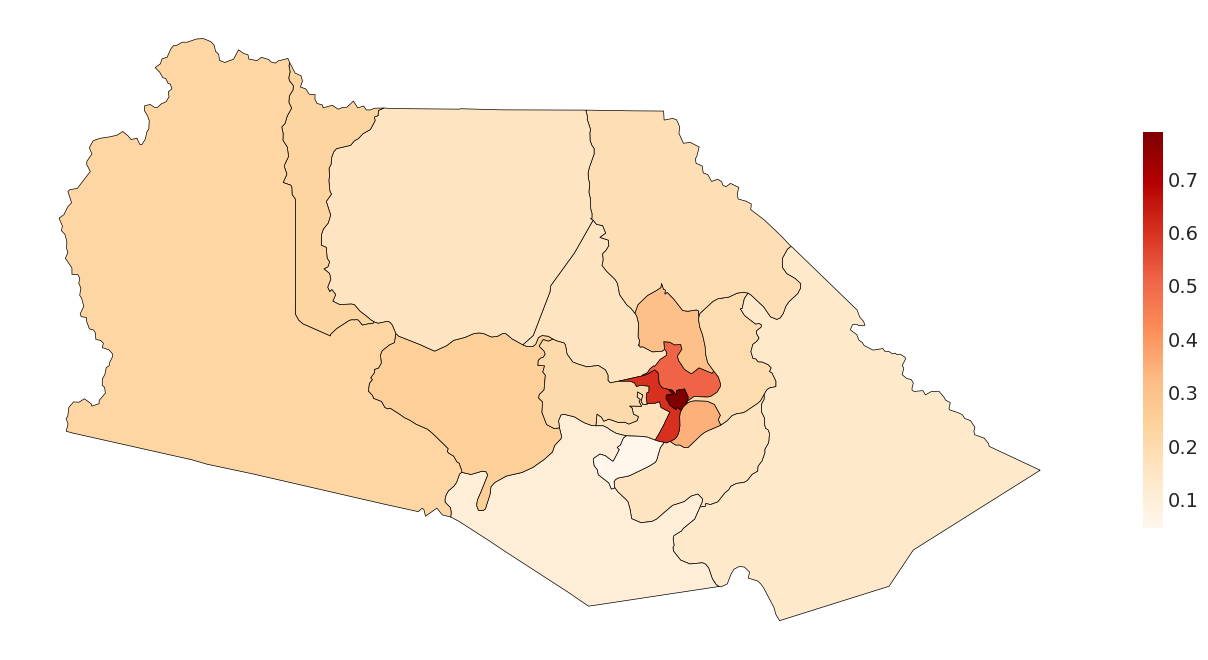

Plotting SVI data for FIPS: 54089
EP_POV - Min: 0.174149659863946, Max: 0.446258503401361


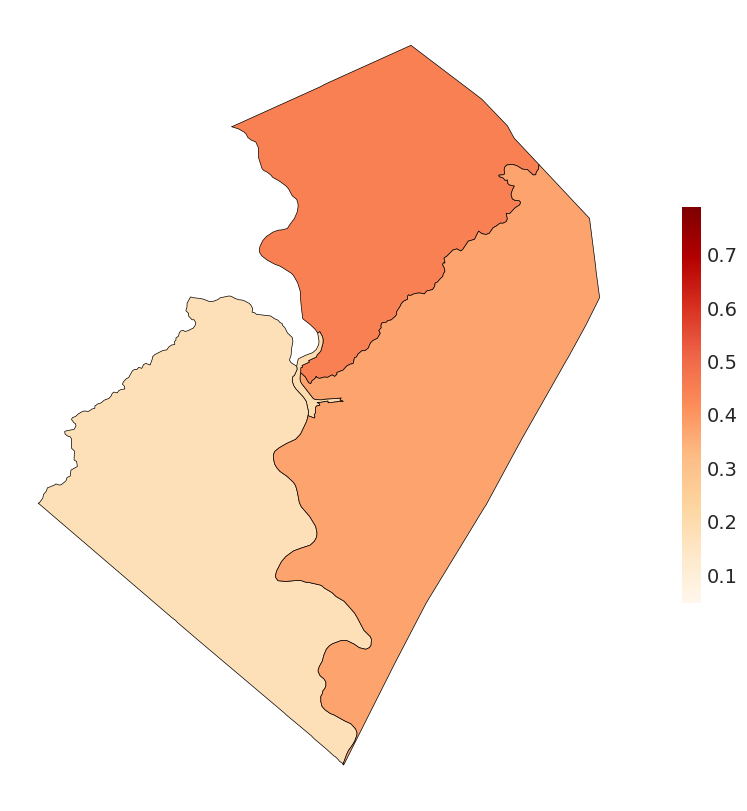

Plotting SVI data for FIPS: 54059
EP_POV - Min: 0.228571428571429, Max: 0.557823129251701


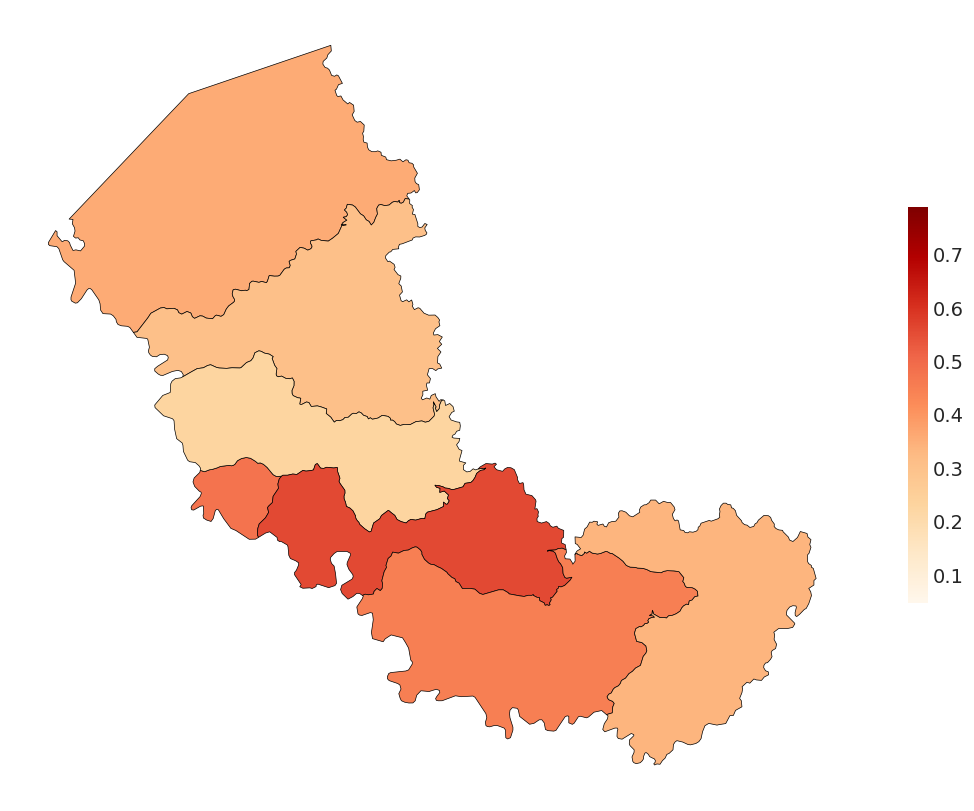

Plotting SVI data for FIPS: 54043
EP_POV - Min: 0.168707482993197, Max: 0.531972789115646


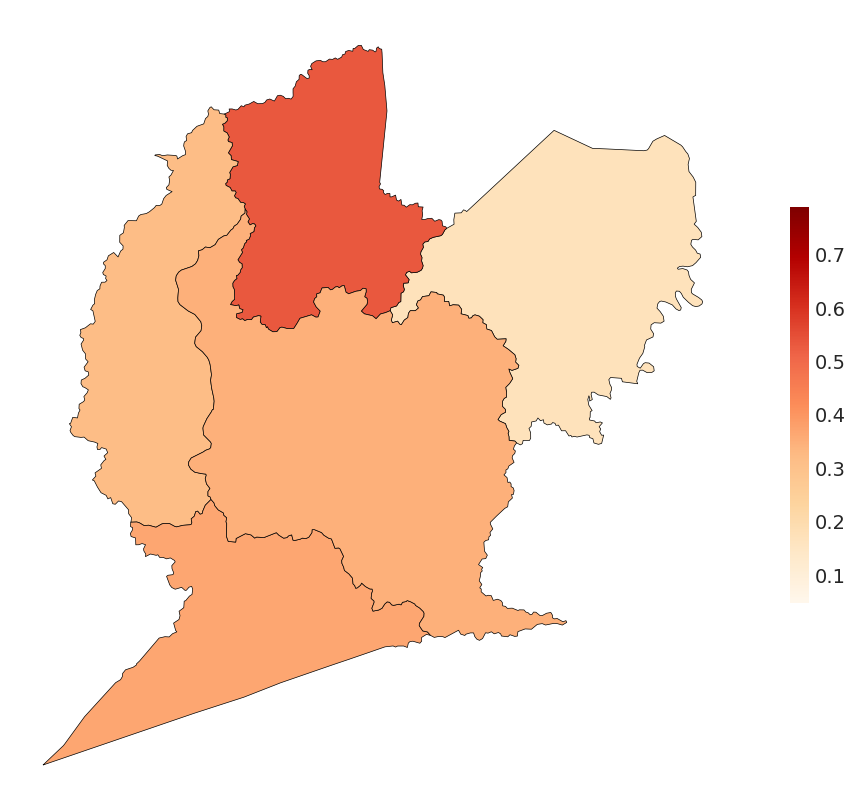

In [133]:

for fips in significant_changes[significant_changes["Change Direction"] == "Increase"]["FIPS"]:
    svi_temp_area = svi_geo_data[svi_geo_data["STCNTY"] == fips]

    print(f"Plotting SVI data for FIPS: {fips}")

    # print min and max EP_POV for the area
    print(f"EP_POV - Min: {svi_temp_area['EP_POV'].min()}, Max: {svi_temp_area['EP_POV'].max()}")
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')
    ax.set_facecolor("white")

    svi_temp_area.plot(
        column="EP_POV", 
        ax=ax, 
        legend=True, 
        cmap="OrRd", 
        
        # --- KEY CHANGE HERE ---
        vmin=min_increase_pov,   # Anchor the bottom of the color scale at 0
        vmax=max_increase_pov,   # Anchor the top of the color scale at 1
        # -----------------------
        
        edgecolor="black", 
        linewidth=0.5,
        legend_kwds={"shrink": 0.5},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "black",
            "hatch": "///",
            "label": "No Data"
        }
    )   
    
    ax.set_xticks([])
    ax.set_yticks([])   
    plt.show()